# Setup

In [2]:
# Load important variables

import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# targets and folds
targets_and_folds = pd.read_csv("features/targets_and_folds.csv")
targets_indexed = targets_and_folds.set_index("comment_id")

def ordinal_bin(score):
    if score < -1:
        return "supportive"
    elif score < 0.5:
        return "neutral"
    else:
        return "hate"

if "ordinal_label" not in targets_indexed.columns:
    targets_indexed["ordinal_label"] = targets_indexed["hate_speech_score"].apply(ordinal_bin)

FOLDS = sorted(targets_and_folds["fold"].unique())

def get_ids(fold_idx):
    train_ids = targets_and_folds.loc[targets_and_folds["fold"] != fold_idx, "comment_id"]
    test_ids = targets_and_folds.loc[targets_and_folds["fold"] == fold_idx, "comment_id"]
    return train_ids, test_ids

# embeddings: PCA vs raw
embed_df = pd.read_csv("features/embeddings.csv").set_index("comment_id")

def get_pca_features(fold_idx, train_ids, test_ids):
    pca_train = pd.read_csv(f"features/pca/fold_{int(fold_idx)}_train.csv", index_col=0)
    pca_test = pd.read_csv(f"features/pca/fold_{int(fold_idx)}_test.csv", index_col=0)
    return pca_train.loc[train_ids], pca_test.loc[test_ids]

def get_raw_features(fold_idx, train_ids, test_ids):
    raw_train_path = f"features/raw_scaled/fold_{int(fold_idx)}_train.csv"
    raw_test_path = f"features/raw_scaled/fold_{int(fold_idx)}_test.csv"
    if os.path.exists(raw_train_path) and os.path.exists(raw_test_path):
        X_train = pd.read_csv(raw_train_path, index_col=0)
        X_test = pd.read_csv(raw_test_path, index_col=0)
        return X_train.loc[train_ids], X_test.loc[test_ids]
    X_train_raw = embed_df.loc[train_ids]
    X_test_raw = embed_df.loc[test_ids]
    scaler = StandardScaler().fit(X_train_raw)
    X_train = pd.DataFrame(scaler.transform(X_train_raw), index=X_train_raw.index, columns=X_train_raw.columns)
    X_test = pd.DataFrame(scaler.transform(X_test_raw), index=X_test_raw.index, columns=X_test_raw.columns)
    os.makedirs("features/raw_scaled", exist_ok=True)
    X_train.to_csv(raw_train_path)
    X_test.to_csv(raw_test_path)
    return X_train, X_test

REPRESENTATIONS = {"pca": get_pca_features, "raw": get_raw_features}

LOGREG_C = 0.005
XGB_PARAMS = dict(max_depth=5, reg_lambda=1.0)

# code features + block/definition mapping
code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")

MIN_SUPPORT = 10
support = code_features.filter(regex="_[EIA]$").sum(axis=0)
kept_code_cols = support[support >= MIN_SUPPORT].index.tolist()
code_features_filtered = code_features[kept_code_cols]

flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()
code_block_map = flat[["code_id", "block"]].drop_duplicates().set_index("code_id")["block"]
definition_prefix_map = {"I": "IHRA", "N": "Nexus", "J": "JDA"}

def get_code_columns(definition, code_subset, code_features_columns):
    if definition == "All":
        relevant_codes = code_block_map.index
    else:
        prefix = {v: k for k, v in definition_prefix_map.items()}[definition]
        relevant_codes = code_block_map[code_block_map.str.startswith(prefix)].index
    if code_subset == "yes_only":
        relevant_codes = [c for c in relevant_codes if "NO" not in code_block_map[c]]
    cols = [c for code in relevant_codes for c in [f"{code}_E", f"{code}_I", f"{code}_A"] if c in code_features_columns]
    return cols

def code_cols_for_definition(definition):
    if definition == "All":
        return kept_code_cols
    prefix = {v: k for k, v in definition_prefix_map.items()}[definition]
    relevant_codes = code_block_map[code_block_map.str.startswith(prefix)].index
    return [c for c in kept_code_cols if c.rsplit("_", 1)[0] in relevant_codes]

# NLI scores
nli_scores = pd.read_csv("features/nli_zeroshot_scores.csv")
nli_wide = nli_scores.pivot(index="comment_id", columns="code_id", values="entailment_score")

print("Setup complete.")
print(f"targets_indexed: {targets_indexed.shape}")
print(f"embed_df: {embed_df.shape}")
print(f"code_features: {code_features.shape}, filtered: {code_features_filtered.shape}")
print(f"nli_wide: {nli_wide.shape}")
print(f"FOLDS: {FOLDS}")

Setup complete.
targets_indexed: (1874, 3)
embed_df: (1874, 384)
code_features: (1874, 381), filtered: (1874, 227)
nli_wide: (1874, 127)
FOLDS: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


### Create Features

In [5]:
# One-hot encode labels

import os
import pandas as pd

flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()

# pivot to one row per comment, one column per code, value = label (N/E/I/A)
wide = flat.pivot_table(index="comment_id", columns="code_id", values="label", aggfunc="first")

# one-hot encode each code into E/I/A, dropping N as reference
code_cols = wide.columns.tolist()
onehot_frames = []
for code in code_cols:
    dummies = pd.get_dummies(wide[code], prefix=code).astype(int)
    for level in ["E", "I", "A"]:
        col = f"{code}_{level}"
        if col not in dummies.columns:
            dummies[col] = 0
    dummies = dummies[[f"{code}_E", f"{code}_I", f"{code}_A"]]
    onehot_frames.append(dummies)

code_features = pd.concat(onehot_frames, axis=1)
code_features.index.name = "comment_id"
code_features = code_features.reset_index()

print(f"code_features: {code_features.shape[0]} comments, {code_features.shape[1] - 1} one-hot columns")
print(f"dtypes: {code_features.drop(columns='comment_id').dtypes.unique()}")


# Create folds by ordinal bins

from sklearn.model_selection import StratifiedKFold

judaism = pd.read_csv("data/ucberkeley-dlab_target_jewish.csv")

def ordinal_bin(score):
    if score < -1:
        return "supportive"
    elif score <= 0.5:
        return "neutral"
    else:
        return "hate"

judaism["ordinal_label"] = judaism["hate_speech_score"].apply(ordinal_bin)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_assignment = pd.Series(index=judaism["comment_id"], dtype=int)

for fold_idx, (_, test_idx) in enumerate(skf.split(judaism, judaism["ordinal_label"])):
    fold_assignment.iloc[test_idx] = fold_idx

judaism["fold"] = fold_assignment.values
print(judaism.groupby(["fold", "ordinal_label"]).size().unstack())


# Embed text

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(judaism["text"].tolist(), show_progress_bar=True)

embed_df = pd.DataFrame(embeddings, index=judaism["comment_id"])
embed_df.columns = [f"emb_{i}" for i in range(embed_df.shape[1])]
embed_df = embed_df.reset_index()

print(f"embeddings: {embed_df.shape[0]} comments, {embed_df.shape[1] - 1} dims")


# Save everything to disk

os.makedirs("features", exist_ok=True)

code_features.to_csv("features/code_features.csv", index=False)
embed_df.to_csv("features/embeddings.csv", index=False)
judaism[["comment_id", "hate_speech_score", "ordinal_label", "fold"]].to_csv("features/targets_and_folds.csv", index=False)

print(f"\nSaved code_features.csv: {code_features.shape}")
print(f"Saved embeddings.csv: {embed_df.shape}")
print(f"Saved targets_and_folds.csv: {judaism.shape[0]} rows")

code_features: 1874 comments, 381 one-hot columns
dtypes: [dtype('int32') dtype('int64')]
ordinal_label  hate  neutral  supportive
fold                                    
0.0              94      119         162
1.0              94      119         162
2.0              94      119         162
3.0              95      118         162
4.0              94      118         162


Batches:   0%|          | 0/59 [00:00<?, ?it/s]

embeddings: 1874 comments, 384 dims

Saved code_features.csv: (1874, 382)
Saved embeddings.csv: (1874, 385)
Saved targets_and_folds.csv: 1874 rows


### PCA by Fold

In [4]:
# Select N programmatically via scree analysis, then fit/transform per fold

import os
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

VARIANCE_TARGET = 0.90  # threshold used to programmatically select N

embed_indexed = embed_df.set_index("comment_id")

# Scree diagnostic on full corpus, used to select N components
scaler_full = StandardScaler()
embeddings_scaled_full = scaler_full.fit_transform(embed_indexed.values)

pca_full = PCA(n_components=min(embed_indexed.shape)).fit(embeddings_scaled_full)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

N_COMPONENTS = int(np.argmax(cumvar >= VARIANCE_TARGET) + 1)

print("=== Scree diagnostic ===")
for target in [0.80, 0.85, 0.90, 0.95]:
    n_needed = int(np.argmax(cumvar >= target) + 1)
    print(f"  {target*100:.0f}% variance retained at N={n_needed} components")
print(f"\nSelected N_COMPONENTS = {N_COMPONENTS} (>= {VARIANCE_TARGET*100:.0f}% cumulative variance)")
print(f"N={N_COMPONENTS} retains {cumvar[N_COMPONENTS-1]*100:.2f}% variance\n")

# Per-fold PCA using the selected N
def fit_transform_pca_per_fold(embed_indexed, judaism, n_components):
    results = {}

    for fold_idx in sorted(judaism["fold"].unique()):
        train_ids = judaism.loc[judaism["fold"] != fold_idx, "comment_id"]
        test_ids = judaism.loc[judaism["fold"] == fold_idx, "comment_id"]

        X_train = embed_indexed.loc[train_ids]
        X_test = embed_indexed.loc[test_ids]

        scaler = StandardScaler().fit(X_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        pca = PCA(n_components=n_components, random_state=42).fit(X_train_scaled)
        train_reduced = pd.DataFrame(
            pca.transform(X_train_scaled),
            index=train_ids,
            columns=[f"pc_{i}" for i in range(n_components)],
        )
        test_reduced = pd.DataFrame(
            pca.transform(X_test_scaled),
            index=test_ids,
            columns=[f"pc_{i}" for i in range(n_components)],
        )
        results[fold_idx] = (train_reduced, test_reduced)
        print(f"  fold {fold_idx}: {pca.explained_variance_ratio_.sum()*100:.2f}% variance explained by {n_components} components (train n={len(train_ids)})")

    return results

print("=== Per-fold PCA ===")
pca_by_fold = fit_transform_pca_per_fold(embed_indexed, judaism, N_COMPONENTS)

# Save PCA outputs to disk

os.makedirs("features/pca", exist_ok=True)

for fold_idx, (train_reduced, test_reduced) in pca_by_fold.items():
    train_reduced.to_csv(f"features/pca/fold_{int(fold_idx)}_train.csv")
    test_reduced.to_csv(f"features/pca/fold_{int(fold_idx)}_test.csv")

print(f"\nSaved {len(pca_by_fold)} fold train/test PCA files -> features/pca/")
print(f"Saved N_COMPONENTS={N_COMPONENTS} -> features/pca/n_components.txt")

=== Scree diagnostic ===
  80% variance retained at N=120 components
  85% variance retained at N=145 components
  90% variance retained at N=179 components
  95% variance retained at N=227 components

Selected N_COMPONENTS = 179 (>= 90% cumulative variance)
N=179 retains 90.10% variance

=== Per-fold PCA ===
  fold 0.0: 90.42% variance explained by 179 components (train n=1499)
  fold 1.0: 90.41% variance explained by 179 components (train n=1499)
  fold 2.0: 90.43% variance explained by 179 components (train n=1499)
  fold 3.0: 90.42% variance explained by 179 components (train n=1499)
  fold 4.0: 90.43% variance explained by 179 components (train n=1500)

Saved 5 fold train/test PCA files -> features/pca/
Saved N_COMPONENTS=179 -> features/pca/n_components.txt


### Load Targets

In [6]:
# Aggregate Continuous

continuous_target = judaism[["comment_id", "hate_speech_score", "fold"]].copy()
continuous_target = continuous_target.rename(columns={"hate_speech_score": "target_continuous"})


# Ordinal

ordinal_map = {"supportive": 0, "neutral": 1, "hate": 2}
ordinal_target = judaism[["comment_id", "ordinal_label", "fold"]].copy()
ordinal_target["target_ordinal"] = ordinal_target["ordinal_label"].map(ordinal_map)
ordinal_target = ordinal_target.drop(columns=["ordinal_label"])


# Binary

binary_target = judaism[["comment_id", "hate_speech_score", "fold"]].copy()
binary_target["target_binary"] = (binary_target["hate_speech_score"] > 0.5).astype(int)
binary_target = binary_target.drop(columns=["hate_speech_score"])

print("continuous:", continuous_target.shape)
print("ordinal:", ordinal_target["target_ordinal"].value_counts().to_dict())
print("binary:", binary_target["target_binary"].value_counts().to_dict())

continuous: (1874, 3)
ordinal: {0: 810, 1: 593, 2: 471}
binary: {0: 1403, 1: 471}


## Data Shape (EDA)

In [2]:
# EDA: label distribution by code and label source (GPT-4o vs Sonnet)

import pandas as pd

flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()

dist = (
    flat.groupby(["code_id", "label_source", "label"])
    .size()
    .unstack("label", fill_value=0)
    .reindex(columns=["N", "E", "I", "A"], fill_value=0)
)
dist_pct = dist.div(dist.sum(axis=1), axis=0) * 100

wide = dist_pct.unstack("label_source")
wide.columns = [f"{source}_{label}" for label, source in wide.columns]
col_order = [c for c in ["gpt4o_N", "gpt4o_E", "gpt4o_I", "gpt4o_A", "sonnet_N", "sonnet_E", "sonnet_I", "sonnet_A"] if c in wide.columns]
wide = wide[col_order]

print(f"Label distribution by code and source ({len(wide)} codes)")
print(wide.round(2).to_string())

print(f"\nOverall corpus size: {len(flat['comment_id'].unique())} comments, {flat['code_id'].nunique()} codes, {len(flat)} total labeled (comment, code) pairs")
print(f"\nLabel source counts: {flat['label_source'].value_counts().to_dict()}")
print(f"\nOverall label distribution (pooled across all codes and sources):")
print(flat["label"].value_counts(normalize=True).mul(100).round(2).to_string())

Label distribution by code and source (127 codes)
                         gpt4o_N  gpt4o_E  gpt4o_I  gpt4o_A  sonnet_N  sonnet_E  sonnet_I  sonnet_A
code_id                                                                                            
A1ESSENTIAL                40.91    15.15    33.33    10.61     79.54      7.41      6.58      6.47
A2COLLECTIVEAGENDA         39.39    12.12    36.36    12.12     90.76      1.16      6.64      1.44
A2CONSPIRACY               34.85     6.06    50.00     9.09     91.98      0.83      5.97      1.22
A2CONTROLBANKS             81.82     1.52     3.03    13.64     99.34      0.28      0.28      0.11
A2CONTROLGOV               56.06     4.55    21.21    18.18     96.74      0.33      2.43      0.50
A2CONTROLMEDIA             77.27     4.55     3.03    15.15     98.23      0.44      1.16      0.17
A2DISEASE                  89.39     0.00     4.55     6.06     99.67      0.06      0.17      0.11
A2EVIL                     33.33    16.67    31.82

Word count summary:
count    1874.00
mean       28.20
std        21.33
min         1.00
25%        12.00
50%        22.00
75%        39.75
max       122.00

Character count summary:
count    1874.00
mean      161.56
std       121.30
min         8.00
25%        69.00
50%       129.50
75%       227.00
max       603.00


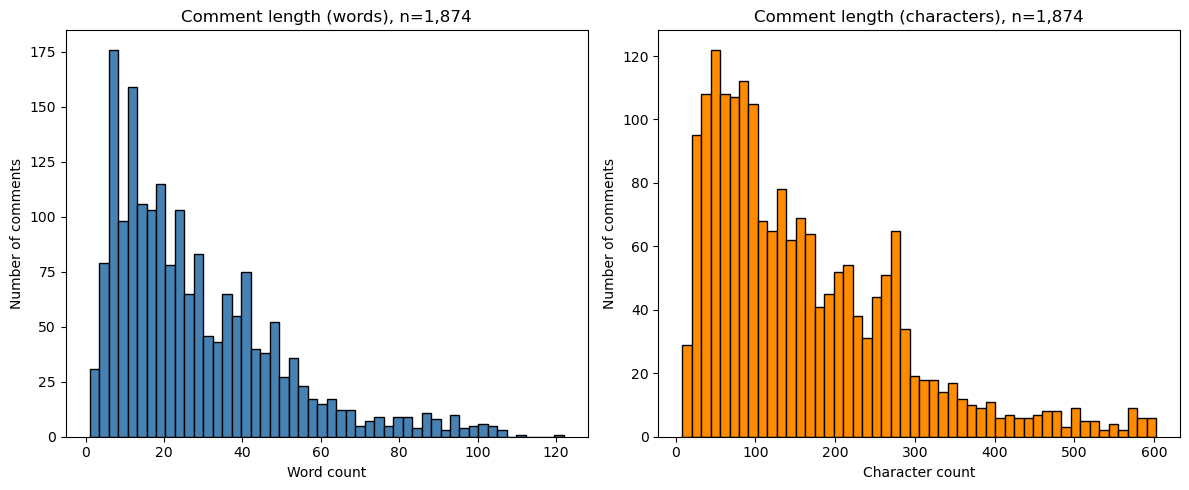

In [15]:
# comment length distribution

import pandas as pd
import matplotlib.pyplot as plt

judaism = pd.read_csv("data/ucberkeley-dlab_target_jewish.csv")
judaism["word_count"] = judaism["text"].str.split().str.len()
judaism["char_count"] = judaism["text"].str.len()

print("Word count summary:")
print(judaism["word_count"].describe().round(2).to_string())
print("\nCharacter count summary:")
print(judaism["char_count"].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(judaism["word_count"], bins=50, color="steelblue", edgecolor="black")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Number of comments")
axes[0].set_title(f"Comment length (words), n={len(judaism):,}")

axes[1].hist(judaism["char_count"], bins=50, color="darkorange", edgecolor="black")
axes[1].set_xlabel("Character count")
axes[1].set_ylabel("Number of comments")
axes[1].set_title(f"Comment length (characters), n={len(judaism):,}")

plt.tight_layout()
plt.savefig("viz/comment_length_distribution.png", dpi=150)
plt.show()

In [17]:
# does a comment flagged (E/I/A on any code) under one definition tend to also be flagged under the others?

import pandas as pd
import numpy as np

comment_flags = pd.DataFrame(index=targets_indexed.index)

for prefix, def_name in definition_prefix_map.items():
    def_codes = code_block_map[code_block_map.str.startswith(prefix)].index
    def_cols = [c for c in code_features.columns if c.rsplit("_", 1)[0] in def_codes]
    comment_flags[def_name] = (code_features.reindex(comment_flags.index)[def_cols].sum(axis=1) > 0).astype(int)

print("Flagged (>=1 code triggered) counts per definition:")
print(comment_flags.sum().to_string())

print(f"\nTotal comments: {len(comment_flags):,}\n")

print("=== Pairwise agreement (both flagged, both not flagged, disagreement) ===")
defs = list(definition_prefix_map.values())
for i in range(len(defs)):
    for j in range(i + 1, len(defs)):
        d1, d2 = defs[i], defs[j]
        both_flagged = ((comment_flags[d1] == 1) & (comment_flags[d2] == 1)).sum()
        both_clear = ((comment_flags[d1] == 0) & (comment_flags[d2] == 0)).sum()
        only_d1 = ((comment_flags[d1] == 1) & (comment_flags[d2] == 0)).sum()
        only_d2 = ((comment_flags[d1] == 0) & (comment_flags[d2] == 1)).sum()
        agreement_rate = (both_flagged + both_clear) / len(comment_flags)
        print(f"\n{d1} vs {d2}:")
        print(f"  Both flagged: {both_flagged:,}  Both clear: {both_clear:,}")
        print(f"  Only {d1}: {only_d1:,}  Only {d2}: {only_d2:,}")
        print(f"  Simple agreement rate: {agreement_rate:.3f}")

print("\n=== Three-way overlap (all three, exactly two, exactly one, none) ===")
n_flagged = comment_flags.sum(axis=1)
print(n_flagged.value_counts().sort_index().rename("n_comments").to_string())

Flagged (>=1 code triggered) counts per definition:
IHRA     927
Nexus    805
JDA      801

Total comments: 1,874

=== Pairwise agreement (both flagged, both not flagged, disagreement) ===

IHRA vs Nexus:
  Both flagged: 769  Both clear: 911
  Only IHRA: 158  Only Nexus: 36
  Simple agreement rate: 0.896

IHRA vs JDA:
  Both flagged: 753  Both clear: 899
  Only IHRA: 174  Only JDA: 48
  Simple agreement rate: 0.882

Nexus vs JDA:
  Both flagged: 712  Both clear: 980
  Only Nexus: 93  Only JDA: 89
  Simple agreement rate: 0.903

=== Three-way overlap (all three, exactly two, exactly one, none) ===
0    878
1    156
2    143
3    697


In [21]:
# concept-map-based overlap: how many codes across IHRA/Nexus/JDA map to the same underlying concept?

import pandas as pd

# concept_map was built earlier from the code map markdown table (concept -> list of code_ids across frameworks)
concept_summary_rows = []
for concept, codes in concept_map.items():
    def_counts = {"IHRA": 0, "Nexus": 0, "JDA": 0}
    for code in codes:
        block = code_block_map.get(code)
        if block is None:
            continue
        def_name = definition_prefix_map.get(block[0])
        if def_name:
            def_counts[def_name] += 1
    n_defs_represented = sum(1 for v in def_counts.values() if v > 0)
    concept_summary_rows.append({
        "concept": concept,
        "n_codes_total": len(codes),
        **def_counts,
        "n_definitions_represented": n_defs_represented,
    })

concept_summary = pd.DataFrame(concept_summary_rows).sort_values("n_definitions_represented", ascending=False)
print(f"Total concepts mapped: {len(concept_summary)}\n")
print(concept_summary.to_string(index=False))

print(f"\nConcepts represented in all 3 definitions: {(concept_summary['n_definitions_represented'] == 3).sum()}")
print(f"Concepts represented in exactly 2 definitions: {(concept_summary['n_definitions_represented'] == 2).sum()}")
print(f"Concepts represented in only 1 definition (framework-unique): {(concept_summary['n_definitions_represented'] == 1).sum()}")

Total concepts mapped: 32

                                             concept  n_codes_total  IHRA  Nexus  JDA  n_definitions_represented
                                    Collective blame              8     2      4    2                          3
                       Conspiracy and hidden agendas              9     3      2    4                          3
                                    Control of media              3     1      1    1                          3
                               Control of government              3     1      1    1                          3
                                  Dual loyalty trope              6     2      1    3                          3
                 Denial of Jewish self-determination              6     1      4    1                          3
                                      Discrimination              3     1      1    1                          3
                                            Violence              3  

In [ ]:
# c-TF-IDF by code

import pandas as pd
import numpy as np
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()

judaism = pd.read_csv("data/ucberkeley-dlab_target_jewish.csv").set_index("comment_id")

MIN_DOCS_PER_CODE = 5
MAX_CLASS_DF_RATIO = 0.4  # drop terms appearing in more than 40% of all code-classes

DOMAIN_STOPWORDS = {"jew", "jews", "jewish", "israel", "israeli", "zionist", "zionists", "url"}
STOPWORDS = set(ENGLISH_STOP_WORDS) | DOMAIN_STOPWORDS

def tokenize(text):
    text = re.sub(r"[^a-zA-Z\s]", " ", str(text).lower())
    return [t for t in text.split() if t not in STOPWORDS and len(t) > 2]

def get_bigrams(tokens):
    return [f"{tokens[i]} {tokens[i+1]}" for i in range(len(tokens) - 1)]

ei_rows = flat[flat["label"].isin(["E", "I"])][["comment_id", "code_id"]].drop_duplicates()
ei_rows = ei_rows[ei_rows["comment_id"].isin(judaism.index)]

code_counts = ei_rows.groupby("code_id")["comment_id"].nunique()
codes_to_run = sorted(code_counts[code_counts >= MIN_DOCS_PER_CODE].index)

code_term_counts = {}
for code_id in codes_to_run:
    comment_ids = ei_rows.loc[ei_rows["code_id"] == code_id, "comment_id"]
    all_terms = []
    for cid in comment_ids:
        tokens = tokenize(judaism.loc[cid, "text"])
        all_terms.extend(tokens)
        all_terms.extend(get_bigrams(tokens))
    code_term_counts[code_id] = Counter(all_terms)

tf = {}
for code_id, counts in code_term_counts.items():
    total = sum(counts.values())
    tf[code_id] = {term: count / total for term, count in counts.items()} if total > 0 else {}

all_terms_set = set()
for counts in code_term_counts.values():
    all_terms_set.update(counts.keys())

n_classes = len(codes_to_run)
class_freq = {term: 0 for term in all_terms_set}
for counts in code_term_counts.values():
    for term in counts:
        class_freq[term] += 1

avg_terms_per_class = np.mean([sum(c.values()) for c in code_term_counts.values()])
idf = {term: np.log(1 + avg_terms_per_class / class_freq[term]) for term in all_terms_set}

terms_to_drop = {term for term, freq in class_freq.items() if freq / n_classes > MAX_CLASS_DF_RATIO}
print(f"{n_classes} codes with >= {MIN_DOCS_PER_CODE} E/I documents")
print(f"Dropping {len(terms_to_drop)} terms present in >{MAX_CLASS_DF_RATIO*100:.0f}% of classes:")
print(sorted(terms_to_drop))
print()

for code_id in codes_to_run:
    scores = {term: tf[code_id][term] * idf[term] for term in code_term_counts[code_id] if term not in terms_to_drop}
    top_terms = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:15]
    n_docs = code_counts[code_id]
    print(f"{'=' * 50}\n{code_id} (n={n_docs} comments)\n{'=' * 50}")
    for term, score in top_terms:
        print(f"  {term}: {score:.5f}")
    print()

118 codes with >= 5 E/I documents
Dropping 425 terms present in >40% of classes:
['acosta', 'acting', 'actually', 'agenda', 'aka', 'allowed', 'america', 'american', 'americans', 'anti', 'anti semite', 'anti semitic', 'antisemitism', 'anymore', 'applauded', 'armed', 'army', 'ass', 'assassins', 'assassins idf', 'attack', 'away', 'away convert', 'babies', 'babies synagogs', 'baby', 'baby killers', 'bad', 'based', 'based hatred', 'believe', 'better', 'bible', 'big', 'biggest', 'black', 'blood', 'boy', 'boycott', 'break', 'british', 'brought', 'burn', 'burned', 'business', 'cabal', 'called', 'camps', 'cancer', 'capital', 'cause', 'changed', 'child', 'children', 'children spew', 'china', 'christ', 'christian', 'christians', 'citizens', 'citizenship', 'claim', 'classes', 'clean', 'come', 'coming', 'commit', 'commit murder', 'communist', 'continue', 'control', 'controlled', 'controlling', 'convert', 'convert judaism', 'corrupt', 'countries', 'country', 'course', 'court', 'courts', 'courts make

In [31]:
# Intertopic distance map (2D projection of each code's c-TF-IDF vector, bubble size = n comments), interactive

import numpy as np
import pandas as pd
import plotly.express as px

try:
    from umap import UMAP
    reducer = UMAP(n_neighbors=10, min_dist=0.3, metric="cosine", random_state=42)
    reducer_name = "UMAP"
except ImportError:
    from sklearn.decomposition import PCA
    reducer = PCA(n_components=2, random_state=42)
    reducer_name = "PCA"
    print("umap-learn not installed, falling back to PCA. `pip install umap-learn` for the standard BERTopic-style layout.")

all_kept_terms = sorted(set(t for counts in code_term_counts.values() for t in counts if t not in terms_to_drop))
term_index = {t: i for i, t in enumerate(all_kept_terms)}

matrix = np.zeros((len(codes_to_run), len(all_kept_terms)))
top_terms_per_code = {}
for row_idx, code_id in enumerate(codes_to_run):
    scores = {}
    for term, count in code_term_counts[code_id].items():
        if term in term_index:
            score = tf[code_id][term] * idf[term]
            matrix[row_idx, term_index[term]] = score
            scores[term] = score
    top_terms_per_code[code_id] = ", ".join(
        t for t, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)[:8]
    )

embedding = reducer.fit_transform(matrix)

plot_df = pd.DataFrame({
    "code_id": codes_to_run,
    "x": embedding[:, 0],
    "y": embedding[:, 1],
    "n_docs": [code_counts[c] for c in codes_to_run],
})
plot_df["definition"] = plot_df["code_id"].apply(get_definition)
plot_df["top_terms"] = plot_df["code_id"].map(top_terms_per_code)

color_map = {"IHRA": "steelblue", "Nexus": "darkorange", "JDA": "firebrick", "Unknown": "gray"}

fig = px.scatter(
    plot_df,
    x="x", y="y",
    size="n_docs",
    color="definition",
    color_discrete_map=color_map,
    hover_name="code_id",
    hover_data={"x": False, "y": False, "n_docs": True, "top_terms": True, "definition": True},
    text="code_id",
    title=f"Intertopic distance map: codes by c-TF-IDF vocabulary (bubble size = n E/I comments, {len(codes_to_run)} codes)",
    labels={"x": f"{reducer_name} dimension 1", "y": f"{reducer_name} dimension 2"},
    size_max=40,
)

fig.update_traces(textposition="top center", textfont_size=8, marker=dict(line=dict(width=0.5, color="black")))
fig.update_layout(width=1100, height=800, legend_title_text="Definition")

fig.write_html("viz/intertopic_distance_map.html")
fig.show()

c:\Users\jwram\anaconda3\envs\30100\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



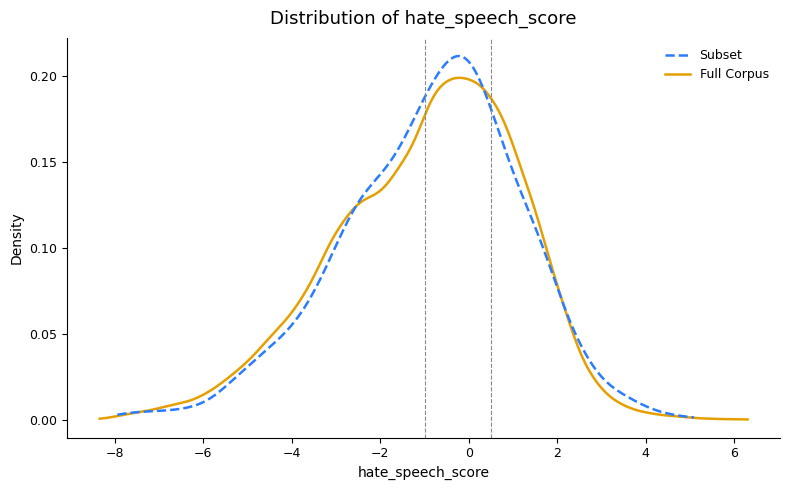

Saved.


In [32]:
import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# load full corpus, aggregate to one score per comment
dataset = datasets.load_dataset('ucberkeley-dlab/measuring-hate-speech')
df_full = dataset['train'].to_pandas()
full_data = df_full.groupby('comment_id')['hate_speech_score'].mean().dropna().values

# load jewish subset
df_jewish = pd.read_csv("data/ucberkeley-dlab_target_jewish.csv")
jewish_data = df_jewish['hate_speech_score'].dropna().values

fig, ax = plt.subplots(figsize=(8, 5))

def plot_kde(ax, data, color, label, thresholds=(-1, 0.5), linestyle='-', zorder=1):
    x = np.linspace(data.min(), data.max(), 500)
    kde = gaussian_kde(data, bw_method='scott')
    y = kde(x)

    ax.plot(x, y, color=color, linewidth=1.8, label=label, linestyle=linestyle, zorder=zorder)

    lo, hi = thresholds
    p_sup = (data < lo).mean()
    p_neu = ((data >= lo) & (data < hi)).mean()
    p_hat = (data >= hi).mean()
    return p_sup, p_neu, p_hat

thresholds = (-1, 0.5)
stats_jewish = plot_kde(ax, jewish_data, "#2B7CFF", 'Subset', thresholds, linestyle='--', zorder=2)
stats_full = plot_kde(ax, full_data, "#E69F00", 'Full Corpus', thresholds, linestyle='-', zorder=1)

for t in thresholds:
    ax.axvline(t, color='#888888', linewidth=0.8, linestyle='--')

ax.set_title('Distribution of hate_speech_score', fontsize=13, pad=10)
ax.set_xlabel('hate_speech_score', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('viz/hate_speech_score_distributions.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved.")

# Sanity Check

Grid combos x folds (inner CV AUC)
fold                      0      1      2      3      4   mean
max_depth reg_lambda                                          
10        2.0         0.828  0.828  0.849  0.835  0.838  0.836
          0.1         0.829  0.824  0.842  0.839  0.835  0.834
5         2.0         0.831  0.822  0.837  0.838  0.839  0.833
8         2.0         0.825  0.823  0.846  0.832  0.839  0.833
10        1.0         0.828  0.825  0.844  0.838  0.828  0.833
5         0.1         0.827  0.823  0.840  0.841  0.830  0.832
8         1.0         0.831  0.823  0.840  0.836  0.832  0.832
10        0.5         0.827  0.821  0.841  0.840  0.831  0.832
8         0.1         0.828  0.821  0.833  0.842  0.834  0.832
3         2.0         0.825  0.815  0.840  0.843  0.834  0.831
5         0.5         0.826  0.818  0.844  0.838  0.831  0.831
3         1.0         0.832  0.816  0.839  0.840  0.828  0.831
8         0.5         0.826  0.820  0.839  0.837  0.832  0.831
3         0.1       

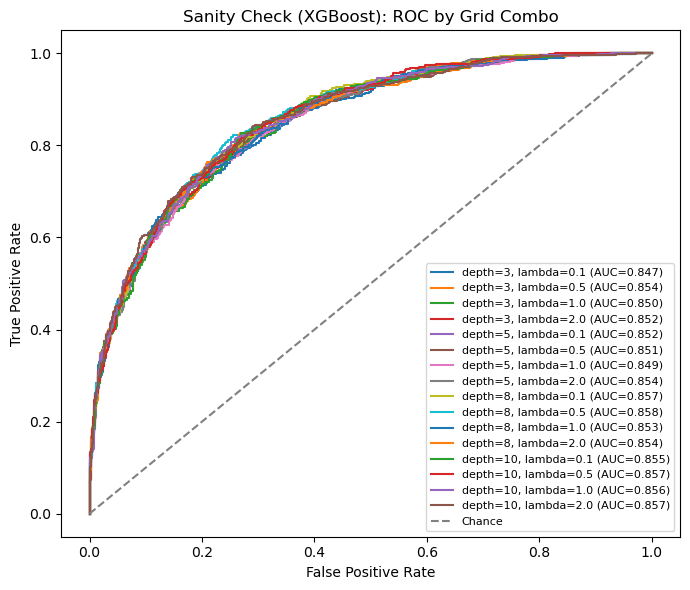

In [ ]:
# Sanity check stage (XGBoost): All definitions, YES + NO codes, scale + embeddings -> Binary

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, precision_score, recall_score

code_features = pd.read_csv("features/code_features.csv")
targets_and_folds = pd.read_csv("features/targets_and_folds.csv")

targets_and_folds["target_binary"] = (targets_and_folds["hate_speech_score"] > 0.5).astype(int)
targets_indexed = targets_and_folds.set_index("comment_id")
code_features_indexed = code_features.set_index("comment_id")

PARAM_GRID = {
    "max_depth": [3, 5, 8, 10],
    "reg_lambda": [0.1, 0.5, 1.0, 2.0],
}
GRID_COMBOS = [{"max_depth": d, "reg_lambda": l} for d in PARAM_GRID["max_depth"] for l in PARAM_GRID["reg_lambda"]]

grid_rows = []
fold_rows = []
shap_records = []  # per-fold mean |SHAP| per feature, for importance analysis
combo_probs = {i: {"true": [], "prob": []} for i in range(len(GRID_COMBOS))}  # pooled preds per grid combo, for ROC-by-grid
all_true, all_pred, all_prob = [], [], []

for fold_idx in sorted(targets_and_folds["fold"].unique()):
    fold_idx = int(fold_idx)
    train_ids = targets_and_folds.loc[targets_and_folds["fold"] != fold_idx, "comment_id"]
    test_ids = targets_and_folds.loc[targets_and_folds["fold"] == fold_idx, "comment_id"]

    pca_train = pd.read_csv(f"features/pca/fold_{fold_idx}_train.csv", index_col=0)
    pca_test = pd.read_csv(f"features/pca/fold_{fold_idx}_test.csv", index_col=0)

    X_train = code_features_indexed.loc[train_ids].join(pca_train)
    X_test = code_features_indexed.loc[test_ids].join(pca_test)
    y_train = targets_indexed.loc[train_ids, "target_binary"]
    y_test = targets_indexed.loc[test_ids, "target_binary"]

    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    scale_pos_weight = neg / pos

    base_model = XGBClassifier(
        objective="binary:logistic", eval_metric="logloss",
        n_estimators=200, learning_rate=0.05, min_child_weight=5,
        gamma=0.1, reg_alpha=0.1, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=1,
    )

    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    grid = GridSearchCV(base_model, PARAM_GRID, scoring="roc_auc", cv=inner_cv, n_jobs=-1)
    grid.fit(X_train, y_train)

    for params, mean_score, std_score in zip(
        grid.cv_results_["params"], grid.cv_results_["mean_test_score"], grid.cv_results_["std_test_score"]
    ):
        grid_rows.append({
            "fold": fold_idx, "max_depth": params["max_depth"], "reg_lambda": params["reg_lambda"],
            "inner_auc_mean": mean_score, "inner_auc_std": std_score,
        })

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)
    probs = best_model.predict_proba(X_test)[:, 1]

    all_true.extend(y_test.tolist())
    all_pred.extend(preds.tolist())
    all_prob.extend(probs.tolist())

    fold_rows.append({
        "fold": fold_idx,
        "best_depth": grid.best_params_["max_depth"],
        "best_lambda": grid.best_params_["reg_lambda"],
        "acc": accuracy_score(y_test, preds),
        "prec": precision_score(y_test, preds),
        "rec": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "auc": roc_auc_score(y_test, probs),
    })

    # SHAP importance for this fold's best model
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns)
    shap_records.append(mean_abs_shap)

    # fit every grid combo on this fold's train, predict on this fold's test, pool for ROC-by-grid
    for i, params in enumerate(GRID_COMBOS):
        m = XGBClassifier(
            objective="binary:logistic", eval_metric="logloss",
            n_estimators=200, learning_rate=0.05, min_child_weight=5,
            gamma=0.1, reg_alpha=0.1, subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=1,
            **params,
        ).fit(X_train, y_train)
        p = m.predict_proba(X_test)[:, 1]
        combo_probs[i]["true"].extend(y_test.tolist())
        combo_probs[i]["prob"].extend(p.tolist())

grid_df = pd.DataFrame(grid_rows)
pivot = grid_df.pivot_table(index=["max_depth", "reg_lambda"], columns="fold", values="inner_auc_mean")
pivot["mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("mean", ascending=False)
print("Grid combos x folds (inner CV AUC)")
print(pivot.round(3).to_string())

fold_df = pd.DataFrame(fold_rows).set_index("fold")
print("\nPer-fold test performance (best params)")
print(fold_df.round(3).to_string())

print("\nMean +/- std across folds")
summary = fold_df[["acc", "prec", "rec", "f1", "auc"]].agg(["mean", "std"]).round(3)
print(summary.to_string())

print(f"\nPooled: acc={accuracy_score(all_true, all_pred):.3f}  prec={precision_score(all_true, all_pred):.3f}  "
      f"rec={recall_score(all_true, all_pred):.3f}  f1={f1_score(all_true, all_pred):.3f}  "
      f"auc={roc_auc_score(all_true, all_prob):.3f}")

# feature importance: ALL features (codes + PCA), mean |SHAP value| across folds
shap_df = pd.DataFrame(shap_records)
importance = pd.DataFrame({
    "mean_abs_shap": shap_df.mean(axis=0),
    "std_abs_shap": shap_df.std(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print("\nTop 30 features (codes + PCA components) by mean |SHAP value| across folds")
print(importance.head(30).round(4).to_string())

n_pca_in_top30 = importance.head(30).index.str.startswith("pc_").sum()
print(f"\nPCA components in top 30: {n_pca_in_top30} / 30")

# ROC by grid combo (pooled across outer folds), not by fold
plt.figure(figsize=(7, 6))
for i, params in enumerate(GRID_COMBOS):
    fpr, tpr, _ = roc_curve(combo_probs[i]["true"], combo_probs[i]["prob"])
    auc = roc_auc_score(combo_probs[i]["true"], combo_probs[i]["prob"])
    label = f"depth={params['max_depth']}, lambda={params['reg_lambda']} (AUC={auc:.3f})"
    plt.plot(fpr, tpr, label=label)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Sanity Check (XGBoost): ROC by Grid Combo")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("viz/sanity_check_xgb_roc.png", dpi=150)
plt.show()

Grid combos x folds (inner CV AUC)
fold       0      1      2      3      4   mean
C                                              
0.005  0.823  0.835  0.852  0.831  0.842  0.837
0.001  0.821  0.836  0.851  0.831  0.840  0.836
0.010  0.818  0.832  0.849  0.825  0.840  0.833
0.100  0.790  0.808  0.818  0.793  0.816  0.805
1.000  0.766  0.781  0.789  0.763  0.784  0.777

Per-fold test performance (best params)
      best_C    acc   prec    rec     f1    auc
fold                                           
0      0.005  0.816  0.595  0.830  0.693  0.890
1      0.001  0.795  0.573  0.713  0.635  0.862
2      0.005  0.795  0.579  0.660  0.617  0.835
3      0.001  0.795  0.580  0.684  0.628  0.864
4      0.005  0.807  0.590  0.766  0.667  0.857

Mean +/- std across folds
        acc   prec    rec     f1    auc
mean  0.801  0.584  0.730  0.648  0.862
std   0.010  0.009  0.068  0.031  0.019

Pooled: acc=0.801  prec=0.584  rec=0.730  f1=0.649  auc=0.855

Top 30 features (codes + PCA components) 

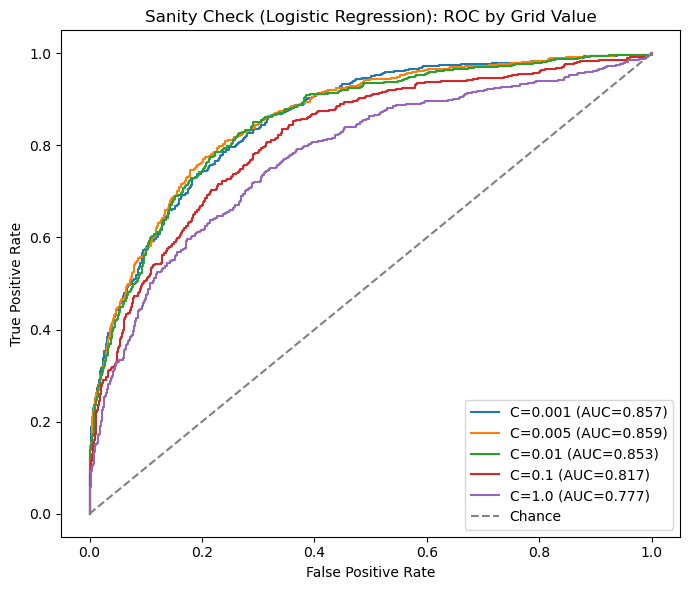

In [ ]:
# Sanity check stage (Logistic Regression): All definitions, YES + NO codes, scale + embeddings -> Binary

import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, precision_score, recall_score

warnings.filterwarnings("ignore", message=".*penalty.*deprecated.*")

code_features = pd.read_csv("features/code_features.csv")
targets_and_folds = pd.read_csv("features/targets_and_folds.csv")

targets_and_folds["target_binary"] = (targets_and_folds["hate_speech_score"] > 0.5).astype(int)
targets_indexed = targets_and_folds.set_index("comment_id")
code_features_indexed = code_features.set_index("comment_id")

PARAM_GRID = {"C": [0.001, 0.005, 0.01, 0.1, 1.0]}

grid_rows = []
fold_rows = []
coef_records = []  # per-fold coefficients on ALL features (codes + PCA), for importance analysis
combo_probs = {C: {"true": [], "prob": []} for C in PARAM_GRID["C"]}  # pooled preds per grid value, for ROC-by-grid
all_true, all_pred, all_prob = [], [], []

for fold_idx in sorted(targets_and_folds["fold"].unique()):
    fold_idx = int(fold_idx)
    train_ids = targets_and_folds.loc[targets_and_folds["fold"] != fold_idx, "comment_id"]
    test_ids = targets_and_folds.loc[targets_and_folds["fold"] == fold_idx, "comment_id"]

    pca_train = pd.read_csv(f"features/pca/fold_{fold_idx}_train.csv", index_col=0)
    pca_test = pd.read_csv(f"features/pca/fold_{fold_idx}_test.csv", index_col=0)

    X_train_raw = code_features_indexed.loc[train_ids].join(pca_train)
    X_test_raw = code_features_indexed.loc[test_ids].join(pca_test)
    y_train = targets_indexed.loc[train_ids, "target_binary"]
    y_test = targets_indexed.loc[test_ids, "target_binary"]

    scaler = StandardScaler().fit(X_train_raw)
    X_train = pd.DataFrame(scaler.transform(X_train_raw), columns=X_train_raw.columns, index=X_train_raw.index)
    X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns, index=X_test_raw.index)

    base_model = LogisticRegression(
        penalty="l2", solver="liblinear", class_weight="balanced",
        max_iter=2000, random_state=42,
    )

    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    grid = GridSearchCV(base_model, PARAM_GRID, scoring="roc_auc", cv=inner_cv, n_jobs=-1)
    grid.fit(X_train, y_train)

    for params, mean_score, std_score in zip(
        grid.cv_results_["params"], grid.cv_results_["mean_test_score"], grid.cv_results_["std_test_score"]
    ):
        grid_rows.append({"fold": fold_idx, "C": params["C"], "inner_auc_mean": mean_score, "inner_auc_std": std_score})

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)
    probs = best_model.predict_proba(X_test)[:, 1]

    all_true.extend(y_test.tolist())
    all_pred.extend(preds.tolist())
    all_prob.extend(probs.tolist())

    fold_rows.append({
        "fold": fold_idx, "best_C": grid.best_params_["C"],
        "acc": accuracy_score(y_test, preds), "prec": precision_score(y_test, preds),
        "rec": recall_score(y_test, preds), "f1": f1_score(y_test, preds),
        "auc": roc_auc_score(y_test, probs),
    })

    coefs = pd.Series(best_model.coef_[0], index=X_train.columns)
    coef_records.append(coefs)

    # fit every grid value on this fold's train, predict on this fold's test, pool for ROC-by-grid
    for C in PARAM_GRID["C"]:
        m = LogisticRegression(penalty="l2", solver="liblinear", class_weight="balanced",
                                max_iter=2000, random_state=42, C=C).fit(X_train, y_train)
        p = m.predict_proba(X_test)[:, 1]
        combo_probs[C]["true"].extend(y_test.tolist())
        combo_probs[C]["prob"].extend(p.tolist())

grid_df = pd.DataFrame(grid_rows)
pivot = grid_df.pivot_table(index="C", columns="fold", values="inner_auc_mean")
pivot["mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("mean", ascending=False)
print("Grid combos x folds (inner CV AUC)")
print(pivot.round(3).to_string())

fold_df = pd.DataFrame(fold_rows).set_index("fold")
print("\nPer-fold test performance (best params)")
print(fold_df.round(3).to_string())

print("\nMean +/- std across folds")
summary = fold_df[["acc", "prec", "rec", "f1", "auc"]].agg(["mean", "std"]).round(3)
print(summary.to_string())

print(f"\nPooled: acc={accuracy_score(all_true, all_pred):.3f}  prec={precision_score(all_true, all_pred):.3f}  "
      f"rec={recall_score(all_true, all_pred):.3f}  f1={f1_score(all_true, all_pred):.3f}  "
      f"auc={roc_auc_score(all_true, all_prob):.3f}")

# feature importance: ALL features (codes + PCA), mean coefficient across folds
coef_df = pd.DataFrame(coef_records)
importance = pd.DataFrame({
    "mean_coef": coef_df.mean(axis=0),
    "std_coef": coef_df.std(axis=0),
    "mean_abs_coef": coef_df.abs().mean(axis=0),
    "sign_consistent": coef_df.apply(lambda col: (np.sign(col) == np.sign(col.iloc[0])).all() if col.iloc[0] != 0 else False),
})
importance = importance.sort_values("mean_abs_coef", ascending=False)

print("\nTop 30 features (codes + PCA components) by mean |coefficient| across folds")
print(importance.head(30).round(3).to_string())

n_pca_in_top30 = importance.head(30).index.str.startswith("pc_").sum()
print(f"\nPCA components in top 30: {n_pca_in_top30} / 30")

# ROC by grid value (pooled across outer folds), not by fold
plt.figure(figsize=(7, 6))
for C in PARAM_GRID["C"]:
    fpr, tpr, _ = roc_curve(combo_probs[C]["true"], combo_probs[C]["prob"])
    auc = roc_auc_score(combo_probs[C]["true"], combo_probs[C]["prob"])
    plt.plot(fpr, tpr, label=f"C={C} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Sanity Check (Logistic Regression): ROC by Grid Value")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("viz/sanity_check_logreg_roc.png", dpi=150)
plt.show()

# Embedding Only

In [8]:
# shared feature builders for PCA vs raw embeddings, reused across all three targets

import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

print(f"Working directory: {os.getcwd()}")

targets_and_folds = pd.read_csv("features/targets_and_folds.csv")
targets_indexed = targets_and_folds.set_index("comment_id")
embed_df = pd.read_csv("features/embeddings.csv").set_index("comment_id")

FOLDS = sorted(targets_and_folds["fold"].unique())

RAW_SCALED_DIR = os.path.abspath("features/raw_scaled")
os.makedirs(RAW_SCALED_DIR, exist_ok=True)
print(f"Raw scaled features will be saved to: {RAW_SCALED_DIR}")

def get_ids(fold_idx):
    train_ids = targets_and_folds.loc[targets_and_folds["fold"] != fold_idx, "comment_id"]
    test_ids = targets_and_folds.loc[targets_and_folds["fold"] == fold_idx, "comment_id"]
    return train_ids, test_ids

def get_pca_features(fold_idx, train_ids, test_ids):
    pca_train = pd.read_csv(f"features/pca/fold_{int(fold_idx)}_train.csv", index_col=0)
    pca_test = pd.read_csv(f"features/pca/fold_{int(fold_idx)}_test.csv", index_col=0)
    return pca_train.loc[train_ids], pca_test.loc[test_ids]

def get_raw_features(fold_idx, train_ids, test_ids, force=False):
    raw_train_path = os.path.join(RAW_SCALED_DIR, f"fold_{int(fold_idx)}_train.csv")
    raw_test_path = os.path.join(RAW_SCALED_DIR, f"fold_{int(fold_idx)}_test.csv")

    if not force and os.path.exists(raw_train_path) and os.path.exists(raw_test_path):
        X_train = pd.read_csv(raw_train_path, index_col=0)
        X_test = pd.read_csv(raw_test_path, index_col=0)
        return X_train.loc[train_ids], X_test.loc[test_ids]

    X_train_raw = embed_df.loc[train_ids]
    X_test_raw = embed_df.loc[test_ids]
    scaler = StandardScaler().fit(X_train_raw)
    X_train = pd.DataFrame(scaler.transform(X_train_raw), index=X_train_raw.index, columns=X_train_raw.columns)
    X_test = pd.DataFrame(scaler.transform(X_test_raw), index=X_test_raw.index, columns=X_test_raw.columns)

    X_train.to_csv(raw_train_path)
    X_test.to_csv(raw_test_path)

    assert os.path.exists(raw_train_path), f"FAILED to write {raw_train_path}"
    assert os.path.exists(raw_test_path), f"FAILED to write {raw_test_path}"

    return X_train, X_test

REPRESENTATIONS = {"pca": get_pca_features, "raw": get_raw_features}

LOGREG_C = 0.005
XGB_PARAMS = dict(max_depth=5, reg_lambda=1.0)

# save of raw scaled features, with explicit confirmation per fold
for fold_idx in FOLDS:
    train_ids, test_ids = get_ids(fold_idx)
    get_raw_features(fold_idx, train_ids, test_ids, force=True)
    print(f"fold {int(fold_idx)}: saved train/test raw scaled features")

saved_files = os.listdir(RAW_SCALED_DIR)
print(f"\nFiles now in {RAW_SCALED_DIR}:")
print(saved_files)
assert len(saved_files) == len(FOLDS) * 2, f"Expected {len(FOLDS)*2} files, found {len(saved_files)}"

Working directory: c:\Users\jwram\.ipython\antisemitism_classifier\pilot
Raw scaled features will be saved to: c:\Users\jwram\.ipython\antisemitism_classifier\pilot\features\raw_scaled
fold 0: saved train/test raw scaled features
fold 1: saved train/test raw scaled features
fold 2: saved train/test raw scaled features
fold 3: saved train/test raw scaled features
fold 4: saved train/test raw scaled features

Files now in c:\Users\jwram\.ipython\antisemitism_classifier\pilot\features\raw_scaled:
['fold_0_test.csv', 'fold_0_train.csv', 'fold_1_test.csv', 'fold_1_train.csv', 'fold_2_test.csv', 'fold_2_train.csv', 'fold_3_test.csv', 'fold_3_train.csv', 'fold_4_test.csv', 'fold_4_train.csv']


In [25]:
# Embeddings baseline
# Binary target: PCA vs raw embeddings, Logistic Regression vs XGBoost

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

targets_and_folds["target_binary"] = (targets_and_folds["hate_speech_score"] > 0.5).astype(int)
targets_indexed = targets_and_folds.set_index("comment_id")

rows = []

for rep_name, get_features in REPRESENTATIONS.items():
    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        X_train, X_test = get_features(fold_idx, train_ids, test_ids)
        y_train = targets_indexed.loc[train_ids, "target_binary"]
        y_test = targets_indexed.loc[test_ids, "target_binary"]

        logreg = LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                                     class_weight="balanced", max_iter=2000, random_state=42)
        logreg.fit(X_train, y_train)
        lr_probs = logreg.predict_proba(X_test)[:, 1]
        lr_preds = logreg.predict(X_test)

        neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
        xgb = XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                             n_estimators=200, learning_rate=0.05, min_child_weight=5,
                             gamma=0.1, reg_alpha=0.1, subsample=0.8, colsample_bytree=0.8,
                             scale_pos_weight=neg/pos, random_state=42, n_jobs=1, **XGB_PARAMS)
        xgb.fit(X_train, y_train)
        xgb_probs = xgb.predict_proba(X_test)[:, 1]
        xgb_preds = xgb.predict(X_test)

        for model_name, preds, probs in [("logreg", lr_preds, lr_probs), ("xgboost", xgb_preds, xgb_probs)]:
            rows.append({
                "representation": rep_name, "model": model_name, "fold": fold_idx,
                "acc": accuracy_score(y_test, preds), "prec": precision_score(y_test, preds),
                "rec": recall_score(y_test, preds), "f1": f1_score(y_test, preds),
                "auc": roc_auc_score(y_test, probs),
            })

binary_results = pd.DataFrame(rows)
summary = binary_results.groupby(["representation", "model"])[["acc", "prec", "rec", "f1", "auc"]].agg(["mean", "std"])
print("Binary target: PCA vs raw embeddings, mean +/- std across folds")
print(summary.round(3).to_string())

Binary target: PCA vs raw embeddings, mean +/- std across folds
                          acc          prec           rec            f1           auc       
                         mean    std   mean    std   mean    std   mean    std   mean    std
representation model                                                                        
pca            logreg   0.716  0.028  0.463  0.028  0.801  0.034  0.587  0.030  0.817  0.025
               xgboost  0.769  0.008  0.551  0.020  0.454  0.021  0.498  0.010  0.793  0.019
raw            logreg   0.722  0.022  0.470  0.022  0.803  0.038  0.592  0.024  0.821  0.025
               xgboost  0.782  0.013  0.586  0.030  0.448  0.045  0.507  0.038  0.804  0.022


In [35]:
# Embeddings baseline
# Ordinal target: PCA vs raw embeddings, Ordinal Logistic vs Multinomial vs OvR vs OvO vs XGBoost (regression-threshold)

import mord
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

ordinal_map = {"supportive": 0, "neutral": 1, "hate": 2}
targets_and_folds["target_ordinal"] = targets_and_folds["ordinal_label"].map(ordinal_map)
targets_indexed = targets_and_folds.set_index("comment_id")

rows = []

for rep_name, get_features in REPRESENTATIONS.items():
    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        X_train, X_test = get_features(fold_idx, train_ids, test_ids)
        y_train = targets_indexed.loc[train_ids, "target_ordinal"]
        y_test = targets_indexed.loc[test_ids, "target_ordinal"]

        # ordinal-aware: proportional odds
        ord_logit = mord.LogisticIT(alpha=1.0 / LOGREG_C)
        ord_logit.fit(X_train.values, y_train.values)
        ord_preds = ord_logit.predict(X_test.values)

        # unordered: native multinomial (softmax) -- lbfgs's only multiclass behavior, no wrapper needed
        multi_logit = LogisticRegression(C=LOGREG_C, penalty="l2", solver="lbfgs",
                                          class_weight="balanced",
                                          max_iter=2000, random_state=42)
        multi_logit.fit(X_train, y_train)
        multi_preds = multi_logit.predict(X_test)

        # unordered: one-vs-rest, explicit wrapper for clarity (liblinear's implicit OvR is no longer settable via keyword)
        ovr_logit = OneVsRestClassifier(
            LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                                class_weight="balanced", max_iter=2000, random_state=42)
        )
        ovr_logit.fit(X_train, y_train)
        ovr_preds = ovr_logit.predict(X_test)

        # unordered: one-vs-one, same base estimator as OvR for a fair comparison of wrapper strategy alone
        ovo_logit = OneVsOneClassifier(
            LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                                class_weight="balanced", max_iter=2000, random_state=42)
        )
        ovo_logit.fit(X_train, y_train)
        ovo_preds = ovo_logit.predict(X_test)

        # ordinal-aware: XGBoost regression-then-threshold
        xgb_reg = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.05,
                                min_child_weight=5, gamma=0.1, reg_alpha=0.1, subsample=0.8,
                                colsample_bytree=0.8, random_state=42, n_jobs=1, **XGB_PARAMS)
        xgb_reg.fit(X_train, y_train)
        xgb_raw_preds = xgb_reg.predict(X_test)
        xgb_preds = np.digitize(xgb_raw_preds, bins=[0.5, 1.5])

        for model_name, preds in [
            ("ordinal_logit", ord_preds),
            ("multinomial_logit", multi_preds),
            ("ovr_logit", ovr_preds),
            ("ovo_logit", ovo_preds),
            ("xgboost_thresh", xgb_preds),
        ]:
            rows.append({
                "representation": rep_name, "model": model_name, "fold": fold_idx,
                "acc": accuracy_score(y_test, preds),
                "f1_macro": f1_score(y_test, preds, average="macro"),
                "qwk": cohen_kappa_score(y_test, preds, weights="quadratic"),
            })

ordinal_results = pd.DataFrame(rows)
summary = ordinal_results.groupby(["representation", "model"])[["acc", "f1_macro", "qwk"]].agg(["mean", "std"])
print("Ordinal target: PCA vs raw embeddings, mean +/- std across folds")
print(summary.round(3).to_string())

Ordinal target: PCA vs raw embeddings, mean +/- std across folds
                                    acc        f1_macro           qwk       
                                   mean    std     mean    std   mean    std
representation model                                                        
pca            multinomial_logit  0.573  0.019    0.561  0.018  0.512  0.038
               ordinal_logit      0.578  0.020    0.556  0.020  0.542  0.041
               ovo_logit          0.575  0.020    0.560  0.019  0.513  0.034
               ovr_logit          0.580  0.028    0.565  0.027  0.522  0.045
               xgboost_thresh     0.482  0.012    0.422  0.023  0.384  0.029
raw            multinomial_logit  0.579  0.016    0.567  0.014  0.512  0.040
               ordinal_logit      0.581  0.027    0.560  0.029  0.550  0.046
               ovo_logit          0.570  0.017    0.556  0.016  0.503  0.029
               ovr_logit          0.580  0.013    0.566  0.014  0.515  0.031
           

In [31]:
# Embeddings baseline
# Continuous target: PCA vs raw embeddings, Ridge (tuned) vs XGBoost Regressor

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import pearsonr

ALPHA_GRID = {"alpha": [0.1, 1.0, 10.0, 100.0, 1000.0, 3000.0, 5000.0]}

grid_rows = []
fold_rows = []

for rep_name, get_features in REPRESENTATIONS.items():
    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        X_train, X_test = get_features(fold_idx, train_ids, test_ids)
        y_train = targets_indexed.loc[train_ids, "hate_speech_score"]
        y_test = targets_indexed.loc[test_ids, "hate_speech_score"]

        inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
        grid = GridSearchCV(Ridge(random_state=42), ALPHA_GRID, scoring="r2", cv=inner_cv, n_jobs=1)
        grid.fit(X_train, y_train)

        for params, mean_score in zip(grid.cv_results_["params"], grid.cv_results_["mean_test_score"]):
            grid_rows.append({"representation": rep_name, "fold": fold_idx, "alpha": params["alpha"], "inner_r2": mean_score})

        ridge = grid.best_estimator_
        ridge_preds = ridge.predict(X_test)

        xgb = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.05,
                            min_child_weight=5, gamma=0.1, reg_alpha=0.1, subsample=0.8,
                            colsample_bytree=0.8, random_state=42, n_jobs=1, **XGB_PARAMS)
        xgb.fit(X_train, y_train)
        xgb_preds = xgb.predict(X_test)

        for model_name, preds, best_alpha in [
            ("ridge", ridge_preds, grid.best_params_["alpha"]),
            ("xgboost", xgb_preds, None),
        ]:
            r, _ = pearsonr(y_test, preds)
            fold_rows.append({
                "representation": rep_name, "model": model_name, "fold": fold_idx, "best_alpha": best_alpha,
                "r2": r2_score(y_test, preds), "mae": mean_absolute_error(y_test, preds),
                "pearson_r": r,
            })

# grid search report: alpha x fold x representation
grid_df = pd.DataFrame(grid_rows)
for rep_name in REPRESENTATIONS:
    pivot = grid_df[grid_df["representation"] == rep_name].pivot_table(index="alpha", columns="fold", values="inner_r2")
    pivot["mean"] = pivot.mean(axis=1)
    print(f"{rep_name} -- Ridge alpha grid (inner CV R2)")
    print(pivot.sort_values("mean", ascending=False).round(3).to_string())
    print()

# final test performance
continuous_results = pd.DataFrame(fold_rows)
summary = continuous_results.groupby(["representation", "model"])[["r2", "mae", "pearson_r"]].agg(["mean", "std"])
print("Continuous target: PCA vs raw embeddings, mean +/- std across folds")
print(summary.round(3).to_string())

pca -- Ridge alpha grid (inner CV R2)
fold      0.0    1.0    2.0    3.0    4.0   mean
alpha                                           
1000.0  0.444  0.441  0.447  0.442  0.459  0.446
3000.0  0.419  0.416  0.429  0.424  0.433  0.424
100.0   0.404  0.402  0.397  0.394  0.418  0.403
5000.0  0.386  0.384  0.398  0.394  0.399  0.392
10.0    0.384  0.383  0.374  0.374  0.397  0.382
1.0     0.382  0.380  0.371  0.371  0.394  0.380
0.1     0.381  0.380  0.371  0.371  0.394  0.379

raw -- Ridge alpha grid (inner CV R2)
fold      0.0    1.0    2.0    3.0    4.0   mean
alpha                                           
1000.0  0.455  0.445  0.453  0.447  0.468  0.453
3000.0  0.423  0.418  0.431  0.426  0.436  0.427
5000.0  0.388  0.385  0.399  0.395  0.401  0.393
100.0   0.409  0.378  0.385  0.378  0.412  0.392
10.0    0.307  0.260  0.278  0.262  0.298  0.281
1.0     0.260  0.208  0.230  0.206  0.244  0.230
0.1     0.253  0.199  0.222  0.194  0.235  0.220

Continuous target: PCA vs raw embeddings

# Internal Construct

In [37]:
# Internal construct validity stage
# Predicting the model's own code labels (E/I/A) from embeddings only, per definition + code subset

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score

flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()

code_block_map = flat[["code_id", "block"]].drop_duplicates().set_index("code_id")["block"]
definition_prefix_map = {"IHRA": "I", "Nexus": "N", "JDA": "J"}

MIN_SUPPORT = 10  # minimum non-N labels required for a code to be included as a target

def get_code_columns(definition, code_subset, code_features_columns):
    """Return the list of one-hot column names (e.g. 'D1HATE_E') to use as targets
    for a given definition ('IHRA'/'Nexus'/'JDA'/'All') and code_subset ('yes_only'/'yes_and_no')."""
    if definition == "All":
        relevant_codes = code_block_map.index
    else:
        prefix = definition_prefix_map[definition]
        relevant_codes = code_block_map[code_block_map.str.startswith(prefix)].index

    if code_subset == "yes_only":
        relevant_codes = [c for c in relevant_codes if not code_block_map[c].__contains__("NO")]
    # "yes_and_no" keeps all relevant_codes as-is

    cols = [c for code in relevant_codes for c in [f"{code}_E", f"{code}_I", f"{code}_A"] if c in code_features_columns]
    return cols

def run_internal_construct_stage(definition, code_subset, representation="raw"):
    code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")
    target_cols = get_code_columns(definition, code_subset, code_features.columns)

    # filter to codes with sufficient support
    support = code_features[target_cols].sum(axis=0)
    kept_cols = support[support >= MIN_SUPPORT].index.tolist()
    dropped_n = len(target_cols) - len(kept_cols)

    print(f"{definition} / {code_subset}: {len(kept_cols)} target columns kept, {dropped_n} dropped for low support (<{MIN_SUPPORT})")

    get_features = get_pca_features if representation == "pca" else get_raw_features
    rows = []

    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        X_train, X_test = get_features(fold_idx, train_ids, test_ids)
        y_train = code_features.loc[train_ids, kept_cols]
        y_test = code_features.loc[test_ids, kept_cols]

        logreg = MultiOutputClassifier(
            LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                               class_weight="balanced", max_iter=2000, random_state=42)
        )
        logreg.fit(X_train, y_train)
        logreg_probs = np.array([est.predict_proba(X_test)[:, 1] for est in logreg.estimators_]).T
        logreg_preds = logreg.predict(X_test)

        xgb = MultiOutputClassifier(
            XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                          n_estimators=200, learning_rate=0.05, min_child_weight=5,
                          gamma=0.1, reg_alpha=0.1, subsample=0.8, colsample_bytree=0.8,
                          random_state=42, n_jobs=-1, **XGB_PARAMS)
        )
        xgb.fit(X_train, y_train)
        xgb_probs = np.array([est.predict_proba(X_test)[:, 1] for est in xgb.estimators_]).T
        xgb_preds = xgb.predict(X_test)

        for model_name, preds, probs in [("logreg", logreg_preds, logreg_probs), ("xgboost", xgb_preds, xgb_probs)]:
            aucs, f1s = [], []
            for i, col in enumerate(kept_cols):
                if y_test.iloc[:, i].nunique() < 2:
                    continue  # skip columns with no positive/negative variation in this fold's test set
                aucs.append(roc_auc_score(y_test.iloc[:, i], probs[:, i]))
                f1s.append(f1_score(y_test.iloc[:, i], preds[:, i]))
            rows.append({
                "definition": definition, "code_subset": code_subset, "representation": representation,
                "model": model_name, "fold": fold_idx,
                "macro_auc": np.mean(aucs), "macro_f1": np.mean(f1s), "n_codes_evaluated": len(aucs),
            })

    return pd.DataFrame(rows)

In [38]:
all_stage_results = []
for definition in ["IHRA", "Nexus", "JDA", "All"]:
    for code_subset in ["yes_only", "yes_and_no"]:
        all_stage_results.append(run_internal_construct_stage(definition, code_subset))

internal_construct_results = pd.concat(all_stage_results, ignore_index=True)
summary = internal_construct_results.groupby(["definition", "code_subset", "model"])[["macro_auc", "macro_f1"]].agg(["mean", "std"])
print(summary.round(3).to_string())

IHRA / yes_only: 93 target columns kept, 54 dropped for low support (<10)
IHRA / yes_and_no: 96 target columns kept, 54 dropped for low support (<10)
Nexus / yes_only: 48 target columns kept, 18 dropped for low support (<10)
Nexus / yes_and_no: 59 target columns kept, 31 dropped for low support (<10)
JDA / yes_only: 51 target columns kept, 42 dropped for low support (<10)
JDA / yes_and_no: 72 target columns kept, 69 dropped for low support (<10)
All / yes_only: 192 target columns kept, 114 dropped for low support (<10)
All / yes_and_no: 227 target columns kept, 154 dropped for low support (<10)
                               macro_auc        macro_f1       
                                    mean    std     mean    std
definition code_subset model                                   
All        yes_and_no  logreg      0.819  0.017    0.155  0.007
                       xgboost     0.753  0.019    0.039  0.008
           yes_only    logreg      0.804  0.020    0.160  0.008
              

In [ ]:
# In-depth breakdown

import pandas as pd
import numpy as np
from scipy import stats

print(f"Available columns: {internal_construct_results.columns.tolist()}")
print(f"Total rows: {len(internal_construct_results)}")
print(f"Folds per (definition, code_subset, model): {internal_construct_results.groupby(['definition','code_subset','model']).size().unique()}")

# Full per-fold detail
print("\n=== Per-fold detail, all combinations ===")
pivot_auc = internal_construct_results.pivot_table(
    index=["definition", "code_subset", "model"], columns="fold", values="macro_auc"
)
print(pivot_auc.round(3).to_string())

# n_codes_evaluated per row: check for imbalance/instability across folds
print("\n=== n_codes_evaluated per fold (should be stable within a definition/code_subset) ===")
pivot_n = internal_construct_results.pivot_table(
    index=["definition", "code_subset"], columns="fold", values="n_codes_evaluated"
)
print(pivot_n.to_string())

# Paired comparison: logreg vs xgboost, per definition/code_subset, using the 5 matched folds
print("\n=== Paired logreg vs xgboost (Wilcoxon signed-rank across folds) ===")
rows = []
for (defn, subset), grp in internal_construct_results.groupby(["definition", "code_subset"]):
    lr = grp[grp["model"] == "logreg"].sort_values("fold")["macro_auc"].values
    xg = grp[grp["model"] == "xgboost"].sort_values("fold")["macro_auc"].values
    if len(lr) == len(xg) and len(lr) > 1:
        stat, p = stats.wilcoxon(lr, xg)
        rows.append({
            "definition": defn, "code_subset": subset,
            "logreg_mean_auc": lr.mean(), "xgboost_mean_auc": xg.mean(),
            "diff": lr.mean() - xg.mean(), "wilcoxon_p": p,
        })
paired_df = pd.DataFrame(rows)
print(paired_df.round(4).to_string(index=False))

# yes_only vs yes_and_no, within model, within definition
print("\n=== yes_only vs yes_and_no (paired across folds, within model) ===")
rows = []
for (defn, model), grp in internal_construct_results.groupby(["definition", "model"]):
    yo = grp[grp["code_subset"] == "yes_only"].sort_values("fold")["macro_auc"].values
    yn = grp[grp["code_subset"] == "yes_and_no"].sort_values("fold")["macro_auc"].values
    if len(yo) == len(yn) and len(yo) > 1:
        stat, p = stats.wilcoxon(yo, yn)
        rows.append({
            "definition": defn, "model": model,
            "yes_only_mean_auc": yo.mean(), "yes_and_no_mean_auc": yn.mean(),
            "diff": yn.mean() - yo.mean(), "wilcoxon_p": p,
        })
subset_df = pd.DataFrame(rows)
print(subset_df.round(4).to_string(index=False))

# Definition ranking with bootstrapped 95% CI on macro_auc (logreg only)
print("\n=== Definition ranking, logreg, macro_auc with 95% CI (bootstrap over folds) ===")
rows = []
rng = np.random.default_rng(42)
for (defn, subset), grp in internal_construct_results[internal_construct_results["model"] == "logreg"].groupby(["definition", "code_subset"]):
    vals = grp["macro_auc"].values
    boot_means = [rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(2000)]
    ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
    rows.append({
        "definition": defn, "code_subset": subset,
        "mean_auc": vals.mean(), "ci_lo": ci_lo, "ci_hi": ci_hi,
    })
ci_df = pd.DataFrame(rows).sort_values("mean_auc", ascending=False)
print(ci_df.round(3).to_string(index=False))

# AUC vs F1 gap
print("\n=== AUC vs F1 gap (large gap suggests default 0.5 threshold is miscalibrated) ===")
gap_df = internal_construct_results.groupby(["definition", "code_subset", "model"])[["macro_auc", "macro_f1"]].mean()
gap_df["auc_f1_gap"] = gap_df["macro_auc"] - gap_df["macro_f1"]
print(gap_df.sort_values("auc_f1_gap", ascending=False).round(3).to_string())

# Correlation between n_codes_evaluated and performance
print("\n=== Correlation: n_codes_evaluated vs macro_auc (across all rows) ===")
r, p = stats.pearsonr(internal_construct_results["n_codes_evaluated"], internal_construct_results["macro_auc"])
print(f"Pearson r = {r:.3f}, p = {p:.4f}")

Available columns: ['definition', 'code_subset', 'representation', 'model', 'fold', 'macro_auc', 'macro_f1', 'n_codes_evaluated']
Total rows: 80
Folds per (definition, code_subset, model): [5]

=== Per-fold detail, all combinations ===
fold                              0.0    1.0    2.0    3.0    4.0
definition code_subset model                                     
All        yes_and_no  logreg   0.805  0.832  0.828  0.833  0.797
                       xgboost  0.737  0.762  0.772  0.768  0.729
           yes_only    logreg   0.788  0.821  0.818  0.817  0.777
                       xgboost  0.738  0.762  0.776  0.768  0.728
IHRA       yes_and_no  logreg   0.797  0.796  0.820  0.823  0.776
                       xgboost  0.719  0.754  0.770  0.756  0.726
           yes_only    logreg   0.795  0.797  0.823  0.820  0.771
                       xgboost  0.723  0.760  0.775  0.760  0.723
JDA        yes_and_no  logreg   0.823  0.863  0.830  0.850  0.818
                       xgboost  0.745 

In [34]:
# Internal construct validity per-class (E/I/A) breakdown

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score

def run_internal_construct_by_class(definition, code_subset, representation="raw"):
    kept_cols = get_code_columns(definition, code_subset, code_features.columns)
    support = code_features[kept_cols].sum(axis=0)
    kept_cols = support[support >= MIN_SUPPORT].index.tolist()

    get_features = REPRESENTATIONS[representation]
    rows = []

    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        X_train, X_test = get_features(fold_idx, train_ids, test_ids)
        y_train = code_features.loc[train_ids, kept_cols]
        y_test = code_features.loc[test_ids, kept_cols]

        for col in kept_cols:
            if y_train[col].nunique() < 2 or y_test[col].nunique() < 2:
                continue
            response_level = col.rsplit("_", 1)[1]
            model = LogisticRegression(C=LOGREG_C, solver="liblinear",
                                        class_weight="balanced", max_iter=2000, random_state=42)
            model.fit(X_train, y_train[col])
            probs = model.predict_proba(X_test)[:, 1]
            preds = model.predict(X_test)
            rows.append({
                "definition": definition, "fold": fold_idx, "response_level": response_level,
                "code_col": col,
                "auc": roc_auc_score(y_test[col], probs),
                "f1": f1_score(y_test[col], preds, zero_division=0),
            })
    return pd.DataFrame(rows)

all_by_class = []
for definition in ["IHRA", "Nexus", "JDA", "All"]:
    all_by_class.append(run_internal_construct_by_class(definition, "yes_and_no"))

by_class_results = pd.concat(all_by_class, ignore_index=True)

print("Internal construct validity, by response level (E/I/A), pooled across codes")
print(by_class_results.groupby(["definition", "response_level"])[["auc", "f1"]].agg(["mean", "std", "count"]).round(3).to_string())

Internal construct validity, by response level (E/I/A), pooled across codes
                             auc                  f1             
                            mean    std count   mean    std count
definition response_level                                        
All        A               0.728  0.156   372  0.104  0.084   372
           E               0.896  0.070   286  0.184  0.126   286
           I               0.845  0.108   453  0.179  0.109   453
IHRA       A               0.724  0.143   154  0.116  0.085   154
           E               0.882  0.072   132  0.196  0.123   132
           I               0.811  0.107   183  0.187  0.122   183
JDA        A               0.732  0.177   118  0.093  0.078   118
           E               0.914  0.068    84  0.143  0.088    84
           I               0.875  0.099   152  0.178  0.106   152
Nexus      A               0.729  0.147   100  0.096  0.089   100
           E               0.900  0.065    70  0.214  0.155    70


In [35]:
by_code_class_results = (
    by_class_results
    .assign(code_id=lambda df: df["code_col"].str.rsplit("_", n=1).str[0])
    .groupby(["definition", "code_id", "response_level"])[["auc", "f1"]]
    .agg(["mean", "std", "count"])
    .round(3)
)

print("Internal construct validity, by individual code and response level")
print(by_code_class_results.to_string())

Internal construct validity, by individual code and response level
                                                     auc                  f1             
                                                    mean    std count   mean    std count
definition code_id                 response_level                                        
All        A1ESSENTIAL             A               0.735  0.070     5  0.228  0.050     5
                                   E               0.892  0.030     5  0.352  0.028     5
                                   I               0.763  0.028     5  0.248  0.036     5
           A2COLLECTIVEAGENDA      A               0.789  0.080     5  0.101  0.038     5
                                   E               0.898  0.075     5  0.132  0.037     5
                                   I               0.846  0.041     5  0.328  0.044     5
           A2CONSPIRACY            A               0.799  0.100     5  0.093  0.042     5
                                 

## Label Collinearity Check

In [42]:
import pandas as pd
import numpy as np
from scipy import stats

# Correlation within each (definition, model) group separately
print("=== n_codes_evaluated vs macro_auc, within each definition x model group ===")
rows = []
for (defn, model), grp in internal_construct_results.groupby(["definition", "model"]):
    if grp["n_codes_evaluated"].nunique() > 1:  # need variation to compute a correlation
        r, p = stats.pearsonr(grp["n_codes_evaluated"], grp["macro_auc"])
        rows.append({"definition": defn, "model": model, "n_rows": len(grp), "r": r, "p": p})
    else:
        rows.append({"definition": defn, "model": model, "n_rows": len(grp), "r": np.nan, "p": np.nan})
within_df = pd.DataFrame(rows)
print(within_df.round(3).to_string(index=False))

# Between-group comparison
print("\n=== Between-group: mean n_codes_evaluated vs mean macro_auc, per definition x code_subset ===")
group_means = internal_construct_results.groupby(["definition", "code_subset"]).agg(
    mean_n_codes=("n_codes_evaluated", "mean"),
    mean_auc=("macro_auc", "mean"),
).reset_index()
print(group_means.round(3).to_string(index=False))
r_between, p_between = stats.pearsonr(group_means["mean_n_codes"], group_means["mean_auc"])
print(f"\nBetween-group Pearson r = {r_between:.3f}, p = {p_between:.4f}")

# Partial correlation
import statsmodels.api as sm

df = internal_construct_results.copy()

X = pd.get_dummies(df[["definition", "model"]], drop_first=True).astype(float)
X = sm.add_constant(X)

def residualize(y, X):
    return sm.OLS(y.astype(float), X).fit().resid

resid_n = residualize(df["n_codes_evaluated"], X)
resid_auc = residualize(df["macro_auc"], X)

r_partial, p_partial = stats.pearsonr(resid_n, resid_auc)
print(f"=== Partial correlation (controlling for definition + model) ===")
print(f"r = {r_partial:.3f}, p = {p_partial:.4f}")

=== n_codes_evaluated vs macro_auc, within each definition x model group ===
definition   model  n_rows      r     p
       All  logreg      10  0.413 0.236
       All xgboost      10  0.016 0.966
      IHRA  logreg      10  0.450 0.192
      IHRA xgboost      10  0.056 0.878
       JDA  logreg      10  0.449 0.194
       JDA xgboost      10 -0.433 0.212
     Nexus  logreg      10  0.491 0.149
     Nexus xgboost      10  0.290 0.417

=== Between-group: mean n_codes_evaluated vs mean macro_auc, per definition x code_subset ===
definition code_subset  mean_n_codes  mean_auc
       All  yes_and_no         222.2     0.786
       All    yes_only         187.8     0.779
      IHRA  yes_and_no          93.8     0.774
      IHRA    yes_only          90.8     0.775
       JDA  yes_and_no          70.8     0.799
       JDA    yes_only          50.2     0.796
     Nexus  yes_and_no          57.6     0.790
     Nexus    yes_only          46.8     0.770

Between-group Pearson r = -0.115, p = 0.7864

In [6]:
import pandas as pd

code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")

# correlation matrix restricted to YES vs NO code pairs within the same definition
corr = code_features.corr()

# flag pairs with |correlation| above a threshold as a quick multicollinearity check
high_corr_pairs = (
    corr.where(lambda x: (x.abs() > 0.5) & (x.abs() < 1.0))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "code_a", "level_1": "code_b", 0: "correlation"})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs["code_a"] < high_corr_pairs["code_b"]]  # drop mirror duplicates
print(f"{len(high_corr_pairs)} feature pairs with |r| > 0.5")
print(high_corr_pairs.sort_values("correlation", key=abs, ascending=False).head(20).to_string(index=False))

486 feature pairs with |r| > 0.5
                 code_a                  code_b  correlation
            E13PEOPLE_A             E13TARGET_A     0.980412
            N1BELIEFS_E    N1NEGATIVEATTITUDE_E     0.976066
         N2CONSPIRACY_E    N4HIDDENCONSPIRACY_E     0.971564
            E13PEOPLE_I             E13TARGET_I     0.968153
            E13PEOPLE_E             E13TARGET_E     0.957238
            N1BELIEFS_A    N1NEGATIVEATTITUDE_A     0.936262
            A2DISEASE_A            A3SWASTIKA_A     0.925572
     A3DISCRIMINATION_A            A3SWASTIKA_A     0.925572
 N10SELFDETERMINATION_A N11JEWISHRIGHTSDEFINE_A     0.925572
 N10SELFDETERMINATION_A  N11SELFDETERMINATION_A     0.925572
 N10SELFDETERMINATION_A       N11JEWISHRIGHTS_A     0.912627
       E2CONTROLMEDIA_A        E2CONTROLOTHER_A     0.912134
            N1BELIEFS_I    N1NEGATIVEATTITUDE_I     0.904941
     E2CONTROLECONOMY_A        E2CONTROLMEDIA_A     0.902897
 N10SELFDETERMINATION_I N11JEWISHRIGHTSDEFINE_I     

In [44]:
# Isolate YES-vs-NO code correlations using actual block assignment

flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()

code_block_map = flat[["code_id", "block"]].drop_duplicates().set_index("code_id")["block"]

no_codes = code_block_map[code_block_map.str.contains("NO")].index.tolist()
yes_codes = code_block_map[~code_block_map.str.contains("NO")].index.tolist()

print(f"{len(no_codes)} codes from NO blocks, {len(yes_codes)} codes from YES blocks")

# restrict the correlation matrix to YES-code columns x NO-code columns only
no_cols = [c for c in code_features.columns for code in no_codes if c.startswith(f"{code}_")]
yes_cols = [c for c in code_features.columns for code in yes_codes if c.startswith(f"{code}_")]

corr_matrix = code_features[yes_cols + no_cols].corr()
yes_no_corr = corr_matrix.loc[yes_cols, no_cols]

pairs = (
    yes_no_corr.stack()
    .reset_index()
    .rename(columns={"level_0": "yes_code", "level_1": "no_code", 0: "correlation"})
)
pairs = pairs[pairs["correlation"].abs() > 0.3].sort_values("correlation", key=abs, ascending=False)

print(f"\n{len(pairs)} YES-NO column pairs with |r| > 0.3")
print(pairs.head(30).to_string(index=False))

25 codes from NO blocks, 102 codes from YES blocks

31 YES-NO column pairs with |r| > 0.3
              yes_code                 no_code  correlation
B6CHARACTERIZEISRAEL_E      C13ISRAELCOMPARE_E     0.499599
      E7ISRAELRACIST_I        N16NATIONALISM_I     0.436212
      E7ISRAELRACIST_A      C13ISRAELCOMPARE_A     0.407485
   N12DOUBLESTANDARD_I   N17DISPROPORTIONATE_I     0.407485
        A4ISRAELEVIL_A     N15HARSHCRITICISM_E     0.399031
        A4ISRAELEVIL_I     N15HARSHCRITICISM_I     0.395219
    E8DOUBLESTANDARD_I      D2DOUBLESTANDARD_I     0.384314
      E7ISRAELRACIST_I C13ISRAELINSTITUTIONS_I     0.374516
N10SELFDETERMINATION_I        N16NATIONALISM_I     0.368271
        A4ISRAELEVIL_A    N13ISRAELCRITICISM_E     0.367649
      D2ISRAELTARGET_E     N15HARSHCRITICISM_I     0.364892
        A4ISRAELEVIL_I    N13ISRAELCRITICISM_I     0.358405
      E8UNIQUEDEMAND_A        C12EQUALRIGHTS_E     0.352892
        A4ISRAELEVIL_A     C13ISRAELPOLICIES_E     0.351663
      D2IS

In [19]:
# Check whether within-block code pairs are more correlated than across-block pairs

import itertools
import pandas as pd
from scipy import stats

flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()

code_block_map = flat[["code_id", "block"]].drop_duplicates().set_index("code_id")["block"]

code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")

all_code_cols = code_features.columns.tolist()
col_to_code = {c: c.rsplit("_", 1)[0] for c in all_code_cols}
col_to_block = {c: code_block_map.get(col_to_code[c], None) for c in all_code_cols}

corr_full = code_features[all_code_cols].corr()

rows = []
for col_a, col_b in itertools.combinations(all_code_cols, 2):
    code_a, code_b = col_to_code[col_a], col_to_code[col_b]
    if code_a == code_b:
        continue
    block_a, block_b = col_to_block[col_a], col_to_block[col_b]
    if block_a is None or block_b is None:
        continue
    r = corr_full.loc[col_a, col_b]
    rows.append({
        "col_a": col_a, "col_b": col_b,
        "block_a": block_a, "block_b": block_b,
        "same_block": block_a == block_b,
        "correlation": r,
    })

pair_df = pd.DataFrame(rows)

print(f"Total pairs checked: {len(pair_df)}")
print(f"Same-block pairs: {pair_df['same_block'].sum()}")
print(f"Different-block pairs: {(~pair_df['same_block']).sum()}")

# diagnose NaN correlations before testing
nan_pairs = pair_df[pair_df["correlation"].isna()]
print(f"\n{len(nan_pairs)} pairs with NaN correlation")

nan_cols = set(nan_pairs["col_a"]).union(set(nan_pairs["col_b"]))
print(f"{len(nan_cols)} unique columns implicated in NaN correlations")

zero_var_cols = [c for c in nan_cols if code_features[c].nunique() <= 1]
print(f"{len(zero_var_cols)} of those are zero-variance (constant) columns")
print(sorted(zero_var_cols)[:20])

# drop NaNs, then compare same-block vs different-block
pair_df_clean = pair_df.dropna(subset=["correlation"])

print("\n=== Mean |correlation| by same-block vs different-block (NaNs dropped) ===")
summary = pair_df_clean.assign(abs_corr=pair_df_clean["correlation"].abs()).groupby("same_block")["abs_corr"].agg(["mean", "std", "count"])
print(summary.round(4).to_string())

same = pair_df_clean.loc[pair_df_clean["same_block"], "correlation"].abs()
diff = pair_df_clean.loc[~pair_df_clean["same_block"], "correlation"].abs()

u_stat, p_val = stats.mannwhitneyu(same, diff, alternative="greater")
print(f"\nMann-Whitney U (same-block > different-block, |correlation|): p = {p_val:.6e}")
print(f"same-block n={len(same)}, different-block n={len(diff)}")

Total pairs checked: 72009
Same-block pairs: 6579
Different-block pairs: 65430

8089 pairs with NaN correlation
381 unique columns implicated in NaN correlations
22 of those are zero-variance (constant) columns
['A3SWASTIKA_E', 'A3SWASTIKA_I', 'A4ROTHSCHILD_A', 'A5HOLOCAUSTMECHANISM_A', 'A5HOLOCAUSTMECHANISM_E', 'B8FORCECONDEMN_A', 'B8FORCECONDEMN_E', 'C12EQUALRIGHTS_I', 'C12SOLUTIONS_I', 'C14BDS_A', 'E12CRIMINALMATERIAL_E', 'E13CEMETERIES_A', 'E13CEMETERIES_E', 'E13SCHOOLS_E', 'E4HOLOCAUSTINTENT_E', 'E4HOLOCAUSTMECHANISM_E', 'E5HOLOCAUSTEXAGGERATE_E', 'E5HOLOCAUSTINVENT_E', 'E7ISRAELRACIST_E', 'N12DOUBLESTANDARD_E']

=== Mean |correlation| by same-block vs different-block (NaNs dropped) ===
              mean     std  count
same_block                       
False       0.0402  0.0756  57951
True        0.0956  0.1699   5969

Mann-Whitney U (same-block > different-block, |correlation|): p = 6.687779e-55
same-block n=5969, different-block n=57951


In [20]:
import pandas as pd
import itertools
from scipy import stats

concept_map = {
    "Collective blame": ["D2COLLECTIVEBLAME", "E11COLLECTIVEBLAME", "N3COLLECTIVEBLAME", "N4HIDDENCONSPIRACY", "N4ISRAELHAND", "N7COLLECTIVEGUILT", "B7COLLECTIVEBLAME", "B7ISRAELAGENT"],
    "Conspiracy and hidden agendas": ["D2CONSPIRACY", "E2CONSPIRACY", "E2COLLECTIVEPOWER", "N2CONSPIRACY", "N4HIDDENCONSPIRACY", "A2CONSPIRACY", "A2HIDDENPOWER", "A2COLLECTIVEAGENDA", "A4ROTHSCHILD"],
    "Control of media": ["E2CONTROLMEDIA", "N2CONTROLMEDIA", "A2CONTROLMEDIA"],
    "Control of economy": ["E2CONTROLECONOMY", "N2CONTROLECONOMY"],
    "Control of government": ["E2CONTROLGOV", "N2CONTROLGOV", "A2CONTROLGOV"],
    "Control of other institutions": ["E2CONTROLOTHER", "N2CONTROLOTHER"],
    "Double standard applied to Israel": ["E8DOUBLESTANDARD", "N12DOUBLESTANDARD"],
    "Dual loyalty trope": ["E6ISRAELLOYALTY", "E6GLOBALLOYALTY", "N5LOYALTY", "A2LOYALTY", "A3UNPATRIOTIC", "B9ISRAELLOYALTY"],
    "Denial of Jewish self-determination": ["E7JEWISHRIGHTS", "N10SELFDETERMINATION", "N11JEWISHRIGHTSDEFINE", "N11SELFDETERMINATION", "N11JEWISHRIGHTS", "B10JEWISHRIGHTS"],
    "Israel as racist endeavor": ["E7ISRAELRACIST"],
    "Holocaust denial": ["E4HOLOCAUSTDENIAL", "E5HOLOCAUSTINVENT", "A5HOLOCAUSTDENIAL"],
    "Holocaust minimization": ["E4HOLOCAUSTMINIMIZE", "E4HOLOCAUSTINTENT", "A5HOLOCAUSTMINIMIZE"],
    "Holocaust mechanism denial": ["E4HOLOCAUSTMECHANISM", "E4HOLOCAUSTINTENT", "A5HOLOCAUSTMECHANISM"],
    "Holocaust exaggeration accusation": ["E4HOLOCAUSTINTENT", "E5HOLOCAUSTINVENT", "E5HOLOCAUSTEXAGGERATE"],
    "Nazi comparison": ["E10ISRAELNAZI"],
    "Classic antisemitic symbols applied to Israel": ["E9CHARACTERIZEISRAEL", "B6CHARACTERIZEISRAEL"],
    "Classic antisemitic symbols": ["E9CLASSICSYMBOL", "E9JESUSKILLING", "E9BLOODLIBEL", "A2DISEASE", "A4DOGWHISTLE"],
    "Exaggerating Israel's influence": ["A4ISRAELINFLUENCE"],
    "Requiring Jews to condemn Israel": ["B8FORCECONDEMN"],
    "Violence": ["E1VIOLENCE", "N8VIOLENCE", "A3VIOLENCE"],
    "Incitement to violence": ["N9INCITEMENT"],
    "Stereotyping": ["D2STEREOTYPE", "E2STEREOTYPE", "A1ESSENTIAL"],
    "Dehumanization": ["E2DEHUMANIZATION"],
    "Demonization": ["E2DEMONIZE", "A2EVIL", "A4ISRAELEVIL"],
    "Jewish identity denial": ["N6IDENTITYDENY"],
    "Discrimination": ["E14DISCRIMINATION", "N1DISCRIMINATION", "A3DISCRIMINATION"],
    "Criticism of Israel not antisemitic": ["D2DOUBLESTANDARD", "N13ISRAELCRITICISM", "C13ISRAELEVIDENCE", "C13ISRAELPOLICIES", "C15DOUBLESTANDARD"],
    "Opposition to Zionism not antisemitic": ["N13ISRAELCRITICISM", "N16OPPOSITION", "C12ZIONCRITICAL"],
    "BDS not antisemitic": ["C14BDS"],
    "Harsh/disproportionate criticism not antisemitic": ["N13ISRAELCRITICISM", "N15HARSHCRITICISM", "N17DISPROPORTIONATE", "C15REASONABLE", "C15DOUBLESTANDARD"],
    "Palestinian rights / justice not antisemitic": ["C11PALESTINIANJUSTICE", "C11PALESTINIANRIGHTS"],
    "Suppression of criticism via antisemitism accusation": ["N14SUPPRESSIONFREEDOM", "N14SUPPRESSIONDIALOGUE"],
}

code_to_concepts = {}
for concept, codes in concept_map.items():
    for code in codes:
        code_to_concepts.setdefault(code, set()).add(concept)

def shares_concept(code_a, code_b):
    concepts_a = code_to_concepts.get(code_a, set())
    concepts_b = code_to_concepts.get(code_b, set())
    return len(concepts_a & concepts_b) > 0

pair_df_clean = pair_df_clean.copy()
pair_df_clean["same_concept"] = pair_df_clean.apply(
    lambda r: shares_concept(r["col_a"].rsplit("_", 1)[0], r["col_b"].rsplit("_", 1)[0]), axis=1
)

print(pd.crosstab(pair_df_clean["same_block"], pair_df_clean["same_concept"]))

same_concept_diff_block = pair_df_clean[(pair_df_clean["same_concept"]) & (~pair_df_clean["same_block"])]
diff_concept_diff_block = pair_df_clean[(~pair_df_clean["same_concept"]) & (~pair_df_clean["same_block"])]
same_block_same_concept = pair_df_clean[(pair_df_clean["same_block"]) & (pair_df_clean["same_concept"])]
same_block_diff_concept = pair_df_clean[(pair_df_clean["same_block"]) & (~pair_df_clean["same_concept"])]

print(f"\nSame concept, different block: mean |r| = {same_concept_diff_block['correlation'].abs().mean():.4f} (n={len(same_concept_diff_block)})")
print(f"Different concept, different block: mean |r| = {diff_concept_diff_block['correlation'].abs().mean():.4f} (n={len(diff_concept_diff_block)})")
print(f"Same block, same concept: mean |r| = {same_block_same_concept['correlation'].abs().mean():.4f} (n={len(same_block_same_concept)})")
print(f"Same block, different concept: mean |r| = {same_block_diff_concept['correlation'].abs().mean():.4f} (n={len(same_block_diff_concept)})")

# does block matter once you control for concept?
u_stat, p_val = stats.mannwhitneyu(
    same_block_diff_concept["correlation"].abs(),
    diff_concept_diff_block["correlation"].abs(),
    alternative="greater"
)
print(f"\nSame block (different concept) vs different block (different concept): p = {p_val:.6e}")

same_concept  False  True 
same_block                
False         56897   1054
True           5650    319

Same concept, different block: mean |r| = 0.1502 (n=1054)
Different concept, different block: mean |r| = 0.0381 (n=56897)
Same block, same concept: mean |r| = 0.1878 (n=319)
Same block, different concept: mean |r| = 0.0904 (n=5650)

Same block (different concept) vs different block (different concept): p = 3.703992e-52


# Codes Only

In [55]:
# code features (no embeddings) for ordinal target, per definition and code subset

import pandas as pd
import numpy as np
import mord
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()
code_block_map = flat[["code_id", "block"]].drop_duplicates().set_index("code_id")["block"]
definition_prefix_map = {"IHRA": "I", "Nexus": "N", "JDA": "J"}

ordinal_map = {"supportive": 0, "neutral": 1, "hate": 2}
targets_and_folds["target_ordinal"] = targets_and_folds["ordinal_label"].map(ordinal_map)
targets_indexed = targets_and_folds.set_index("comment_id")

MIN_SUPPORT = 10  # same threshold used in internal construct validity, applied here to feature columns

def get_code_columns(definition, code_subset, code_features_columns):
    if definition == "All":
        relevant_codes = code_block_map.index
    else:
        prefix = definition_prefix_map[definition]
        relevant_codes = code_block_map[code_block_map.str.startswith(prefix)].index

    if code_subset == "yes_only":
        relevant_codes = [c for c in relevant_codes if "NO" not in code_block_map[c]]

    cols = [c for code in relevant_codes for c in [f"{code}_E", f"{code}_I", f"{code}_A"] if c in code_features_columns]
    return cols

def run_codes_only_stage(definition, code_subset):
    code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")
    all_cols = get_code_columns(definition, code_subset, code_features.columns)

    support = code_features[all_cols].sum(axis=0)
    kept_cols = support[support >= MIN_SUPPORT].index.tolist()
    dropped_n = len(all_cols) - len(kept_cols)
    print(f"{definition} / {code_subset}: {len(kept_cols)} feature columns kept, {dropped_n} dropped for low support (<{MIN_SUPPORT})")

    rows = []
    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        X_train = code_features.loc[train_ids, kept_cols]
        X_test = code_features.loc[test_ids, kept_cols]
        y_train = targets_indexed.loc[train_ids, "target_ordinal"]
        y_test = targets_indexed.loc[test_ids, "target_ordinal"]

        ord_logit = mord.LogisticIT(alpha=1.0 / LOGREG_C)
        ord_logit.fit(X_train.values, y_train.values)
        ord_preds = ord_logit.predict(X_test.values)

        multi_logit = LogisticRegression(C=LOGREG_C, penalty="l2", solver="lbfgs",
                                          class_weight="balanced", max_iter=2000, random_state=42)
        multi_logit.fit(X_train, y_train)
        multi_preds = multi_logit.predict(X_test)

        ovr_logit = OneVsRestClassifier(
            LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                                class_weight="balanced", max_iter=2000, random_state=42)
        )
        ovr_logit.fit(X_train, y_train)
        ovr_preds = ovr_logit.predict(X_test)

        ovo_logit = OneVsOneClassifier(
            LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                                class_weight="balanced", max_iter=2000, random_state=42)
        )
        ovo_logit.fit(X_train, y_train)
        ovo_preds = ovo_logit.predict(X_test)

        xgb_reg = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.05,
                                min_child_weight=5, gamma=0.1, reg_alpha=0.1, subsample=0.8,
                                colsample_bytree=0.8, random_state=42, n_jobs=1, **XGB_PARAMS)
        xgb_reg.fit(X_train, y_train)
        xgb_raw_preds = xgb_reg.predict(X_test)
        xgb_preds = np.digitize(xgb_raw_preds, bins=[0.5, 1.5])

        for model_name, preds in [
            ("ordinal_logit", ord_preds),
            ("multinomial_logit", multi_preds),
            ("ovr_logit", ovr_preds),
            ("ovo_logit", ovo_preds),
            ("xgboost_thresh", xgb_preds),
        ]:
            rows.append({
                "definition": definition, "code_subset": code_subset, "model": model_name, "fold": fold_idx,
                "acc": accuracy_score(y_test, preds),
                "f1_macro": f1_score(y_test, preds, average="macro"),
                "qwk": cohen_kappa_score(y_test, preds, weights="quadratic"),
                "n_features": len(kept_cols),
            })
    return pd.DataFrame(rows)

all_codes_only_results = []
for definition in ["IHRA", "Nexus", "JDA", "All"]:
    for code_subset in ["yes_only", "yes_and_no"]:
        all_codes_only_results.append(run_codes_only_stage(definition, code_subset))

codes_only_results = pd.concat(all_codes_only_results, ignore_index=True)

print("\n=== Per-fold accuracy ===")
acc_pivot = codes_only_results.pivot_table(
    index=["definition", "code_subset", "model"], columns="fold", values="acc"
)
print(acc_pivot.round(3).to_string())

print("\n=== Per-fold macro F1 ===")
f1_pivot = codes_only_results.pivot_table(
    index=["definition", "code_subset", "model"], columns="fold", values="f1_macro"
)
print(f1_pivot.round(3).to_string())

print("\n=== Per-fold QWK ===")
qwk_pivot = codes_only_results.pivot_table(
    index=["definition", "code_subset", "model"], columns="fold", values="qwk"
)
print(qwk_pivot.round(3).to_string())

print("\n=== Summary: mean +/- std across folds ===")
summary = codes_only_results.groupby(["definition", "code_subset", "model"])[["acc", "f1_macro", "qwk"]].agg(["mean", "std"])
print(summary.round(3).to_string())

IHRA / yes_only: 93 feature columns kept, 54 dropped for low support (<10)
IHRA / yes_and_no: 96 feature columns kept, 54 dropped for low support (<10)
Nexus / yes_only: 48 feature columns kept, 18 dropped for low support (<10)
Nexus / yes_and_no: 59 feature columns kept, 31 dropped for low support (<10)
JDA / yes_only: 51 feature columns kept, 42 dropped for low support (<10)
JDA / yes_and_no: 72 feature columns kept, 69 dropped for low support (<10)
All / yes_only: 192 feature columns kept, 114 dropped for low support (<10)
All / yes_and_no: 227 feature columns kept, 154 dropped for low support (<10)

=== Per-fold accuracy ===
fold                                        0.0    1.0    2.0    3.0    4.0
definition code_subset model                                               
All        yes_and_no  multinomial_logit  0.624  0.573  0.573  0.592  0.580
                       ordinal_logit      0.589  0.541  0.541  0.557  0.572
                       ovo_logit          0.611  0.552  0.5

In [51]:
# Multinomial logistic: per-class coefficients for each code, across folds

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

def get_multinomial_importance(definition, code_subset):
    code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")
    all_cols = get_code_columns(definition, code_subset, code_features.columns)
    support = code_features[all_cols].sum(axis=0)
    kept_cols = support[support >= MIN_SUPPORT].index.tolist()

    class_names = ["supportive", "neutral", "hate"]
    coef_records = {c: [] for c in class_names}

    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        X_train = code_features.loc[train_ids, kept_cols]
        y_train = targets_indexed.loc[train_ids, "target_ordinal"]

        multi_logit = LogisticRegression(C=LOGREG_C, penalty="l2", solver="lbfgs",
                                          class_weight="balanced", max_iter=2000, random_state=42)
        multi_logit.fit(X_train, y_train)

        for row_idx, class_label in enumerate(multi_logit.classes_):
            class_name = class_names[class_label]
            coefs = pd.Series(multi_logit.coef_[row_idx], index=kept_cols)
            coef_records[class_name].append(coefs)

    importance_by_class = {}
    for class_name, records in coef_records.items():
        coef_df = pd.DataFrame(records)
        importance_by_class[class_name] = pd.DataFrame({
            "mean_coef": coef_df.mean(axis=0),
            "std_coef": coef_df.std(axis=0),
        }).sort_values("mean_coef", ascending=False)

    return importance_by_class

for definition in ["IHRA", "Nexus", "JDA", "All"]:
    for code_subset in ["yes_only", "yes_and_no"]:
        importance_by_class = get_multinomial_importance(definition, code_subset)
        for class_name in ["hate", "neutral", "supportive"]:
            print(f"\n{'='*60}\n{definition} / {code_subset} -- coefficients for '{class_name}' class\n{'='*60}")
            print("Top 10 positive:")
            print(importance_by_class[class_name].head(10).round(3).to_string())
            print("\nTop 10 negative:")
            print(importance_by_class[class_name].tail(10).round(3).to_string())


IHRA / yes_only -- coefficients for 'hate' class
Top 10 positive:
                    mean_coef  std_coef
D1HATE_E                0.221     0.010
D1MANIFEST_E            0.202     0.006
E2DEHUMANIZATION_E      0.189     0.005
D1PERCEPTION_E          0.155     0.007
E1VIOLENCE_E            0.127     0.011
E2DEMONIZE_E            0.118     0.012
E12CRIMINAL_A           0.115     0.010
E2DEHUMANIZATION_I      0.108     0.008
D2STEREOTYPE_E          0.104     0.008
D1MANIFEST_I            0.101     0.019

Top 10 negative:
                        mean_coef  std_coef
E8DOUBLESTANDARD_A         -0.004     0.005
E9CHARACTERIZEISRAEL_I     -0.004     0.003
E6ISRAELLOYALTY_I          -0.006     0.003
E2CONTROLECONOMY_I         -0.008     0.005
D2CONSPIRACY_A             -0.009     0.004
E2ALLEGATION_A             -0.010     0.003
E6GLOBALLOYALTY_I          -0.012     0.007
D2STEREOTYPE_A             -0.014     0.013
D2ISRAELTARGET_A           -0.017     0.002
D2COLLECTIVEBLAME_A        -0.027  

In [54]:
# Permutation test
# Shuffle code labels, rerun the same model, see if performance collapses

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

def run_permutation_control(definition, code_subset, n_permutations=20):
    code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")
    all_cols = get_code_columns(definition, code_subset, code_features.columns)
    support = code_features[all_cols].sum(axis=0)
    kept_cols = support[support >= MIN_SUPPORT].index.tolist()
    print(f"{definition} / {code_subset}: {len(kept_cols)} feature columns\n")

    real_rows = []
    permuted_rows = []
    rng = np.random.default_rng(42)

    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        X_train = code_features.loc[train_ids, kept_cols]
        X_test = code_features.loc[test_ids, kept_cols]
        y_train = targets_indexed.loc[train_ids, "target_binary"]
        y_test = targets_indexed.loc[test_ids, "target_binary"]

        model = LogisticRegression(C=LOGREG_C, class_weight="balanced", max_iter=2000, random_state=42)
        model.fit(X_train, y_train)
        real_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        real_rows.append({"fold": fold_idx, "real_auc": real_auc})

        for perm_idx in range(n_permutations):
            y_train_shuffled = rng.permutation(y_train.values)
            model_p = LogisticRegression(C=LOGREG_C, class_weight="balanced", max_iter=2000, random_state=42)
            model_p.fit(X_train, y_train_shuffled)
            perm_auc = roc_auc_score(y_test, model_p.predict_proba(X_test)[:, 1])
            permuted_rows.append({"fold": fold_idx, "permutation": perm_idx, "permuted_auc": perm_auc})

    real_df = pd.DataFrame(real_rows)
    permuted_df = pd.DataFrame(permuted_rows)

    print("=== Real AUC per fold ===")
    print(real_df.round(4).to_string(index=False))

    print("\n=== Permuted AUC, all runs (fold x permutation) ===")
    pivot = permuted_df.pivot(index="permutation", columns="fold", values="permuted_auc")
    print(pivot.round(4).to_string())

    print("\n=== Permuted AUC summary per fold ===")
    fold_summary = permuted_df.groupby("fold")["permuted_auc"].agg(["mean", "std", "min", "max"])
    print(fold_summary.round(4).to_string())

    print(f"\n=== Overall ===")
    print(f"Real AUC:     mean={real_df['real_auc'].mean():.4f}  std={real_df['real_auc'].std():.4f}  min={real_df['real_auc'].min():.4f}  max={real_df['real_auc'].max():.4f}")
    print(f"Permuted AUC: mean={permuted_df['permuted_auc'].mean():.4f}  std={permuted_df['permuted_auc'].std():.4f}  min={permuted_df['permuted_auc'].min():.4f}  max={permuted_df['permuted_auc'].max():.4f}")

    n_exceeded = (permuted_df["permuted_auc"] >= real_df["real_auc"].mean()).sum()
    total_perms = len(permuted_df)
    print(f"\nPermuted runs >= real mean AUC: {n_exceeded} / {total_perms} ({n_exceeded/total_perms*100:.2f}%)")
    print(f"Empirical p-value (permutation test): {(n_exceeded + 1) / (total_perms + 1):.5f}")

    return real_df, permuted_df

real_df, permuted_df = run_permutation_control("All", "yes_and_no")

All / yes_and_no: 227 feature columns

=== Real AUC per fold ===
 fold  real_auc
  0.0    0.8271
  1.0    0.7712
  2.0    0.6977
  3.0    0.7945
  4.0    0.7650

=== Permuted AUC, all runs (fold x permutation) ===
fold            0.0     1.0     2.0     3.0     4.0
permutation                                        
0            0.6807  0.3414  0.6096  0.6355  0.3443
1            0.6077  0.4143  0.3874  0.3946  0.6346
2            0.6018  0.6519  0.3867  0.5400  0.3786
3            0.6422  0.4843  0.3904  0.6285  0.3868
4            0.3810  0.6642  0.5437  0.5722  0.5018
5            0.3427  0.4084  0.4387  0.6111  0.3229
6            0.6342  0.5061  0.3986  0.5465  0.5186
7            0.5199  0.4590  0.6006  0.5068  0.3526
8            0.2934  0.6268  0.4253  0.5660  0.6554
9            0.5576  0.4524  0.3426  0.5746  0.2805
10           0.1991  0.6229  0.4557  0.7126  0.4952
11           0.7143  0.5214  0.4248  0.6415  0.5665
12           0.6584  0.6646  0.5725  0.2791  0.6680
13    

# Codes and Embeddings

In [52]:
# Code features and embeddings (PCA vs raw) predicitng ordinal target, per definition and code subset

import pandas as pd
import numpy as np
import mord
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

def run_codes_and_embeddings_stage(definition, code_subset, representation):
    code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")
    all_cols = get_code_columns(definition, code_subset, code_features.columns)
    support = code_features[all_cols].sum(axis=0)
    kept_cols = support[support >= MIN_SUPPORT].index.tolist()
    dropped_n = len(all_cols) - len(kept_cols)
    print(f"{definition} / {code_subset} / {representation}: {len(kept_cols)} code columns kept, {dropped_n} dropped for low support (<{MIN_SUPPORT})")

    get_features = REPRESENTATIONS[representation]
    rows = []
    for fold_idx in FOLDS:
        train_ids, test_ids = get_ids(fold_idx)
        embed_train, embed_test = get_features(fold_idx, train_ids, test_ids)

        X_train = code_features.loc[train_ids, kept_cols].join(embed_train)
        X_test = code_features.loc[test_ids, kept_cols].join(embed_test)
        y_train = targets_indexed.loc[train_ids, "target_ordinal"]
        y_test = targets_indexed.loc[test_ids, "target_ordinal"]

        ord_logit = mord.LogisticIT(alpha=1.0 / LOGREG_C)
        ord_logit.fit(X_train.values, y_train.values)
        ord_preds = ord_logit.predict(X_test.values)

        multi_logit = LogisticRegression(C=LOGREG_C, penalty="l2", solver="lbfgs",
                                          class_weight="balanced", max_iter=2000, random_state=42)
        multi_logit.fit(X_train, y_train)
        multi_preds = multi_logit.predict(X_test)

        ovr_logit = OneVsRestClassifier(
            LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                                class_weight="balanced", max_iter=2000, random_state=42)
        )
        ovr_logit.fit(X_train, y_train)
        ovr_preds = ovr_logit.predict(X_test)

        ovo_logit = OneVsOneClassifier(
            LogisticRegression(C=LOGREG_C, penalty="l2", solver="liblinear",
                                class_weight="balanced", max_iter=2000, random_state=42)
        )
        ovo_logit.fit(X_train, y_train)
        ovo_preds = ovo_logit.predict(X_test)

        xgb_reg = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.05,
                                min_child_weight=5, gamma=0.1, reg_alpha=0.1, subsample=0.8,
                                colsample_bytree=0.8, random_state=42, n_jobs=1, **XGB_PARAMS)
        xgb_reg.fit(X_train, y_train)
        xgb_raw_preds = xgb_reg.predict(X_test)
        xgb_preds = np.digitize(xgb_raw_preds, bins=[0.5, 1.5])

        for model_name, preds in [
            ("ordinal_logit", ord_preds),
            ("multinomial_logit", multi_preds),
            ("ovr_logit", ovr_preds),
            ("ovo_logit", ovo_preds),
            ("xgboost_thresh", xgb_preds),
        ]:
            rows.append({
                "definition": definition, "code_subset": code_subset, "representation": representation,
                "model": model_name, "fold": fold_idx,
                "acc": accuracy_score(y_test, preds),
                "f1_macro": f1_score(y_test, preds, average="macro"),
                "qwk": cohen_kappa_score(y_test, preds, weights="quadratic"),
                "n_code_features": len(kept_cols),
            })
    return pd.DataFrame(rows)

all_codes_and_embed_results = []
for definition in ["IHRA", "Nexus", "JDA", "All"]:
    for code_subset in ["yes_only", "yes_and_no"]:
        for representation in REPRESENTATIONS:
            all_codes_and_embed_results.append(run_codes_and_embeddings_stage(definition, code_subset, representation))

codes_and_embeddings_results = pd.concat(all_codes_and_embed_results, ignore_index=True)
summary = codes_and_embeddings_results.groupby(["definition", "code_subset", "representation", "model"])[["acc", "f1_macro", "qwk"]].agg(["mean", "std"])
print("\nCodes and embeddings stage: mean +/- std across folds")
print(summary.round(3).to_string())

IHRA / yes_only / pca: 93 code columns kept, 54 dropped for low support (<10)
IHRA / yes_only / raw: 93 code columns kept, 54 dropped for low support (<10)
IHRA / yes_and_no / pca: 96 code columns kept, 54 dropped for low support (<10)
IHRA / yes_and_no / raw: 96 code columns kept, 54 dropped for low support (<10)
Nexus / yes_only / pca: 48 code columns kept, 18 dropped for low support (<10)
Nexus / yes_only / raw: 48 code columns kept, 18 dropped for low support (<10)
Nexus / yes_and_no / pca: 59 code columns kept, 31 dropped for low support (<10)
Nexus / yes_and_no / raw: 59 code columns kept, 31 dropped for low support (<10)
JDA / yes_only / pca: 51 code columns kept, 42 dropped for low support (<10)
JDA / yes_only / raw: 51 code columns kept, 42 dropped for low support (<10)
JDA / yes_and_no / pca: 72 code columns kept, 69 dropped for low support (<10)
JDA / yes_and_no / raw: 72 code columns kept, 69 dropped for low support (<10)
All / yes_only / pca: 192 code columns kept, 114 dro

## NLI Analysis

Open nli.ipynb in Google Colab for the scoring pipeline.

In [ ]:
# NLI, NLI+embeddings, NLI+codes, and NLI+codes+embeddings
# Across definitions (All, IHRA, Nexus, JDA) and Targets (Continuous, Ordinal (aware + unaware), Binary)
# Ordinal also compares OvR and OvO against multinomial_logit and ordinal_logit

import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, accuracy_score, f1_score, roc_auc_score, cohen_kappa_score
from scipy.stats import pearsonr
import mord

nli_scores = pd.read_csv("features/nli_zeroshot_scores.csv")
nli_wide = nli_scores.pivot(index="comment_id", columns="code_id", values="entailment_score")

code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")
MIN_SUPPORT = 10
support = code_features.filter(regex="_[EIA]$").sum(axis=0)
kept_code_cols = support[support >= MIN_SUPPORT].index.tolist()
code_features_filtered = code_features[kept_code_cols]

# --- block membership, for splitting kept codes by definition ---
flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()
code_block_map = flat[["code_id", "block"]].drop_duplicates().set_index("code_id")["block"]
definition_prefix_map = {"I": "IHRA", "N": "Nexus", "J": "JDA"}

def code_cols_for_definition(definition):
    """Return kept code columns (post-MIN_SUPPORT filter) belonging to one definition, or all of them."""
    if definition == "All":
        return kept_code_cols
    prefix = {v: k for k, v in definition_prefix_map.items()}[definition]
    relevant_codes = code_block_map[code_block_map.str.startswith(prefix)].index
    return [c for c in kept_code_cols if c.rsplit("_", 1)[0] in relevant_codes]

def build_targets(ids):
    y_cont = targets_indexed.loc[ids, "hate_speech_score"]
    y_ord = targets_indexed.loc[ids, "ordinal_label"].map({"supportive": 0, "neutral": 1, "hate": 2})
    y_bin = (y_cont > 0.5).astype(int)
    fold_col = targets_indexed.loc[ids, "fold"]
    return y_cont, y_ord, y_bin, fold_col

def fit_and_score_all_targets(X_train, X_test, train_ids, test_ids, y_cont, y_ord, y_bin, feature_set_name, fold_idx):
    rows = []
    scaler = StandardScaler().fit(X_train)
    X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

    model = Ridge(alpha=1000, random_state=42)
    model.fit(X_train_s, y_cont.loc[train_ids])
    preds = model.predict(X_test_s)
    r, _ = pearsonr(y_cont.loc[test_ids], preds)
    rows.append({"feature_set": feature_set_name, "target": "continuous", "model": "ridge",
                 "fold": fold_idx, "r2": r2_score(y_cont.loc[test_ids], preds), "pearson_r": r})

    base_logreg = lambda: LogisticRegression(C=LOGREG_C, solver="lbfgs",
                                              class_weight="balanced", max_iter=2000, random_state=42)

    ordinal_models = {
        "ordinal_logit": mord.LogisticIT(alpha=1.0 / LOGREG_C),
        "multinomial_logit": base_logreg(),
        "ovr_logit": OneVsRestClassifier(base_logreg()),
        "ovo_logit": OneVsOneClassifier(base_logreg()),
    }

    for model_name, m in ordinal_models.items():
        m.fit(X_train_s, y_ord.loc[train_ids].values)
        preds = m.predict(X_test_s)
        rows.append({
            "feature_set": feature_set_name, "target": "ordinal", "model": model_name, "fold": fold_idx,
            "acc": accuracy_score(y_ord.loc[test_ids], preds),
            "f1_macro": f1_score(y_ord.loc[test_ids], preds, average="macro"),
            "qwk": cohen_kappa_score(y_ord.loc[test_ids], preds, weights="quadratic"),
        })

    m = LogisticRegression(C=LOGREG_C, solver="liblinear",
                            class_weight="balanced", max_iter=2000, random_state=42)
    m.fit(X_train_s, y_bin.loc[train_ids])
    preds = m.predict(X_test_s)
    probs = m.predict_proba(X_test_s)[:, 1]
    rows.append({
        "feature_set": feature_set_name, "target": "binary", "model": "logreg", "fold": fold_idx,
        "acc": accuracy_score(y_bin.loc[test_ids], preds),
        "f1": f1_score(y_bin.loc[test_ids], preds),
        "auc": roc_auc_score(y_bin.loc[test_ids], probs),
    })
    return rows

common_ids_nli = nli_wide.index.intersection(targets_indexed.index).intersection(code_features_filtered.index)
X_nli = nli_wide.loc[common_ids_nli]

y_cont, y_ord, y_bin, fold_col = build_targets(common_ids_nli)

all_rows = []
for fold_idx in sorted(fold_col.unique()):
    train_ids = fold_col[fold_col != fold_idx].index
    test_ids = fold_col[fold_col == fold_idx].index

    # nli_only (no codes, no embeddings)
    all_rows += fit_and_score_all_targets(X_nli.loc[train_ids], X_nli.loc[test_ids],
                                           train_ids, test_ids, y_cont, y_ord, y_bin, "nli_only", fold_idx)

    # nli + embeddings only, no codes
    for representation, get_features in REPRESENTATIONS.items():
        embed_train, embed_test = get_features(fold_idx, train_ids, test_ids)
        X_train = X_nli.loc[train_ids].join(embed_train)
        X_test = X_nli.loc[test_ids].join(embed_test)
        all_rows += fit_and_score_all_targets(X_train, X_test, train_ids, test_ids, y_cont, y_ord, y_bin,
                                               f"nli_plus_{representation}", fold_idx)

    # nli + codes (per definition), with and without embeddings
    for definition in ["All", "IHRA", "Nexus", "JDA"]:
        cols = code_cols_for_definition(definition)
        X_codes = code_features_filtered[cols]

        X_train = X_nli.loc[train_ids].join(X_codes.loc[train_ids])
        X_test = X_nli.loc[test_ids].join(X_codes.loc[test_ids])
        all_rows += fit_and_score_all_targets(X_train, X_test, train_ids, test_ids, y_cont, y_ord, y_bin,
                                               f"nli_plus_codes_{definition}", fold_idx)

        for representation, get_features in REPRESENTATIONS.items():
            embed_train, embed_test = get_features(fold_idx, train_ids, test_ids)
            X_train = X_nli.loc[train_ids].join(X_codes.loc[train_ids]).join(embed_train)
            X_test = X_nli.loc[test_ids].join(X_codes.loc[test_ids]).join(embed_test)
            all_rows += fit_and_score_all_targets(X_train, X_test, train_ids, test_ids, y_cont, y_ord, y_bin,
                                                   f"nli_plus_codes_{definition}_plus_{representation}", fold_idx)

all_results = pd.DataFrame(all_rows)

print("=== Continuous ===")
print(all_results[all_results["target"] == "continuous"].groupby("feature_set")[["r2", "pearson_r"]].agg(["mean", "std"]).round(3).to_string())

print("\n=== Ordinal ===")
print(all_results[all_results["target"] == "ordinal"].groupby(["feature_set", "model"])[["acc", "f1_macro", "qwk"]].agg(["mean", "std"]).round(3).to_string())

print("\n=== Binary ===")
print(all_results[all_results["target"] == "binary"].groupby("feature_set")[["acc", "f1", "auc"]].agg(["mean", "std"]).round(3).to_string())

print("=== Continuous, per fold ===")
print(all_results[all_results["target"] == "continuous"].pivot_table(index="feature_set", columns="fold", values="r2").round(3).to_string())

print("\n=== Ordinal, per fold (QWK) ===")
print(all_results[all_results["target"] == "ordinal"].pivot_table(index=["feature_set", "model"], columns="fold", values="qwk").round(3).to_string())

print("\n=== Binary, per fold (AUC) ===")
print(all_results[all_results["target"] == "binary"].pivot_table(index="feature_set", columns="fold", values="auc").round(3).to_string())

=== Continuous ===
                                  r2        pearson_r       
                                mean    std      mean    std
feature_set                                                 
nli_only                       0.521  0.022     0.724  0.015
nli_plus_codes_All             0.583  0.038     0.765  0.025
nli_plus_codes_All_plus_pca    0.607  0.028     0.780  0.018
nli_plus_codes_All_plus_raw    0.614  0.031     0.785  0.019
nli_plus_codes_IHRA            0.578  0.037     0.762  0.025
nli_plus_codes_IHRA_plus_pca   0.601  0.025     0.776  0.016
nli_plus_codes_IHRA_plus_raw   0.607  0.029     0.780  0.018
nli_plus_codes_JDA             0.562  0.035     0.751  0.023
nli_plus_codes_JDA_plus_pca    0.587  0.023     0.767  0.015
nli_plus_codes_JDA_plus_raw    0.593  0.028     0.771  0.018
nli_plus_codes_Nexus           0.570  0.034     0.757  0.022
nli_plus_codes_Nexus_plus_pca  0.595  0.020     0.773  0.013
nli_plus_codes_Nexus_plus_raw  0.602  0.026     0.777  0.017
nli_p

=========== All codes (n=237,998) ===========
                            OLS Regression Results                            
Dep. Variable:       entailment_score   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                 2.331e+04
Date:                Thu, 30 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:16:31   Log-Likelihood:                -89416.
No. Observations:              237998   AIC:                         1.788e+05
Df Residuals:                  237996   BIC:                         1.789e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

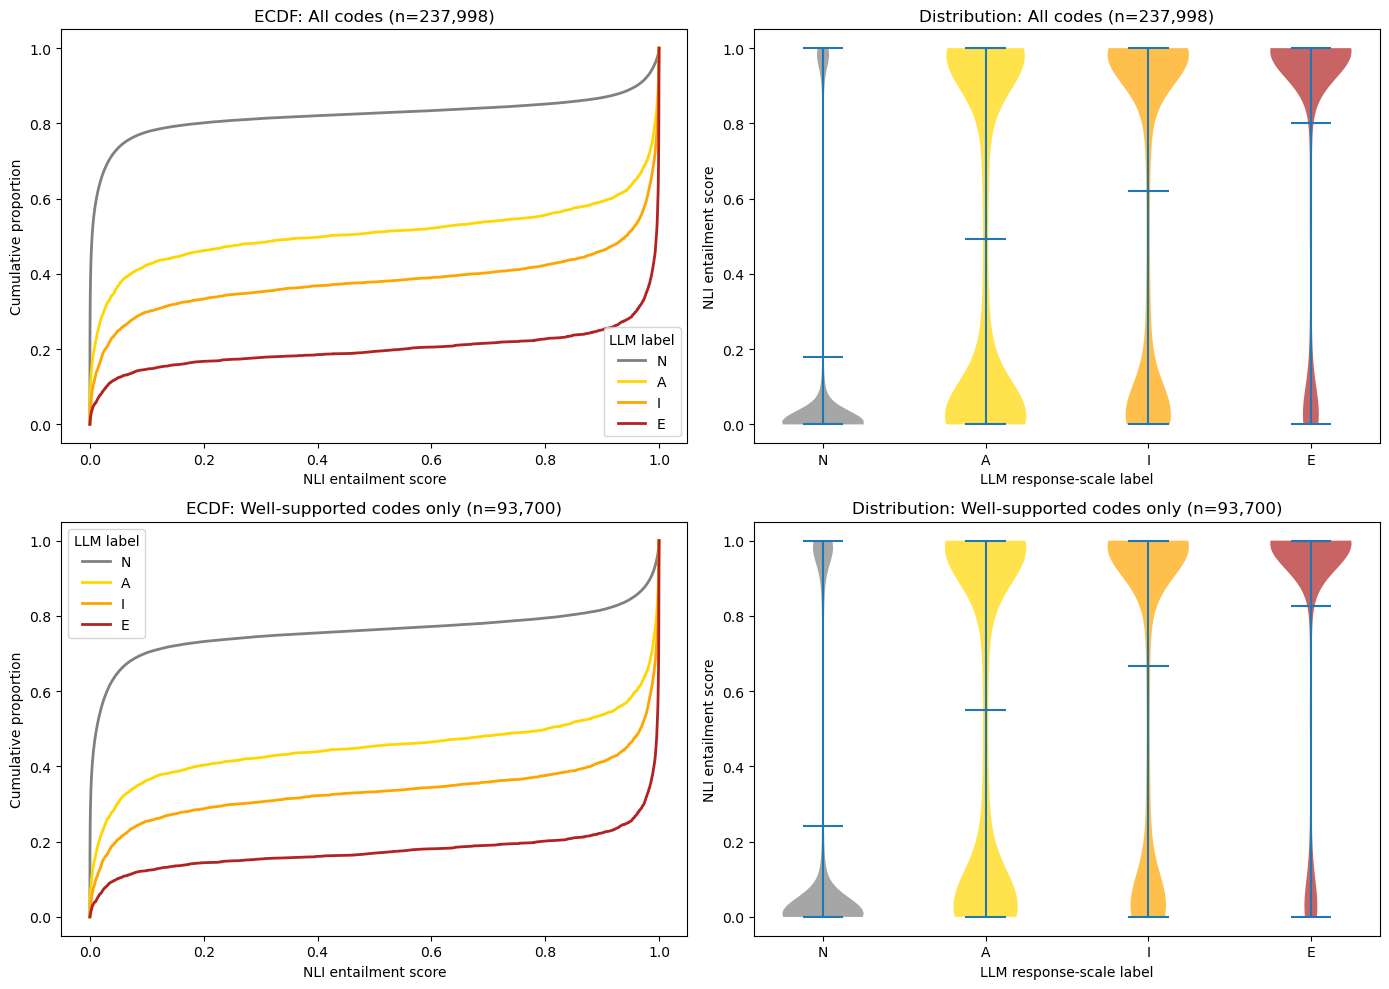

In [39]:
# Relationship between LLM ordinal label (N<A<I<E) and NLI entailment score
# comparative: full codebook vs. MIN_SUPPORT-filtered codebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import statsmodels.api as sm

LABEL_ORDER = {"N": 0, "A": 1, "I": 2, "E": 3}
labels_map = {0: "N", 1: "A", 2: "I", 3: "E"}
colors = {0: "gray", 1: "gold", 2: "orange", 3: "firebrick"}

def get_label_for_code(code_id, comment_ids, code_df):
    e_col, i_col, a_col = f"{code_id}_E", f"{code_id}_I", f"{code_id}_A"
    labels = pd.Series("N", index=comment_ids)
    labels[code_df.loc[comment_ids, a_col] == 1] = "A"
    labels[code_df.loc[comment_ids, i_col] == 1] = "I"
    labels[code_df.loc[comment_ids, e_col] == 1] = "E"
    return labels

def build_pooled(code_df):
    pooled = nli_scores.copy()
    pooled["ordinal_label_num"] = np.nan
    for code_id in pooled["code_id"].unique():
        e_col, i_col, a_col = f"{code_id}_E", f"{code_id}_I", f"{code_id}_A"
        if not all(c in code_df.columns for c in [e_col, i_col, a_col]):
            continue
        mask = pooled["code_id"] == code_id
        comment_ids = pooled.loc[mask, "comment_id"]
        labels = get_label_for_code(code_id, comment_ids.values, code_df)
        pooled.loc[mask, "ordinal_label_num"] = labels.map(LABEL_ORDER).values
    return pooled.dropna(subset=["ordinal_label_num"])

pooled_all = build_pooled(code_features)
pooled_filtered = build_pooled(code_features_filtered)

datasets = {"All codes": pooled_all, "Well-supported codes only": pooled_filtered}

for name, pooled in datasets.items():
    X = sm.add_constant(pooled["ordinal_label_num"])
    y = pooled["entailment_score"]
    model = sm.OLS(y, X).fit()
    rho, p = spearmanr(pooled["ordinal_label_num"], pooled["entailment_score"])

    print(f"=========== {name} (n={len(pooled):,}) ===========")
    print(model.summary())
    print(f"\nSpearman rho = {rho:.3f}, p = {p:.4e}")

    print(f"\nHigh-entailment (>0.5) proportion by label:")
    for label_num, label_name in labels_map.items():
        subset = pooled[pooled["ordinal_label_num"] == label_num]["entailment_score"]
        high_frac = (subset > 0.5).mean()
        print(f"  {label_name}: {high_frac*100:.1f}% high-entailment, n={len(subset):,}")
    print()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_idx, (name, pooled) in enumerate(datasets.items()):
    for label_num in [0, 1, 2, 3]:
        scores = np.sort(pooled.loc[pooled["ordinal_label_num"] == label_num, "entailment_score"].values)
        ecdf_y = np.arange(1, len(scores) + 1) / len(scores)
        axes[row_idx, 0].plot(scores, ecdf_y, label=labels_map[label_num], color=colors[label_num], linewidth=2)
    axes[row_idx, 0].set_xlabel("NLI entailment score")
    axes[row_idx, 0].set_ylabel("Cumulative proportion")
    axes[row_idx, 0].set_title(f"ECDF: {name} (n={len(pooled):,})")
    axes[row_idx, 0].legend(title="LLM label")

    violin_data = [pooled.loc[pooled["ordinal_label_num"] == ln, "entailment_score"].values for ln in [0, 1, 2, 3]]
    parts = axes[row_idx, 1].violinplot(violin_data, positions=[0, 1, 2, 3], showmeans=True, showextrema=True)
    for i, pc in enumerate(parts["bodies"]):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)
    axes[row_idx, 1].set_xticks([0, 1, 2, 3])
    axes[row_idx, 1].set_xticklabels(["N", "A", "I", "E"])
    axes[row_idx, 1].set_xlabel("LLM response-scale label")
    axes[row_idx, 1].set_ylabel("NLI entailment score")
    axes[row_idx, 1].set_title(f"Distribution: {name} (n={len(pooled):,})")

plt.tight_layout()
plt.savefig("viz/nli_vs_label_comparative.png", dpi=150)
plt.show()

In [13]:
# Load codebook in sections 

import re
from config import I_1, I_2, I_3, I_4, I_5, I_NO_1, N_1, N_2, N_NO_1, J_1, J_2, J_3, J_NO_1

blocks = {
    "I_1": I_1, "I_2": I_2, "I_3": I_3, "I_4": I_4, "I_5": I_5, "I_NO_1": I_NO_1,
    "N_1": N_1, "N_2": N_2, "N_NO_1": N_NO_1,
    "J_1": J_1, "J_2": J_2, "J_3": J_3, "J_NO_1": J_NO_1,
}

CODE_PATTERN = re.compile(
    r'-\s*([A-Z0-9]+)\s*\n?\s*"(.*?)"\s*(?=\s*(?:\d+\.\d+\s+[A-Z0-9]+\s*)?-\s*[A-Z0-9]+|\s*\Z)',
    re.MULTILINE | re.DOTALL
)

codebook = {}
for name, block_text in blocks.items():
    for match in CODE_PATTERN.finditer(block_text):
        code_id, definition = match.groups()
        codebook[code_id] = definition.replace('\\"', '"').strip()

print(f"Parsed {len(codebook)} codes")

Parsed 127 codes


In [14]:
# LLM vs NLI disagreement analysis

import pandas as pd
import numpy as np

LABEL_ORDER = {"N": 0, "A": 1, "I": 2, "E": 3}
labels_map = {0: "N", 1: "A", 2: "I", 3: "E"}

judaism = pd.read_csv("data/ucberkeley-dlab_target_jewish.csv").set_index("comment_id")

def get_label_for_code(code_id, comment_ids, code_df):
    e_col, i_col, a_col = f"{code_id}_E", f"{code_id}_I", f"{code_id}_A"
    labels = pd.Series("N", index=comment_ids)
    labels[code_df.loc[comment_ids, a_col] == 1] = "A"
    labels[code_df.loc[comment_ids, i_col] == 1] = "I"
    labels[code_df.loc[comment_ids, e_col] == 1] = "E"
    return labels

pooled = nli_scores.copy()
pooled["ordinal_label_num"] = np.nan
for code_id in pooled["code_id"].unique():
    e_col, i_col, a_col = f"{code_id}_E", f"{code_id}_I", f"{code_id}_A"
    if not all(c in code_features.columns for c in [e_col, i_col, a_col]):
        continue
    mask = pooled["code_id"] == code_id
    comment_ids = pooled.loc[mask, "comment_id"]
    labels = get_label_for_code(code_id, comment_ids.values, code_features)
    pooled.loc[mask, "ordinal_label_num"] = labels.map(LABEL_ORDER).values
pooled = pooled.dropna(subset=["ordinal_label_num"])
pooled["label"] = pooled["ordinal_label_num"].map(labels_map)

llm_confident_nli_low = pooled[
    (pooled["ordinal_label_num"] >= 2) & (pooled["entailment_score"] < 0.1)
]
llm_none_nli_high = pooled[
    (pooled["ordinal_label_num"] == 0) & (pooled["entailment_score"] > 0.9)
]

print(f"Type 1 (LLM confident E/I, NLI disagrees <0.1): {len(llm_confident_nli_low):,} pairs "
      f"({len(llm_confident_nli_low) / len(pooled) * 100:.2f}% of all pairs)")
print(f"Type 2 (LLM said N, NLI strongly disagrees >0.9): {len(llm_none_nli_high):,} pairs "
      f"({len(llm_none_nli_high) / len(pooled) * 100:.2f}% of all pairs)")

print("\n=== Type 1 disagreement, top 20 codes by count ===")
print(llm_confident_nli_low["code_id"].value_counts().head(20).to_string())

print("\n=== Type 2 disagreement, top 20 codes by count ===")
print(llm_none_nli_high["code_id"].value_counts().head(20).to_string())

flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()
code_block_map = flat[["code_id", "block"]].drop_duplicates().set_index("code_id")["block"]
definition_prefix_map = {"I": "IHRA", "N": "Nexus", "J": "JDA"}

def get_definition(code_id):
    block = code_block_map.get(code_id)
    if block is None:
        return "Unknown"
    return definition_prefix_map.get(block[0], "Unknown")

for df_subset, name in [(llm_confident_nli_low, "Type 1"), (llm_none_nli_high, "Type 2")]:
    defs = df_subset["code_id"].apply(get_definition)
    print(f"\n=== {name} disagreement by definition ===")
    print(defs.value_counts().to_string())
    print(defs.value_counts(normalize=True).round(3).to_string())

def print_full_examples(df_subset, title, codebook_defs, n=10):
    print(f"\n{'=' * 80}\n{title}\n{'=' * 80}")
    sample = df_subset.sample(min(n, len(df_subset)), random_state=42)
    for _, row in sample.iterrows():
        comment_id = row["comment_id"]
        code_id = row["code_id"]
        text = judaism.loc[comment_id, "text"] if comment_id in judaism.index else "[TEXT NOT FOUND]"
        code_def = codebook_defs.get(code_id, "[DEFINITION NOT FOUND]")
        print(f"\n--- comment_id={comment_id}  code_id={code_id}  label={row['label']}  entailment_score={row['entailment_score']:.4f} ---")
        print(f"Code definition: {code_def}")
        print(f"Full text:\n{text}")

print_full_examples(llm_confident_nli_low, "Sample Type 1 examples (LLM said E/I, NLI said essentially no)", codebook)
print_full_examples(llm_none_nli_high, "Sample Type 2 examples (LLM said N, NLI said essentially yes)", codebook)

Type 1 (LLM confident E/I, NLI disagrees <0.1): 2,456 pairs (1.03% of all pairs)
Type 2 (LLM said N, NLI strongly disagrees >0.9): 29,437 pairs (12.37% of all pairs)

=== Type 1 disagreement, top 20 codes by count ===
code_id
B10JEWISHRIGHTS       121
A4ISRAELINFLUENCE      95
D1MANIFEST             95
D2CONSPIRACY           92
E11COLLECTIVEBLAME     87
D2COLLECTIVEBLAME      83
E13PEOPLE              79
N15HARSHCRITICISM      77
A2HIDDENPOWER          66
A2LOYALTY              65
E2CONSPIRACY           58
D2ISRAELTARGET         56
C15REASONABLE          49
A4ISRAELEVIL           43
A2CONTROLGOV           42
N2CONTROLOTHER         40
E13TARGET              37
N2CONSPIRACY           37
N11JEWISHRIGHTS        36
N2CONTROLGOV           34

=== Type 2 disagreement, top 20 codes by count ===
code_id
A5HOLOCAUSTDENIAL         1404
E8DOUBLESTANDARD          1273
E3COLLECTIVEBLAME          929
N1HOSTILECONDUCT           870
E9BLOODLIBEL               862
D1PERCEPTION               825
E2STEREO

### V2 NLI Zero-shot

In [ ]:
# NLI, NLI+embeddings, NLI+codes, and NLI+codes+embeddings
# Across definitions (All, IHRA, Nexus, JDA) and Targets (Continuous, Ordinal (aware + unaware), Binary)
# Ordinal also compares OvR and OvO against multinomial_logit and ordinal_logit

import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, accuracy_score, f1_score, roc_auc_score, cohen_kappa_score
from scipy.stats import pearsonr
import mord

nli_scores = pd.read_csv("features/nli_zeroshot_scores_v2.csv")
nli_wide = nli_scores.pivot(index="comment_id", columns="code_id", values="entailment_score")

code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")
MIN_SUPPORT = 10
support = code_features.filter(regex="_[EIA]$").sum(axis=0)
kept_code_cols = support[support >= MIN_SUPPORT].index.tolist()
code_features_filtered = code_features[kept_code_cols]

# --- block membership, for splitting kept codes by definition ---
flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()
code_block_map = flat[["code_id", "block"]].drop_duplicates().set_index("code_id")["block"]
definition_prefix_map = {"I": "IHRA", "N": "Nexus", "J": "JDA"}

def code_cols_for_definition(definition):
    """Return kept code columns (post-MIN_SUPPORT filter) belonging to one definition, or all of them."""
    if definition == "All":
        return kept_code_cols
    prefix = {v: k for k, v in definition_prefix_map.items()}[definition]
    relevant_codes = code_block_map[code_block_map.str.startswith(prefix)].index
    return [c for c in kept_code_cols if c.rsplit("_", 1)[0] in relevant_codes]

def build_targets(ids):
    y_cont = targets_indexed.loc[ids, "hate_speech_score"]
    y_ord = targets_indexed.loc[ids, "ordinal_label"].map({"supportive": 0, "neutral": 1, "hate": 2})
    y_bin = (y_cont > 0.5).astype(int)
    fold_col = targets_indexed.loc[ids, "fold"]
    return y_cont, y_ord, y_bin, fold_col

def fit_and_score_all_targets(X_train, X_test, train_ids, test_ids, y_cont, y_ord, y_bin, feature_set_name, fold_idx):
    rows = []
    scaler = StandardScaler().fit(X_train)
    X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

    model = Ridge(alpha=1000, random_state=42)
    model.fit(X_train_s, y_cont.loc[train_ids])
    preds = model.predict(X_test_s)
    r, _ = pearsonr(y_cont.loc[test_ids], preds)
    rows.append({"feature_set": feature_set_name, "target": "continuous", "model": "ridge",
                 "fold": fold_idx, "r2": r2_score(y_cont.loc[test_ids], preds), "pearson_r": r})

    base_logreg = lambda: LogisticRegression(C=LOGREG_C, solver="lbfgs",
                                              class_weight="balanced", max_iter=2000, random_state=42)

    ordinal_models = {
        "ordinal_logit": mord.LogisticIT(alpha=1.0 / LOGREG_C),
        "multinomial_logit": base_logreg(),
        "ovr_logit": OneVsRestClassifier(base_logreg()),
        "ovo_logit": OneVsOneClassifier(base_logreg()),
    }

    for model_name, m in ordinal_models.items():
        m.fit(X_train_s, y_ord.loc[train_ids].values)
        preds = m.predict(X_test_s)
        rows.append({
            "feature_set": feature_set_name, "target": "ordinal", "model": model_name, "fold": fold_idx,
            "acc": accuracy_score(y_ord.loc[test_ids], preds),
            "f1_macro": f1_score(y_ord.loc[test_ids], preds, average="macro"),
            "qwk": cohen_kappa_score(y_ord.loc[test_ids], preds, weights="quadratic"),
        })

    m = LogisticRegression(C=LOGREG_C, solver="liblinear",
                            class_weight="balanced", max_iter=2000, random_state=42)
    m.fit(X_train_s, y_bin.loc[train_ids])
    preds = m.predict(X_test_s)
    probs = m.predict_proba(X_test_s)[:, 1]
    rows.append({
        "feature_set": feature_set_name, "target": "binary", "model": "logreg", "fold": fold_idx,
        "acc": accuracy_score(y_bin.loc[test_ids], preds),
        "f1": f1_score(y_bin.loc[test_ids], preds),
        "auc": roc_auc_score(y_bin.loc[test_ids], probs),
    })
    return rows

common_ids_nli = nli_wide.index.intersection(targets_indexed.index).intersection(code_features_filtered.index)
X_nli = nli_wide.loc[common_ids_nli]

y_cont, y_ord, y_bin, fold_col = build_targets(common_ids_nli)

all_rows = []
for fold_idx in sorted(fold_col.unique()):
    train_ids = fold_col[fold_col != fold_idx].index
    test_ids = fold_col[fold_col == fold_idx].index

    # nli_only (no codes, no embeddings)
    all_rows += fit_and_score_all_targets(X_nli.loc[train_ids], X_nli.loc[test_ids],
                                           train_ids, test_ids, y_cont, y_ord, y_bin, "nli_only", fold_idx)

    # nli + embeddings only, no codes
    for representation, get_features in REPRESENTATIONS.items():
        embed_train, embed_test = get_features(fold_idx, train_ids, test_ids)
        X_train = X_nli.loc[train_ids].join(embed_train)
        X_test = X_nli.loc[test_ids].join(embed_test)
        all_rows += fit_and_score_all_targets(X_train, X_test, train_ids, test_ids, y_cont, y_ord, y_bin,
                                               f"nli_plus_{representation}", fold_idx)

    # nli + codes (per definition), with and without embeddings
    for definition in ["All", "IHRA", "Nexus", "JDA"]:
        cols = code_cols_for_definition(definition)
        X_codes = code_features_filtered[cols]

        X_train = X_nli.loc[train_ids].join(X_codes.loc[train_ids])
        X_test = X_nli.loc[test_ids].join(X_codes.loc[test_ids])
        all_rows += fit_and_score_all_targets(X_train, X_test, train_ids, test_ids, y_cont, y_ord, y_bin,
                                               f"nli_plus_codes_{definition}", fold_idx)

        for representation, get_features in REPRESENTATIONS.items():
            embed_train, embed_test = get_features(fold_idx, train_ids, test_ids)
            X_train = X_nli.loc[train_ids].join(X_codes.loc[train_ids]).join(embed_train)
            X_test = X_nli.loc[test_ids].join(X_codes.loc[test_ids]).join(embed_test)
            all_rows += fit_and_score_all_targets(X_train, X_test, train_ids, test_ids, y_cont, y_ord, y_bin,
                                                   f"nli_plus_codes_{definition}_plus_{representation}", fold_idx)

all_results = pd.DataFrame(all_rows)

print("=== Continuous ===")
print(all_results[all_results["target"] == "continuous"].groupby("feature_set")[["r2", "pearson_r"]].agg(["mean", "std"]).round(3).to_string())

print("\n=== Ordinal ===")
print(all_results[all_results["target"] == "ordinal"].groupby(["feature_set", "model"])[["acc", "f1_macro", "qwk"]].agg(["mean", "std"]).round(3).to_string())

print("\n=== Binary ===")
print(all_results[all_results["target"] == "binary"].groupby("feature_set")[["acc", "f1", "auc"]].agg(["mean", "std"]).round(3).to_string())

print("=== Continuous, per fold ===")
print(all_results[all_results["target"] == "continuous"].pivot_table(index="feature_set", columns="fold", values="r2").round(3).to_string())

print("\n=== Ordinal, per fold (QWK) ===")
print(all_results[all_results["target"] == "ordinal"].pivot_table(index=["feature_set", "model"], columns="fold", values="qwk").round(3).to_string())

print("\n=== Binary, per fold (AUC) ===")
print(all_results[all_results["target"] == "binary"].pivot_table(index="feature_set", columns="fold", values="auc").round(3).to_string())

=== Continuous ===
                                  r2        pearson_r       
                                mean    std      mean    std
feature_set                                                 
nli_only                       0.527  0.035     0.730  0.029
nli_plus_codes_All             0.570  0.034     0.757  0.024
nli_plus_codes_All_plus_pca    0.612  0.031     0.784  0.020
nli_plus_codes_All_plus_raw    0.621  0.035     0.789  0.022
nli_plus_codes_IHRA            0.567  0.037     0.756  0.027
nli_plus_codes_IHRA_plus_pca   0.609  0.032     0.782  0.022
nli_plus_codes_IHRA_plus_raw   0.617  0.035     0.787  0.023
nli_plus_codes_JDA             0.557  0.037     0.750  0.028
nli_plus_codes_JDA_plus_pca    0.598  0.032     0.776  0.023
nli_plus_codes_JDA_plus_raw    0.607  0.036     0.781  0.024
nli_plus_codes_Nexus           0.560  0.038     0.752  0.028
nli_plus_codes_Nexus_plus_pca  0.603  0.033     0.780  0.023
nli_plus_codes_Nexus_plus_raw  0.612  0.037     0.784  0.024
nli_p

=========== All codes (n=237,998) ===========
                            OLS Regression Results                            
Dep. Variable:       entailment_score   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.131
Method:                 Least Squares   F-statistic:                 3.598e+04
Date:                Thu, 30 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:17:27   Log-Likelihood:                -24946.
No. Observations:              237998   AIC:                         4.990e+04
Df Residuals:                  237996   BIC:                         4.992e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

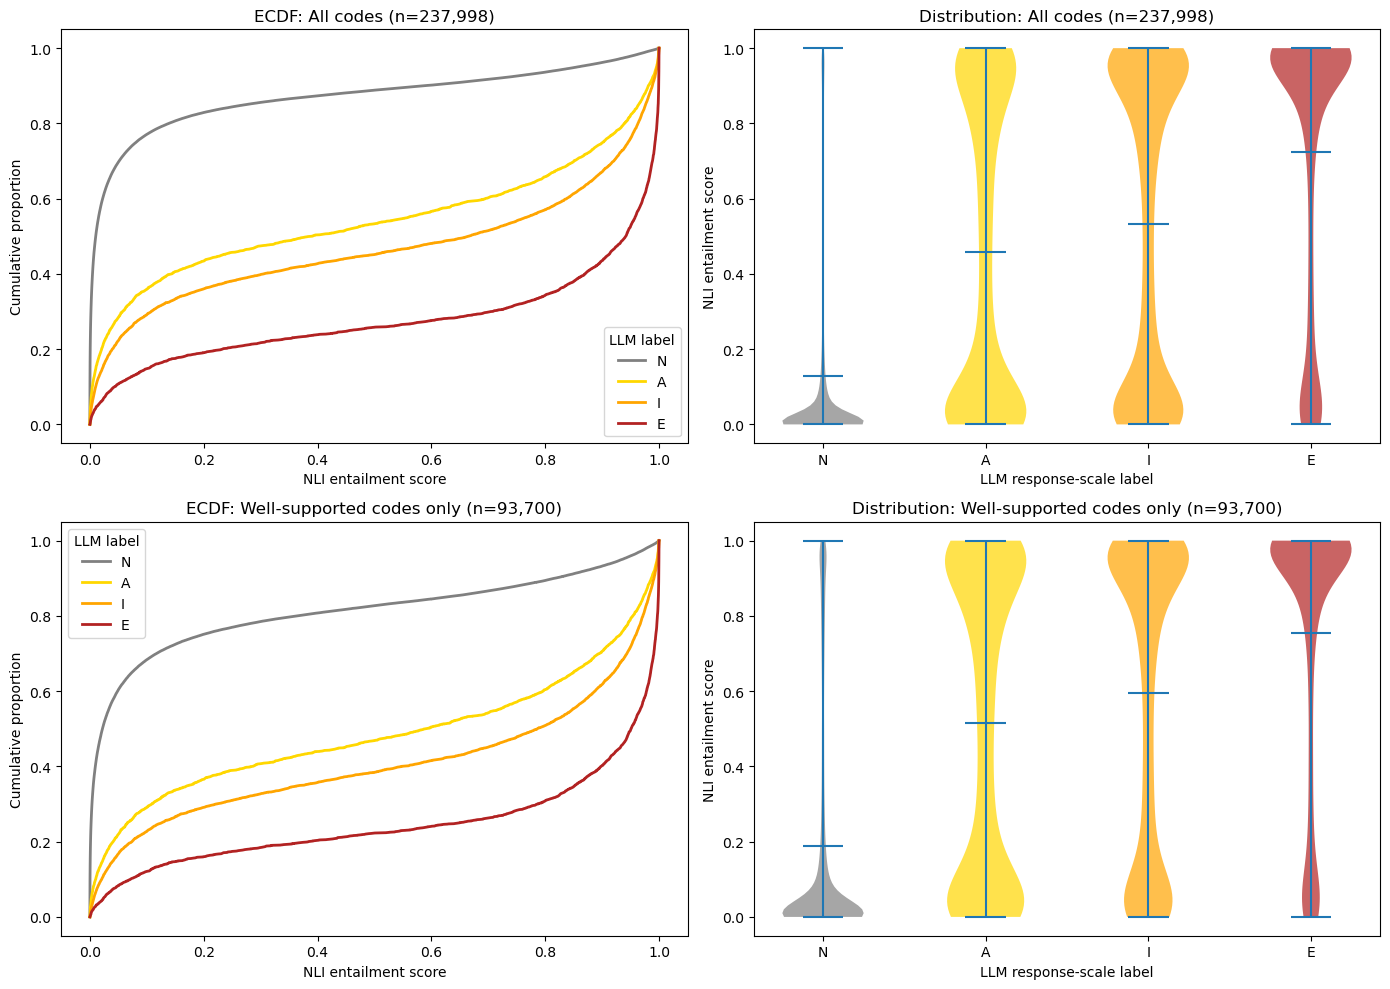

In [ ]:
# Relationship between LLM ordinal label (N<A<I<E) and NLI entailment score
# comparative: full codebook vs. MIN_SUPPORT-filtered codebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import statsmodels.api as sm

LABEL_ORDER = {"N": 0, "A": 1, "I": 2, "E": 3}
labels_map = {0: "N", 1: "A", 2: "I", 3: "E"}
colors = {0: "gray", 1: "gold", 2: "orange", 3: "firebrick"}

def get_label_for_code(code_id, comment_ids, code_df):
    e_col, i_col, a_col = f"{code_id}_E", f"{code_id}_I", f"{code_id}_A"
    labels = pd.Series("N", index=comment_ids)
    labels[code_df.loc[comment_ids, a_col] == 1] = "A"
    labels[code_df.loc[comment_ids, i_col] == 1] = "I"
    labels[code_df.loc[comment_ids, e_col] == 1] = "E"
    return labels

def build_pooled(code_df):
    pooled = nli_scores.copy()
    pooled["ordinal_label_num"] = np.nan
    for code_id in pooled["code_id"].unique():
        e_col, i_col, a_col = f"{code_id}_E", f"{code_id}_I", f"{code_id}_A"
        if not all(c in code_df.columns for c in [e_col, i_col, a_col]):
            continue
        mask = pooled["code_id"] == code_id
        comment_ids = pooled.loc[mask, "comment_id"]
        labels = get_label_for_code(code_id, comment_ids.values, code_df)
        pooled.loc[mask, "ordinal_label_num"] = labels.map(LABEL_ORDER).values
    return pooled.dropna(subset=["ordinal_label_num"])

pooled_all = build_pooled(code_features)
pooled_filtered = build_pooled(code_features_filtered)

datasets = {"All codes": pooled_all, "Well-supported codes only": pooled_filtered}

for name, pooled in datasets.items():
    X = sm.add_constant(pooled["ordinal_label_num"])
    y = pooled["entailment_score"]
    model = sm.OLS(y, X).fit()
    rho, p = spearmanr(pooled["ordinal_label_num"], pooled["entailment_score"])

    print(f"=========== {name} (n={len(pooled):,}) ===========")
    print(model.summary())
    print(f"\nSpearman rho = {rho:.3f}, p = {p:.4e}")

    print(f"\nHigh-entailment (>0.5) proportion by label:")
    for label_num, label_name in labels_map.items():
        subset = pooled[pooled["ordinal_label_num"] == label_num]["entailment_score"]
        high_frac = (subset > 0.5).mean()
        print(f"  {label_name}: {high_frac*100:.1f}% high-entailment, n={len(subset):,}")
    print()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_idx, (name, pooled) in enumerate(datasets.items()):
    for label_num in [0, 1, 2, 3]:
        scores = np.sort(pooled.loc[pooled["ordinal_label_num"] == label_num, "entailment_score"].values)
        ecdf_y = np.arange(1, len(scores) + 1) / len(scores)
        axes[row_idx, 0].plot(scores, ecdf_y, label=labels_map[label_num], color=colors[label_num], linewidth=2)
    axes[row_idx, 0].set_xlabel("NLI entailment score")
    axes[row_idx, 0].set_ylabel("Cumulative proportion")
    axes[row_idx, 0].set_title(f"ECDF: {name} (n={len(pooled):,})")
    axes[row_idx, 0].legend(title="LLM label")

    violin_data = [pooled.loc[pooled["ordinal_label_num"] == ln, "entailment_score"].values for ln in [0, 1, 2, 3]]
    parts = axes[row_idx, 1].violinplot(violin_data, positions=[0, 1, 2, 3], showmeans=True, showextrema=True)
    for i, pc in enumerate(parts["bodies"]):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)
    axes[row_idx, 1].set_xticks([0, 1, 2, 3])
    axes[row_idx, 1].set_xticklabels(["N", "A", "I", "E"])
    axes[row_idx, 1].set_xlabel("LLM response-scale label")
    axes[row_idx, 1].set_ylabel("NLI entailment score")
    axes[row_idx, 1].set_title(f"Distribution: {name} (n={len(pooled):,})")

plt.tight_layout()
plt.savefig("viz/nli_vs_label_comparative_v2.png", dpi=150)
plt.show()

In [ ]:
# LLM vs NLI v2 disagreement analysis

import pandas as pd
import numpy as np

LABEL_ORDER = {"N": 0, "A": 1, "I": 2, "E": 3}
labels_map = {0: "N", 1: "A", 2: "I", 3: "E"}

judaism = pd.read_csv("data/ucberkeley-dlab_target_jewish.csv").set_index("comment_id")

def get_label_for_code(code_id, comment_ids, code_df):
    e_col, i_col, a_col = f"{code_id}_E", f"{code_id}_I", f"{code_id}_A"
    labels = pd.Series("N", index=comment_ids)
    labels[code_df.loc[comment_ids, a_col] == 1] = "A"
    labels[code_df.loc[comment_ids, i_col] == 1] = "I"
    labels[code_df.loc[comment_ids, e_col] == 1] = "E"
    return labels

# set to v2
nli_scores = pd.read_csv("features/nli_zeroshot_scores_v2.csv")

pooled = nli_scores.copy()
pooled["ordinal_label_num"] = np.nan
for code_id in pooled["code_id"].unique():
    e_col, i_col, a_col = f"{code_id}_E", f"{code_id}_I", f"{code_id}_A"
    if not all(c in code_features.columns for c in [e_col, i_col, a_col]):
        continue
    mask = pooled["code_id"] == code_id
    comment_ids = pooled.loc[mask, "comment_id"]
    labels = get_label_for_code(code_id, comment_ids.values, code_features)
    pooled.loc[mask, "ordinal_label_num"] = labels.map(LABEL_ORDER).values
pooled = pooled.dropna(subset=["ordinal_label_num"])
pooled["label"] = pooled["ordinal_label_num"].map(labels_map)

llm_confident_nli_low = pooled[
    (pooled["ordinal_label_num"] >= 2) & (pooled["entailment_score"] < 0.1)
]
llm_none_nli_high = pooled[
    (pooled["ordinal_label_num"] == 0) & (pooled["entailment_score"] > 0.9)
]

print(f"Type 1 (LLM confident E/I, NLI disagrees <0.1): {len(llm_confident_nli_low):,} pairs "
      f"({len(llm_confident_nli_low) / len(pooled) * 100:.2f}% of all pairs)")
print(f"Type 2 (LLM said N, NLI strongly disagrees >0.9): {len(llm_none_nli_high):,} pairs "
      f"({len(llm_none_nli_high) / len(pooled) * 100:.2f}% of all pairs)")

print("\n=== Type 1 disagreement, top 20 codes by count ===")
print(llm_confident_nli_low["code_id"].value_counts().head(20).to_string())

print("\n=== Type 2 disagreement, top 20 codes by count ===")
print(llm_none_nli_high["code_id"].value_counts().head(20).to_string())

flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()
code_block_map = flat[["code_id", "block"]].drop_duplicates().set_index("code_id")["block"]
definition_prefix_map = {"I": "IHRA", "N": "Nexus", "J": "JDA"}

def get_definition(code_id):
    block = code_block_map.get(code_id)
    if block is None:
        return "Unknown"
    return definition_prefix_map.get(block[0], "Unknown")

for df_subset, name in [(llm_confident_nli_low, "Type 1"), (llm_none_nli_high, "Type 2")]:
    defs = df_subset["code_id"].apply(get_definition)
    print(f"\n=== {name} disagreement by definition ===")
    print(defs.value_counts().to_string())
    print(defs.value_counts(normalize=True).round(3).to_string())

def print_full_examples(df_subset, title, codebook_defs, n=10):
    print(f"\n{'=' * 80}\n{title}\n{'=' * 80}")
    sample = df_subset.sample(min(n, len(df_subset)), random_state=42)
    for _, row in sample.iterrows():
        comment_id = row["comment_id"]
        code_id = row["code_id"]
        text = judaism.loc[comment_id, "text"] if comment_id in judaism.index else "[TEXT NOT FOUND]"
        code_def = codebook_defs.get(code_id, "[DEFINITION NOT FOUND]")
        print(f"\n--- comment_id={comment_id}  code_id={code_id}  label={row['label']}  entailment_score={row['entailment_score']:.4f} ---")
        print(f"Code definition: {code_def}")
        print(f"Full text:\n{text}")

print_full_examples(llm_confident_nli_low, "Sample Type 1 examples (LLM said E/I, NLI said essentially no)", codebook)
print_full_examples(llm_none_nli_high, "Sample Type 2 examples (LLM said N, NLI said essentially yes)", codebook)

Type 1 (LLM confident E/I, NLI disagrees <0.1): 2,412 pairs (1.01% of all pairs)
Type 2 (LLM said N, NLI strongly disagrees >0.9): 8,529 pairs (3.58% of all pairs)

=== Type 1 disagreement, top 20 codes by count ===
code_id
A2COLLECTIVEAGENDA    113
E2COLLECTIVEPOWER     110
E13PEOPLE             109
D2COLLECTIVEBLAME     108
E2ALLEGATION           95
E11COLLECTIVEBLAME     85
N2CONTROLOTHER         84
N15HARSHCRITICISM      75
A4ISRAELEVIL           73
E2CONSPIRACY           63
A2LOYALTY              63
B10JEWISHRIGHTS        61
E2CONTROLOTHER         60
A2EVIL                 59
N2CONTROLGOV           55
A2HIDDENPOWER          55
A2CONTROLGOV           52
C15REASONABLE          49
E2CONTROLGOV           49
E6GLOBALLOYALTY        42

=== Type 2 disagreement, top 20 codes by count ===
code_id
D2STEREOTYPE              649
C12ZIONCRITICAL           466
N1DISCRIMINATION          466
E1RADICAL                 418
N14SUPPRESSIONDIALOGUE    388
N1HOSTILECONDUCT          380
E12CRIMINALDENIA

#### Meta-Analysis

In [ ]:
# Multicollinearity check: v1 vs v2 entailment scores, against codes and raw embeddings
# Fast VIF via correlation matrix inversion

import pandas as pd
import numpy as np

def compute_vif_fast(X, label):
    nunique = X.nunique()
    constant_cols = nunique[nunique <= 1].index.tolist()
    if constant_cols:
        print(f"Dropping {len(constant_cols)} constant columns: {constant_cols}")
        X = X.drop(columns=constant_cols)

    corr = X.corr()
    np.fill_diagonal(corr.values, 0)
    exact_pairs = [(corr.index[i], corr.columns[j])
                   for i, j in zip(*np.where(np.isclose(corr.abs(), 1.0)))
                   if i < j]
    if exact_pairs:
        print(f"Found {len(exact_pairs)} exactly collinear pairs (dropping second of each): {exact_pairs}")
        drop_cols = list({b for _, b in exact_pairs})
        X = X.drop(columns=drop_cols)

    corr_matrix = X.corr().values
    vif_values = np.diag(np.linalg.pinv(corr_matrix))

    vif_data = pd.DataFrame({"feature": X.columns, "vif": vif_values})
    print(f"\n--- {label} ---")
    print(f"n_features = {len(vif_data)}, mean VIF = {vif_data['vif'].mean():.2f}, "
          f"median VIF = {vif_data['vif'].median():.2f}, "
          f"n_features with VIF > 10 = {(vif_data['vif'] > 10).sum()}")
    print(vif_data.sort_values("vif", ascending=False).head(10).to_string(index=False))
    return vif_data

nli_v1 = pd.read_csv("features/nli_zeroshot_scores.csv").pivot(index="comment_id", columns="code_id", values="entailment_score")
nli_v2 = pd.read_csv("features/nli_zeroshot_scores_v2.csv").pivot(index="comment_id", columns="code_id", values="entailment_score")
raw_embeddings = pd.read_csv("features/embeddings.csv").set_index("comment_id")

vif_results = {}
for version_label, nli_wide_version in [("v1", nli_v1), ("v2", nli_v2)]:
    common_ids = nli_wide_version.index.intersection(code_features_filtered.index)
    X_nli = nli_wide_version.loc[common_ids]

    X = X_nli.join(code_features_filtered.loc[common_ids]).dropna()
    vif_results[f"{version_label}_plus_codes"] = compute_vif_fast(X, f"{version_label}: NLI + codes")

    common_ids_raw = common_ids.intersection(raw_embeddings.index)
    X = X_nli.loc[common_ids_raw].join(raw_embeddings.loc[common_ids_raw]).dropna()
    vif_results[f"{version_label}_plus_raw"] = compute_vif_fast(X, f"{version_label}: NLI + raw embeddings")

Found 3 exactly collinear pairs (dropping second of each): [('E2CONTROLECONOMY', 'N2CONTROLECONOMY'), ('E2CONTROLGOV', 'N2CONTROLGOV'), ('E2CONTROLMEDIA', 'N2CONTROLMEDIA')]

--- v1: NLI + codes ---
n_features = 351, mean VIF = 5.30, median VIF = 3.76, n_features with VIF > 10 = 31
             feature       vif
N1NEGATIVEATTITUDE_E 45.602995
         N1BELIEFS_E 42.685331
         E13TARGET_I 39.674578
         E13PEOPLE_I 36.873614
         E13TARGET_A 36.198840
         E13PEOPLE_A 35.328173
      N2CONSPIRACY_E 32.164652
N4HIDDENCONSPIRACY_E 32.035779
         E13PEOPLE_E 24.919379
         E13TARGET_E 23.700531
Found 3 exactly collinear pairs (dropping second of each): [('E2CONTROLECONOMY', 'N2CONTROLECONOMY'), ('E2CONTROLGOV', 'N2CONTROLGOV'), ('E2CONTROLMEDIA', 'N2CONTROLMEDIA')]

--- v1: NLI + raw embeddings ---
n_features = 508, mean VIF = 7.60, median VIF = 7.30, n_features with VIF > 10 = 40
           feature        vif
           emb_223 184.717793
           emb_127 135.6

In [ ]:
# Per-code disagreement between LLM ordinal label and NLI entailment score, v1 and v2
# Flags codes where entailment doesn't track the LLM's own label, prints the actual hypothesis used

import pandas as pd
from scipy.stats import spearmanr

label_map = {"N": 0, "A": 1, "I": 2, "E": 3}
llm_labels = flat[["comment_id", "code_id", "label"]].copy()  # adjust column name if not "response"
llm_labels["ordinal_label_num"] = llm_labels["label"].map(label_map)

HYPOTHESIS_TEMPLATE = "This text expresses: {}."

def per_code_disagreement(nli_path, version_label):
    nli_scores = pd.read_csv(nli_path)
    merged = nli_scores.merge(llm_labels, on=["comment_id", "code_id"], how="inner")

    rows = []
    for code_id, group in merged.groupby("code_id"):
        if group["ordinal_label_num"].nunique() < 2:
            continue  # can't compute correlation with no variance in labels
        rho, p = spearmanr(group["ordinal_label_num"], group["entailment_score"])
        mean_by_label = group.groupby("ordinal_label_num")["entailment_score"].mean()
        rows.append({
            "code_id": code_id,
            "n": len(group),
            "spearman_rho": rho,
            "p": p,
            "mean_entail_N": mean_by_label.get(0, float("nan")),
            "mean_entail_E": mean_by_label.get(3, float("nan")),
        })

    result = pd.DataFrame(rows).sort_values("spearman_rho")
    print(f"\n=== {version_label}: codes with weakest/most inverted LLM-NLI agreement ===")
    print(result.head(15).to_string(index=False))
    return result

v1_disagreement = per_code_disagreement("features/nli_zeroshot_scores.csv", "v1")
v2_disagreement = per_code_disagreement("features/nli_zeroshot_scores_v2.csv", "v2")

# codes that show weak/inverted agreement in BOTH versions, strongest candidates for a real failure mode
consistent_failures = set(v1_disagreement[v1_disagreement["spearman_rho"] < 0.1]["code_id"]) & \
                       set(v2_disagreement[v2_disagreement["spearman_rho"] < 0.1]["code_id"])

print(f"\n=== Codes with weak/inverted agreement (rho < 0.1) in BOTH v1 and v2 ===")
for code_id in sorted(consistent_failures):
    definition = codebook[code_id]
    hypothesis = HYPOTHESIS_TEMPLATE.format(definition)
    v1_rho = v1_disagreement.loc[v1_disagreement["code_id"] == code_id, "spearman_rho"].values[0]
    v2_rho = v2_disagreement.loc[v2_disagreement["code_id"] == code_id, "spearman_rho"].values[0]
    print(f"\n{code_id}  (v1 rho={v1_rho:.3f}, v2 rho={v2_rho:.3f})")
    print(f"  Hypothesis: \"{hypothesis}\"")


=== v1: codes with weakest/most inverted LLM-NLI agreement ===
             code_id    n  spearman_rho        p  mean_entail_N  mean_entail_E
A5HOLOCAUSTMECHANISM 1874     -0.083260 0.000308       0.182223            NaN
       E13CEMETERIES 1874     -0.023599 0.307239       0.032158            NaN
     N11JEWISHRIGHTS 1874     -0.021403 0.354439       0.047016       0.042959
   N15HARSHCRITICISM 1874      0.004548 0.844008       0.112351       0.169879
   N12DOUBLESTANDARD 1874      0.006290 0.785541       0.028515            NaN
E4HOLOCAUSTMECHANISM 1874      0.012008 0.603406       0.054288            NaN
      C13ISRAELNORMS 1874      0.012559 0.586889       0.043449       0.102699
          E13SCHOOLS 1874      0.014267 0.537082       0.007483            NaN
       C15REASONABLE 1874      0.015332 0.507121       0.035758       0.034575
 N17DISPROPORTIONATE 1874      0.019160 0.407136       0.353359            NaN
          A3SWASTIKA 1874      0.020455 0.376170       0.005344    

In [52]:
support_check = llm_labels[llm_labels["code_id"].isin(consistent_failures)].groupby("code_id")["label"].value_counts().unstack(fill_value=0)
print(support_check.to_string())

label                     A   E   I     N
code_id                                  
A2DISEASE                 6   1   6  1861
A2LOYALTY                20   7  58  1789
A3DISCRIMINATION          6   5   4  1859
A3SWASTIKA                7   0   0  1867
A5HOLOCAUSTMECHANISM      0   0  10  1864
A5HOLOCAUSTMINIMIZE       4   2   4  1864
B8FORCECONDEMN            0   0   1  1873
C11PALESTINIANRIGHTS     30   7  15  1822
C12EQUALRIGHTS            6   1   0  1867
C12SOLUTIONS              5   1   0  1868
C13ISRAELDISCRIMINATION   4   4  10  1856
C13ISRAELINSTITUTIONS     7   1   8  1858
C13ISRAELNORMS            5   7   5  1857
C14BDS                    0   5   1  1868
C15DOUBLESTANDARD        11  19   6  1838
D2DOUBLESTANDARD         57  13  14  1790
E13CEMETERIES             0   0   1  1873
E13PEOPLE                51  48  62  1713
E13SCHOOLS                1   0   1  1872
E14DISCRIMINATION        23   7   8  1836
E4HOLOCAUSTDENIAL         3   1  10  1860
E4HOLOCAUSTINTENT         4   0   

In [ ]:
# Full text printout: E12/E13 cluster, every non-N LLM label, and every LLM/NLI disagreement (v1 and v2)

import pandas as pd

CRIMINAL_CODES = [
    "E12CRIMINAL", "E12CRIMINALDENIAL", "E12CRIMINALMATERIAL",
    "E13TARGET", "E13PEOPLE", "E13PROPERTY", "E13BUILDINGS",
    "E13SCHOOLS", "E13WORSHIP", "E13CEMETERIES",
]

label_map = {"N": 0, "A": 1, "I": 2, "E": 3}
llm_labels = flat[flat["code_id"].isin(CRIMINAL_CODES)][["comment_id", "code_id", "label"]].copy()

print("=" * 80)
print("Every non-N LLM label on the E12/E13 criminal-act cluster")
print("=" * 80)
non_n = llm_labels[llm_labels["label"] != "N"].sort_values(["code_id", "label"])
print(f"\nTotal non-N labels: {len(non_n)}\n")

for _, row in non_n.iterrows():
    comment_id, code_id, label = row["comment_id"], row["code_id"], row["label"]
    text = judaism.loc[comment_id, "text"] if comment_id in judaism.index else "[TEXT NOT FOUND]"
    print(f"--- {code_id}  label={label}  comment_id={comment_id} ---")
    print(text)
    print()

# LLM vs NLI disagreement, both versions
for version_label, nli_path in [("v1", "features/nli_zeroshot_scores.csv"), ("v2", "features/nli_zeroshot_scores_v2.csv")]:
    print("=" * 80)
    print(f"LLM vs NLI ({version_label}) disagreement, E12/E13 cluster")
    print("=" * 80)

    nli_scores = pd.read_csv(nli_path)
    nli_subset = nli_scores[nli_scores["code_id"].isin(CRIMINAL_CODES)]

    merged = nli_subset.merge(llm_labels, on=["comment_id", "code_id"], how="inner")
    merged["ordinal_label_num"] = merged["label"].map(label_map)

    # Type 1: LLM said E/I (confident), NLI disagrees (score < 0.3)
    type1 = merged[(merged["ordinal_label_num"] >= 2) & (merged["entailment_score"] < 0.3)]
    # Type 2: LLM said N, NLI strongly disagrees (score > 0.7)
    type2 = merged[(merged["ordinal_label_num"] == 0) & (merged["entailment_score"] > 0.7)]

    print(f"\nType 1 (LLM E/I, NLI < 0.3): {len(type1)} pairs")
    for _, row in type1.iterrows():
        comment_id, code_id = row["comment_id"], row["code_id"]
        text = judaism.loc[comment_id, "text"] if comment_id in judaism.index else "[TEXT NOT FOUND]"
        print(f"\n--- {code_id}  LLM={row['label']}  entailment={row['entailment_score']:.3f}  comment_id={comment_id} ---")
        print(text)

    print(f"\nType 2 (LLM N, NLI > 0.7): {len(type2)} pairs")
    for _, row in type2.iterrows():
        comment_id, code_id = row["comment_id"], row["code_id"]
        text = judaism.loc[comment_id, "text"] if comment_id in judaism.index else "[TEXT NOT FOUND]"
        print(f"\n--- {code_id}  LLM={row['label']}  entailment={row['entailment_score']:.3f}  comment_id={comment_id} ---")
        print(text)
    print()

Every non-N LLM label on the E12/E13 criminal-act cluster

Total non-N labels: 532

--- E12CRIMINAL  label=A  comment_id=28351 ---
I hate colonizers, what the fuck is Israel?? Bitch I'll kill you

--- E12CRIMINAL  label=A  comment_id=32926 ---
Catch them and cut their balls off, Yankee, Mossad bastards

--- E12CRIMINAL  label=A  comment_id=22927 ---
inshallah all zionists rot in hell

--- E12CRIMINAL  label=A  comment_id=45166 ---
Talentless trash. May a gang of PCP addled negroes assail her Jewish slit with their giant penises. 🙏

--- E12CRIMINAL  label=A  comment_id=43927 ---
A hate crime is when you take careful aim from 1000 yards with a high power rifle and shoot a Palestinian child in the head, and then go home and sit down with your Jewish children as though it was just another day at work.. A crime of passion is when you burst into a synagogue with a high power rifle and fire randomly at anything that moves and then later turn yourself in.

--- E12CRIMINAL  label=A  comment_id=

### Hypothesis Prefix

In [ ]:
# NLI, NLI+embeddings, NLI+codes, and NLI+codes+embeddings, per fold
# Run for both v1_prefix and v2_prefix

import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, accuracy_score, f1_score, roc_auc_score, cohen_kappa_score
from scipy.stats import pearsonr
import mord

for prefix in ["v1_prefix", "v2_prefix"]:
    nli_scores = pd.read_csv(f"features/nli_zeroshot_scores_{prefix}.csv")
    nli_wide = nli_scores.pivot(index="comment_id", columns="code_id", values="entailment_score")

    common_ids_nli = nli_wide.index.intersection(targets_indexed.index).intersection(code_features_filtered.index)
    X_nli = nli_wide.loc[common_ids_nli]

    y_cont, y_ord, y_bin, fold_col = build_targets(common_ids_nli)

    all_rows = []
    for fold_idx in sorted(fold_col.unique()):
        train_ids = fold_col[fold_col != fold_idx].index
        test_ids = fold_col[fold_col == fold_idx].index

        # nli_only (no codes, no embeddings)
        all_rows += fit_and_score_all_targets(X_nli.loc[train_ids], X_nli.loc[test_ids],
                                               train_ids, test_ids, y_cont, y_ord, y_bin, "nli_only", fold_idx)

        # nli + embeddings only, no codes
        for representation, get_features in REPRESENTATIONS.items():
            embed_train, embed_test = get_features(fold_idx, train_ids, test_ids)
            X_train = X_nli.loc[train_ids].join(embed_train)
            X_test = X_nli.loc[test_ids].join(embed_test)
            all_rows += fit_and_score_all_targets(X_train, X_test, train_ids, test_ids, y_cont, y_ord, y_bin,
                                                   f"nli_plus_{representation}", fold_idx)

        # nli + codes (per definition), with and without embeddings
        for definition in ["All", "IHRA", "Nexus", "JDA"]:
            cols = code_cols_for_definition(definition)
            X_codes = code_features_filtered[cols]

            X_train = X_nli.loc[train_ids].join(X_codes.loc[train_ids])
            X_test = X_nli.loc[test_ids].join(X_codes.loc[test_ids])
            all_rows += fit_and_score_all_targets(X_train, X_test, train_ids, test_ids, y_cont, y_ord, y_bin,
                                                   f"nli_plus_codes_{definition}", fold_idx)

            for representation, get_features in REPRESENTATIONS.items():
                embed_train, embed_test = get_features(fold_idx, train_ids, test_ids)
                X_train = X_nli.loc[train_ids].join(X_codes.loc[train_ids]).join(embed_train)
                X_test = X_nli.loc[test_ids].join(X_codes.loc[test_ids]).join(embed_test)
                all_rows += fit_and_score_all_targets(X_train, X_test, train_ids, test_ids, y_cont, y_ord, y_bin,
                                                       f"nli_plus_codes_{definition}_plus_{representation}", fold_idx)

    all_results = pd.DataFrame(all_rows)

    print(f"\n{'#'*80}\n# {prefix}\n{'#'*80}")

    print("=== Continuous ===")
    print(all_results[all_results["target"] == "continuous"].groupby("feature_set")[["r2", "pearson_r"]].agg(["mean", "std"]).round(3).to_string())

    print("\n=== Ordinal ===")
    print(all_results[all_results["target"] == "ordinal"].groupby(["feature_set", "model"])[["acc", "f1_macro", "qwk"]].agg(["mean", "std"]).round(3).to_string())

    print("\n=== Binary ===")
    print(all_results[all_results["target"] == "binary"].groupby("feature_set")[["acc", "f1", "auc"]].agg(["mean", "std"]).round(3).to_string())

    print("\n=== Continuous, per fold ===")
    print(all_results[all_results["target"] == "continuous"].pivot_table(index="feature_set", columns="fold", values="r2").round(3).to_string())

    print("\n=== Ordinal, per fold (QWK) ===")
    print(all_results[all_results["target"] == "ordinal"].pivot_table(index=["feature_set", "model"], columns="fold", values="qwk").round(3).to_string())

    print("\n=== Binary, per fold (AUC) ===")
    print(all_results[all_results["target"] == "binary"].pivot_table(index="feature_set", columns="fold", values="auc").round(3).to_string())


################################################################################
# v1_prefix
################################################################################
=== Continuous ===
                                  r2        pearson_r       
                                mean    std      mean    std
feature_set                                                 
nli_only                       0.459  0.031     0.680  0.021
nli_plus_codes_All             0.518  0.096     0.727  0.053
nli_plus_codes_All_plus_pca    0.563  0.065     0.754  0.037
nli_plus_codes_All_plus_raw    0.573  0.058     0.762  0.032
nli_plus_codes_IHRA            0.518  0.078     0.725  0.046
nli_plus_codes_IHRA_plus_pca   0.561  0.046     0.751  0.028
nli_plus_codes_IHRA_plus_raw   0.569  0.041     0.757  0.023
nli_plus_codes_JDA             0.490  0.079     0.706  0.047
nli_plus_codes_JDA_plus_pca    0.543  0.031     0.739  0.020
nli_plus_codes_JDA_plus_raw    0.556  0.022     0.748  0.013
nli_plus_code

=========== [v1_prefix] All codes (n=237,998) ===========
                            OLS Regression Results                            
Dep. Variable:       entailment_score   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                 2.738e+04
Date:                Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:25:19   Log-Likelihood:                -85753.
No. Observations:              237998   AIC:                         1.715e+05
Df Residuals:                  237996   BIC:                         1.715e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

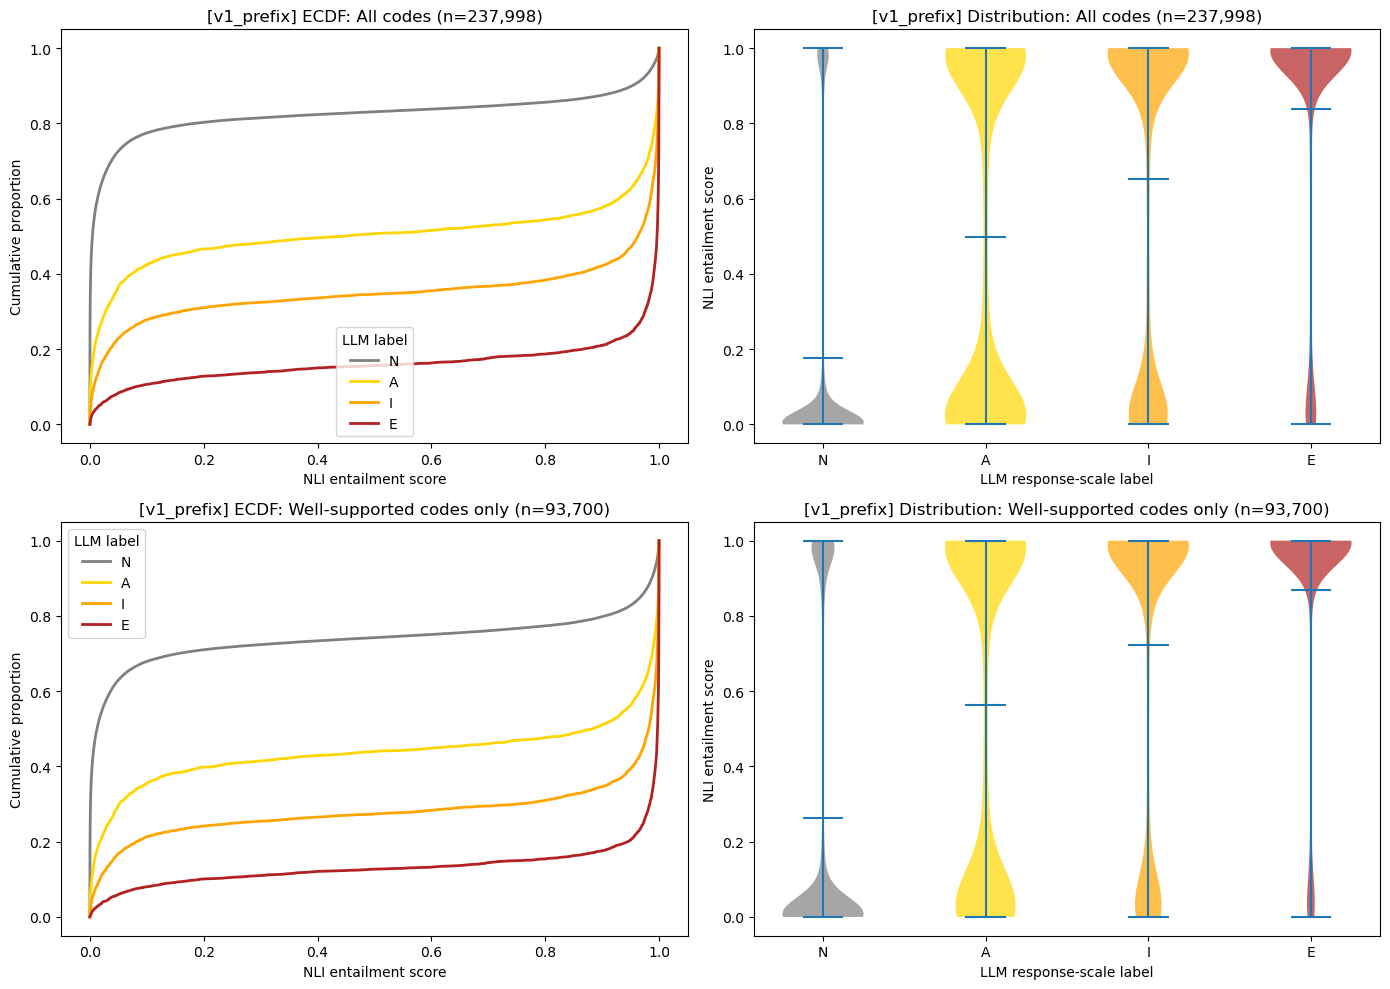

=========== [v2_prefix] All codes (n=237,998) ===========
                            OLS Regression Results                            
Dep. Variable:       entailment_score   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                 3.822e+04
Date:                Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:25:27   Log-Likelihood:                -55657.
No. Observations:              237998   AIC:                         1.113e+05
Df Residuals:                  237996   BIC:                         1.113e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

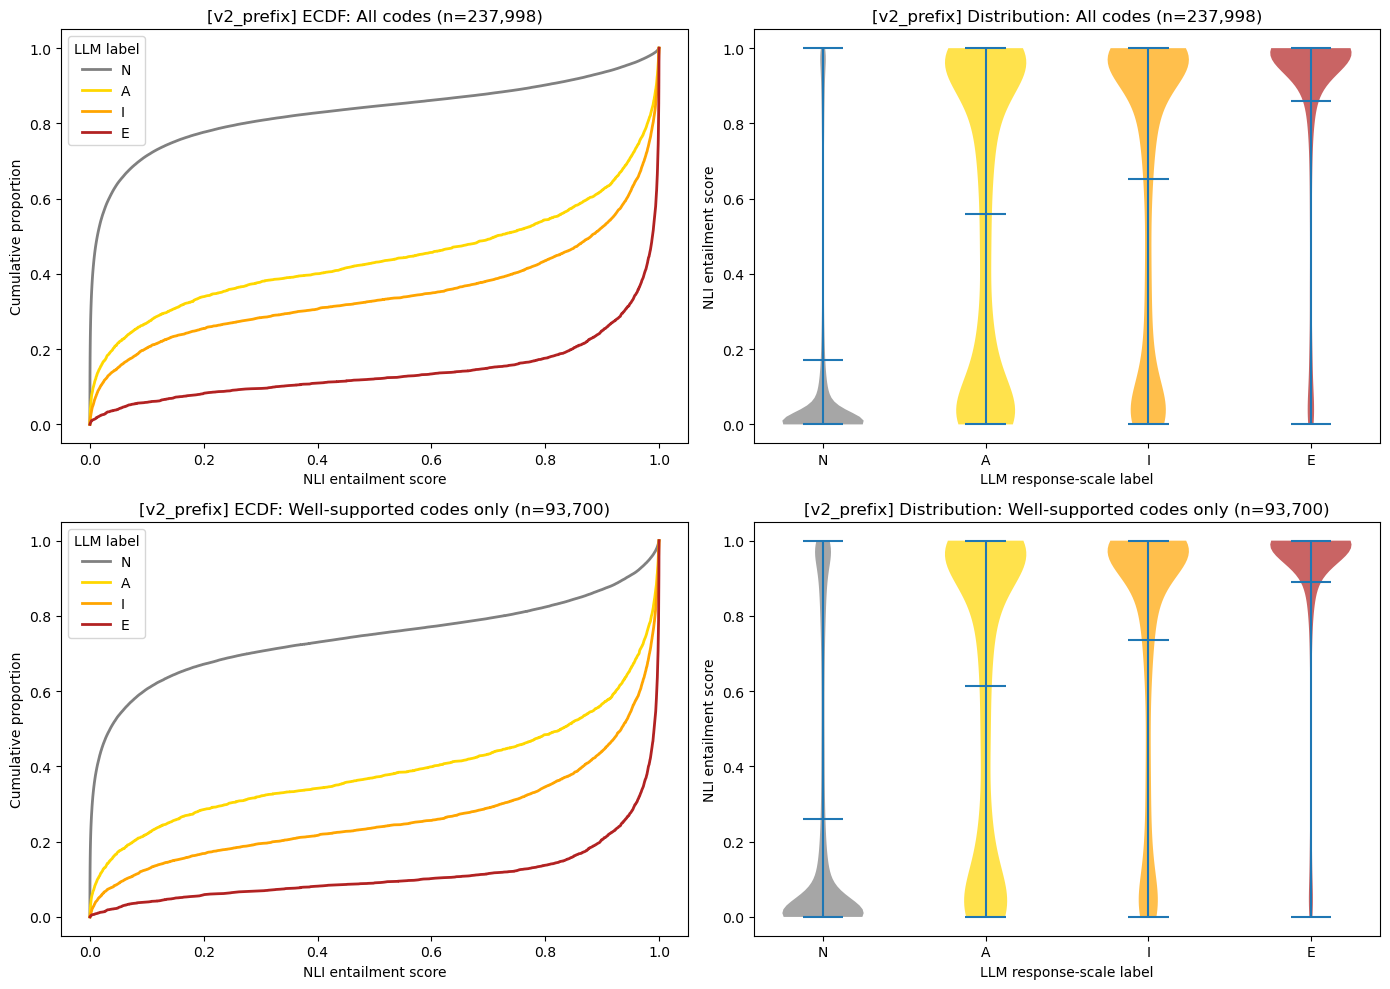

In [ ]:
# Relationship between LLM ordinal label (N<A<I<E) and NLI entailment score
# comparative: full codebook vs. MIN_SUPPORT-filtered codebook, for both v1_prefix and v2_prefix

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import statsmodels.api as sm

LABEL_ORDER = {"N": 0, "A": 1, "I": 2, "E": 3}
labels_map = {0: "N", 1: "A", 2: "I", 3: "E"}
colors = {0: "gray", 1: "gold", 2: "orange", 3: "firebrick"}

def get_label_for_code(code_id, comment_ids, code_df):
    e_col, i_col, a_col = f"{code_id}_E", f"{code_id}_I", f"{code_id}_A"
    labels = pd.Series("N", index=comment_ids)
    labels[code_df.loc[comment_ids, a_col] == 1] = "A"
    labels[code_df.loc[comment_ids, i_col] == 1] = "I"
    labels[code_df.loc[comment_ids, e_col] == 1] = "E"
    return labels

def build_pooled(nli_scores, code_df):
    pooled = nli_scores.copy()
    pooled["ordinal_label_num"] = np.nan
    for code_id in pooled["code_id"].unique():
        e_col, i_col, a_col = f"{code_id}_E", f"{code_id}_I", f"{code_id}_A"
        if not all(c in code_df.columns for c in [e_col, i_col, a_col]):
            continue
        mask = pooled["code_id"] == code_id
        comment_ids = pooled.loc[mask, "comment_id"]
        labels = get_label_for_code(code_id, comment_ids.values, code_df)
        pooled.loc[mask, "ordinal_label_num"] = labels.map(LABEL_ORDER).values
    return pooled.dropna(subset=["ordinal_label_num"])

for prefix in ["v1_prefix", "v2_prefix"]:
    nli_scores = pd.read_csv(f"features/nli_zeroshot_scores_{prefix}.csv")

    pooled_all = build_pooled(nli_scores, code_features)
    pooled_filtered = build_pooled(nli_scores, code_features_filtered)

    datasets = {"All codes": pooled_all, "Well-supported codes only": pooled_filtered}

    for name, pooled in datasets.items():
        X = sm.add_constant(pooled["ordinal_label_num"])
        y = pooled["entailment_score"]
        model = sm.OLS(y, X).fit()
        rho, p = spearmanr(pooled["ordinal_label_num"], pooled["entailment_score"])

        print(f"=========== [{prefix}] {name} (n={len(pooled):,}) ===========")
        print(model.summary())
        print(f"\nSpearman rho = {rho:.3f}, p = {p:.4e}")

        print(f"\nHigh-entailment (>0.5) proportion by label:")
        for label_num, label_name in labels_map.items():
            subset = pooled[pooled["ordinal_label_num"] == label_num]["entailment_score"]
            high_frac = (subset > 0.5).mean()
            print(f"  {label_name}: {high_frac*100:.1f}% high-entailment, n={len(subset):,}")
        print()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for row_idx, (name, pooled) in enumerate(datasets.items()):
        for label_num in [0, 1, 2, 3]:
            scores = np.sort(pooled.loc[pooled["ordinal_label_num"] == label_num, "entailment_score"].values)
            ecdf_y = np.arange(1, len(scores) + 1) / len(scores)
            axes[row_idx, 0].plot(scores, ecdf_y, label=labels_map[label_num], color=colors[label_num], linewidth=2)
        axes[row_idx, 0].set_xlabel("NLI entailment score")
        axes[row_idx, 0].set_ylabel("Cumulative proportion")
        axes[row_idx, 0].set_title(f"[{prefix}] ECDF: {name} (n={len(pooled):,})")
        axes[row_idx, 0].legend(title="LLM label")

        violin_data = [pooled.loc[pooled["ordinal_label_num"] == ln, "entailment_score"].values for ln in [0, 1, 2, 3]]
        parts = axes[row_idx, 1].violinplot(violin_data, positions=[0, 1, 2, 3], showmeans=True, showextrema=True)
        for i, pc in enumerate(parts["bodies"]):
            pc.set_facecolor(colors[i])
            pc.set_alpha(0.7)
        axes[row_idx, 1].set_xticks([0, 1, 2, 3])
        axes[row_idx, 1].set_xticklabels(["N", "A", "I", "E"])
        axes[row_idx, 1].set_xlabel("LLM response-scale label")
        axes[row_idx, 1].set_ylabel("NLI entailment score")
        axes[row_idx, 1].set_title(f"[{prefix}] Distribution: {name} (n={len(pooled):,})")

    plt.tight_layout()
    plt.savefig(f"viz/nli_vs_label_comparative_{prefix}.png", dpi=150)
    plt.show()

In [ ]:
# Largest LLM vs NLI disagreements, across all four NLI variants, alongside Kennedy continuous + ordinal score

import pandas as pd
import numpy as np

LABEL_ORDER = {"N": 0, "A": 1, "I": 2, "E": 3}

judaism_text = pd.read_csv("data/ucberkeley-dlab_target_jewish.csv").set_index("comment_id")
targets = pd.read_csv("features/targets_and_folds.csv").set_index("comment_id")
code_features = pd.read_csv("features/code_features.csv").set_index("comment_id")

def get_llm_label(comment_id, code_id):
    e_col, i_col, a_col = f"{code_id}_E", f"{code_id}_I", f"{code_id}_A"
    if code_features.loc[comment_id, e_col] == 1:
        return "E"
    if code_features.loc[comment_id, i_col] == 1:
        return "I"
    if code_features.loc[comment_id, a_col] == 1:
        return "A"
    return "N"

NLI_FILES = {
    "v1": "features/nli_zeroshot_scores.csv",
    "v2": "features/nli_zeroshot_scores_v2.csv",
    "v1_prefix": "features/nli_zeroshot_scores_v1_prefix.csv",
    "v2_prefix": "features/nli_zeroshot_scores_v2_prefix.csv",
}

nli_dfs = {}
for v, path in NLI_FILES.items():
    df = pd.read_csv(path)
    nli_dfs[v] = df.set_index(["comment_id", "code_id"])["entailment_score"]

base = nli_dfs["v1"].index.to_frame(index=False)
for v in NLI_FILES:
    base[f"nli_{v}"] = base.set_index(["comment_id", "code_id"]).index.map(nli_dfs[v])

base["llm_label"] = base.apply(lambda r: get_llm_label(r["comment_id"], r["code_id"]), axis=1)
base["ordinal_label_num"] = base["llm_label"].map(LABEL_ORDER)

for v in NLI_FILES:
    base[f"disagreement_{v}"] = (base[f"nli_{v}"] - base["ordinal_label_num"] / 3).abs()

base["max_disagreement"] = base[[f"disagreement_{v}" for v in NLI_FILES]].max(axis=1)

base["kennedy_continuous"] = base["comment_id"].map(targets["hate_speech_score"])
base["kennedy_ordinal"] = base["comment_id"].map(targets["ordinal_label"])
base["text"] = base["comment_id"].map(judaism_text["text"])

top = base.sort_values("max_disagreement", ascending=False).head(30)

cols = ["comment_id", "code_id", "llm_label"] + [f"nli_{v}" for v in NLI_FILES] + ["kennedy_continuous", "kennedy_ordinal", "text"]
pd.set_option("display.max_colwidth", 150)
print(top[cols].to_string(index=False))

 comment_id            code_id llm_label   nli_v1   nli_v2  nli_v1_prefix  nli_v2_prefix  kennedy_continuous kennedy_ordinal                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       text
      12712 N1NEGATIVEATTITUDE         N 0.999973 0.997379       0.999973       0.997379                0.63            hate                                                                                                                                                                                                                                                                                    

In [ ]:
# Most predictive features (Ridge coefficients, continuous target) for nli_plus_codes_All, across all four NLI variants

import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

MIN_SUPPORT = 10
support = code_features.filter(regex="_[EIA]$").sum(axis=0)
kept_code_cols = support[support >= MIN_SUPPORT].index.tolist()
code_features_filtered = code_features[kept_code_cols]

y_cont = targets["hate_speech_score"]

NLI_FILES = {
    "v1": "features/nli_zeroshot_scores.csv",
    "v2": "features/nli_zeroshot_scores_v2.csv",
    "v1_prefix": "features/nli_zeroshot_scores_v1_prefix.csv",
    "v2_prefix": "features/nli_zeroshot_scores_v2_prefix.csv",
}

for v, path in NLI_FILES.items():
    nli_scores = pd.read_csv(path)
    nli_wide = nli_scores.pivot(index="comment_id", columns="code_id", values="entailment_score")
    nli_wide.columns = [f"nli_{c}" for c in nli_wide.columns]

    common_ids = nli_wide.index.intersection(y_cont.index).intersection(code_features_filtered.index)
    X = nli_wide.loc[common_ids].join(code_features_filtered.loc[common_ids])
    y = y_cont.loc[common_ids]

    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)

    model = Ridge(alpha=1000, random_state=42)
    model.fit(X_s, y)

    coefs = pd.Series(model.coef_, index=X.columns).sort_values(key=np.abs, ascending=False)

    print(f"\n=== [{v}] Top 20 predictive features (nli_plus_codes_All, continuous target) ===")
    print(coefs.head(20).to_string())


=== [v1] Top 20 predictive features (nli_plus_codes_All, continuous target) ===
nli_D1PERCEPTION              0.162626
nli_E8DOUBLESTANDARD          0.138742
nli_D2STEREOTYPE              0.119439
nli_N13ISRAELCRITICISM       -0.114745
nli_E3COLLECTIVEBLAME         0.113260
nli_N15HARSHCRITICISM        -0.108931
nli_N17DISPROPORTIONATE      -0.106605
nli_N16OPPOSITION            -0.102703
nli_A5HOLOCAUSTDENIAL         0.102038
nli_N1BELIEFS                 0.095178
E1RADICAL_A                   0.090723
nli_N9INCITEMENT              0.081907
nli_N1HOSTILECONDUCT          0.075797
nli_N1DISCRIMINATION         -0.075094
E1VIOLENCE_A                  0.073960
nli_E2COLLECTIVEPOWER        -0.073680
E1VIOLENCE_E                  0.068952
E2DEHUMANIZATION_E            0.067898
nli_N14SUPPRESSIONDIALOGUE    0.066642
A1ESSENTIAL_E                 0.065893

=== [v2] Top 20 predictive features (nli_plus_codes_All, continuous target) ===
nli_D2STEREOTYPE              0.307018
nli_N14SUPPRESSIOND

In [6]:
# Per-comment residual overlap: do v1, v1_prefix, v2, v2_prefix miss on the same comments (shared blind spots)
# or different comments (genuine complementarity)?

import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from itertools import combinations

SOURCES = {
    "v1": ("features/nli_zeroshot_scores.csv", "entailment_score"),
    "v2": ("features/nli_zeroshot_scores_v2.csv", "entailment_score"),
    "v1_prefix": ("features/nli_zeroshot_scores_v1_prefix.csv", "entailment_score"),
    "v2_prefix": ("features/nli_zeroshot_scores_v2_prefix.csv", "entailment_score"),
}

# get out-of-fold predictions for each source
oof_residuals = {}

for source_label, (path, val_col) in SOURCES.items():
    scores = pd.read_csv(path)
    wide = scores.pivot(index="comment_id", columns="code_id", values=val_col)

    common_ids = wide.index.intersection(targets_indexed.index).intersection(code_features_filtered.index)
    X_src = wide.loc[common_ids]
    y_cont, _, _, fold_col = build_targets(common_ids)

    oof_pred = pd.Series(index=common_ids, dtype=float)

    for fold_idx in sorted(fold_col.unique()):
        train_ids = fold_col[fold_col != fold_idx].index
        test_ids = fold_col[fold_col == fold_idx].index

        scaler = StandardScaler().fit(X_src.loc[train_ids])
        X_train_s = scaler.transform(X_src.loc[train_ids])
        X_test_s = scaler.transform(X_src.loc[test_ids])

        model = Ridge(alpha=1000, random_state=42)
        model.fit(X_train_s, y_cont.loc[train_ids])
        oof_pred.loc[test_ids] = model.predict(X_test_s)

    residual = (oof_pred - y_cont.loc[oof_pred.index]).abs()
    oof_residuals[source_label] = residual

residual_df = pd.DataFrame(oof_residuals).dropna()
print(f"n comments with residuals from all 4 sources: {len(residual_df)}")

# define "hard" comments as top-quartile absolute residual, per source
hard_sets = {}
for source_label in SOURCES:
    threshold = residual_df[source_label].quantile(0.75)
    hard_sets[source_label] = set(residual_df[residual_df[source_label] >= threshold].index)
    print(f"{source_label}: {len(hard_sets[source_label])} hard comments (residual >= {threshold:.3f})")

# pairwise overlap: Jaccard similarity of hard-comment sets
print("\n=== Pairwise overlap in hard comments (Jaccard index) ===")
print("High overlap (near 1.0) = shared blind spot. Low overlap (near 0.0) = complementary.\n")
for a, b in combinations(SOURCES.keys(), 2):
    intersection = len(hard_sets[a] & hard_sets[b])
    union = len(hard_sets[a] | hard_sets[b])
    jaccard = intersection / union if union > 0 else np.nan
    print(f"{a:12s} vs {b:12s}: Jaccard={jaccard:.3f}  (overlap={intersection}, union={union})")

# comments hard for ALL FOUR sources
all_hard = set.intersection(*hard_sets.values())
print(f"\nComments hard for ALL 4 sources: {len(all_hard)} ({len(all_hard)/len(residual_df)*100:.1f}% of total)")

# comments hard for exactly ONE source: evidence that source has a unique failure mode
for source_label in SOURCES:
    others = [s for s in SOURCES if s != source_label]
    only_this = hard_sets[source_label] - set.union(*[hard_sets[o] for o in others])
    print(f"Hard ONLY for {source_label}: {len(only_this)}")

# correlation of raw residuals (not just top-quartile) as a continuous check
print("\n=== Residual correlation matrix (continuous check) ===")
print(residual_df.corr().round(3).to_string())

# Which codes are driving the hard-comment sets? (all-4-hard, and each source's unique hard set)

def get_flagged_codes(comment_ids, code_df=code_features_filtered):
    """For a set of comment_ids, return a Series of code_id -> count of comments where that code was E/I/A flagged."""
    sub = code_df.loc[code_df.index.intersection(comment_ids)]
    code_ids = sorted(set(c.rsplit("_", 1)[0] for c in sub.columns))
    counts = {}
    for code_id in code_ids:
        cols = [f"{code_id}_{lvl}" for lvl in ["E", "I", "A"] if f"{code_id}_{lvl}" in sub.columns]
        flagged = (sub[cols].sum(axis=1) > 0)
        counts[code_id] = int(flagged.sum())
    return pd.Series(counts).sort_values(ascending=False)

print("\n" + "=" * 60)
print("CODES FLAGGED WITHIN EACH HARD-COMMENT SET")
print("=" * 60)

print(f"\n--- Hard for ALL 4 sources (n={len(all_hard)}) ---")
flagged = get_flagged_codes(all_hard)
print(flagged[flagged > 0].to_string())

for source_label in SOURCES:
    others = [s for s in SOURCES if s != source_label]
    only_this = hard_sets[source_label] - set.union(*[hard_sets[o] for o in others])
    print(f"\n--- Hard ONLY for {source_label} (n={len(only_this)}) ---")
    flagged = get_flagged_codes(only_this)
    print(flagged[flagged > 0].to_string())

n comments with residuals from all 4 sources: 1874
v1: 469 hard comments (residual >= 1.530)
v2: 469 hard comments (residual >= 1.556)
v1_prefix: 469 hard comments (residual >= 1.602)
v2_prefix: 469 hard comments (residual >= 1.531)

=== Pairwise overlap in hard comments (Jaccard index) ===
High overlap (near 1.0) = shared blind spot. Low overlap (near 0.0) = complementary.

v1           vs v2          : Jaccard=0.479  (overlap=304, union=634)
v1           vs v1_prefix   : Jaccard=0.672  (overlap=377, union=561)
v1           vs v2_prefix   : Jaccard=0.461  (overlap=296, union=642)
v2           vs v1_prefix   : Jaccard=0.496  (overlap=311, union=627)
v2           vs v2_prefix   : Jaccard=0.693  (overlap=384, union=554)
v1_prefix    vs v2_prefix   : Jaccard=0.482  (overlap=305, union=633)

Comments hard for ALL 4 sources: 245 (13.1% of total)
Hard ONLY for v1: 55
Hard ONLY for v2: 43
Hard ONLY for v1_prefix: 42
Hard ONLY for v2_prefix: 45

=== Residual correlation matrix (continuous chec

### Rerankers

In [ ]:
# distribution per code by model
import os
import numpy as np
import pandas as pd

def sigmoid_to_logit(p, eps=1e-9):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

def load_with_logit(path):
    df = pd.read_csv(path)
    if "logit" not in df.columns:
        df["logit"] = sigmoid_to_logit(df["relevance_score"])
        df.to_csv(path, index=False)
    return df

df_bge = load_with_logit("features/reranker_scores_bge.csv")
df_qwen = load_with_logit("features/reranker_scores_qwen.csv")

pd.set_option("display.max_rows", None)

for code_id in sorted(df_bge["code_id"].unique()):
    print(code_id)
    print("Qwen (sigmoid):")
    print(df_qwen[df_qwen["code_id"] == code_id]["relevance_score"].describe())
    print("Qwen (logit):")
    print(df_qwen[df_qwen["code_id"] == code_id]["logit"].describe())
    print("BGE (sigmoid):")
    print(df_bge[df_bge["code_id"] == code_id]["relevance_score"].describe())
    print("BGE (logit):")
    print(df_bge[df_bge["code_id"] == code_id]["logit"].describe())
    print()

A1ESSENTIAL
Qwen (sigmoid):
count    1874.000000
mean        0.001154
std         0.003752
min         0.000005
25%         0.000158
50%         0.000393
75%         0.000969
max         0.112793
Name: relevance_score, dtype: float64
Qwen (logit):
count    1874.000000
mean       -7.797164
std         1.380278
min       -12.311395
25%        -8.750798
50%        -7.841527
75%        -6.938346
max        -2.062524
Name: logit, dtype: float64
BGE (sigmoid):
count    1874.000000
mean        0.000092
std         0.000290
min         0.000076
25%         0.000076
50%         0.000076
75%         0.000077
max         0.009634
Name: relevance_score, dtype: float64
BGE (logit):
count    1874.000000
mean       -9.428739
std         0.257496
min        -9.484375
25%        -9.484375
50%        -9.484375
75%        -9.476562
max        -4.632813
Name: logit, dtype: float64

A2COLLECTIVEAGENDA
Qwen (sigmoid):
count    1874.000000
mean        0.031353
std         0.115246
min         0.000008
25%   

In [ ]:
# NLI, NLI+embeddings, NLI+codes, and NLI+codes+embeddings, per fold
# Run for v1, v2, v1_prefix, v2_prefix, qwen, bge
# Parallelized across the flattened (source, fold, combo) task list

import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, accuracy_score, f1_score, roc_auc_score, cohen_kappa_score
from scipy.stats import pearsonr
from joblib import Parallel, delayed
import mord

SOURCES = {
    "v1": ("features/nli_zeroshot_scores.csv", "entailment_score"),
    "v2": ("features/nli_zeroshot_scores_v2.csv", "entailment_score"),
    "v1_prefix": ("features/nli_zeroshot_scores_v1_prefix.csv", "entailment_score"),
    "v2_prefix": ("features/nli_zeroshot_scores_v2_prefix.csv", "entailment_score"),
    "qwen": ("features/reranker_scores_qwen.csv", "logit"),
    "bge": ("features/reranker_scores_bge.csv", "logit"),
}
SOURCE_NEEDS_SCALING = {label: (val_col == "logit") for label, (_, val_col) in SOURCES.items()}

def fit_and_score_selective(X_train, X_test, cols_to_scale, train_ids, test_ids, y_cont, y_ord, y_bin, feature_set_name, fold_idx):
    rows = []
    if cols_to_scale:
        scaler = StandardScaler().fit(X_train[cols_to_scale])
        X_train_scaled = pd.DataFrame(scaler.transform(X_train[cols_to_scale]), index=X_train.index, columns=cols_to_scale)
        X_test_scaled = pd.DataFrame(scaler.transform(X_test[cols_to_scale]), index=X_test.index, columns=cols_to_scale)
        unscaled_cols = [c for c in X_train.columns if c not in cols_to_scale]
        X_train_s = pd.concat([X_train_scaled, X_train[unscaled_cols]], axis=1).values
        X_test_s = pd.concat([X_test_scaled, X_test[unscaled_cols]], axis=1).values
    else:
        X_train_s, X_test_s = X_train.values, X_test.values

    model = Ridge(alpha=1000, random_state=42)
    model.fit(X_train_s, y_cont.loc[train_ids])
    preds = model.predict(X_test_s)
    r, _ = pearsonr(y_cont.loc[test_ids], preds)
    rows.append({"feature_set": feature_set_name, "target": "continuous", "model": "ridge",
                 "fold": fold_idx, "r2": r2_score(y_cont.loc[test_ids], preds), "pearson_r": r})

    base_logreg = lambda: LogisticRegression(C=LOGREG_C, solver="lbfgs", class_weight="balanced", max_iter=2000, random_state=42)
    ordinal_models = {
        "ordinal_logit": mord.LogisticIT(alpha=1.0 / LOGREG_C),
        "multinomial_logit": base_logreg(),
        "ovr_logit": OneVsRestClassifier(base_logreg()),
        "ovo_logit": OneVsOneClassifier(base_logreg()),
    }
    for model_name, m in ordinal_models.items():
        m.fit(X_train_s, y_ord.loc[train_ids].values)
        preds = m.predict(X_test_s)
        rows.append({
            "feature_set": feature_set_name, "target": "ordinal", "model": model_name, "fold": fold_idx,
            "acc": accuracy_score(y_ord.loc[test_ids], preds),
            "f1_macro": f1_score(y_ord.loc[test_ids], preds, average="macro"),
            "qwk": cohen_kappa_score(y_ord.loc[test_ids], preds, weights="quadratic"),
        })

    m = LogisticRegression(C=LOGREG_C, solver="liblinear", class_weight="balanced", max_iter=2000, random_state=42)
    m.fit(X_train_s, y_bin.loc[train_ids])
    preds = m.predict(X_test_s)
    probs = m.predict_proba(X_test_s)[:, 1]
    rows.append({
        "feature_set": feature_set_name, "target": "binary", "model": "logreg", "fold": fold_idx,
        "acc": accuracy_score(y_bin.loc[test_ids], preds),
        "f1": f1_score(y_bin.loc[test_ids], preds),
        "auc": roc_auc_score(y_bin.loc[test_ids], probs),
    })
    return rows

SOURCE_STATE = {}
for source_label, (path, val_col) in SOURCES.items():
    scores = pd.read_csv(path)
    wide = scores.pivot(index="comment_id", columns="code_id", values=val_col)
    common_ids = wide.index.intersection(targets_indexed.index).intersection(code_features_filtered.index)
    X_src = wide.loc[common_ids]
    y_cont, y_ord, y_bin, fold_col = build_targets(common_ids)
    SOURCE_STATE[source_label] = {
        "X_src": X_src, "y_cont": y_cont, "y_ord": y_ord, "y_bin": y_bin, "fold_col": fold_col,
    }

DEFINITIONS = ["All", "IHRA", "Nexus", "JDA"]
REPRESENTATION_NAMES = list(REPRESENTATIONS.keys())

tasks = []
for source_label, state in SOURCE_STATE.items():
    folds = sorted(state["fold_col"].unique())
    for fold_idx in folds:
        tasks.append((source_label, fold_idx, "only", None, None))
        for rep in REPRESENTATION_NAMES:
            tasks.append((source_label, fold_idx, "plus_rep", None, rep))
        for definition in DEFINITIONS:
            tasks.append((source_label, fold_idx, "plus_codes", definition, None))
            for rep in REPRESENTATION_NAMES:
                tasks.append((source_label, fold_idx, "plus_codes_plus_rep", definition, rep))

print(f"Total tasks: {len(tasks)}")

def run_task(source_label, fold_idx, combo_type, definition, rep):
    state = SOURCE_STATE[source_label]
    X_src, y_cont, y_ord, y_bin, fold_col = state["X_src"], state["y_cont"], state["y_ord"], state["y_bin"], state["fold_col"]
    train_ids = fold_col[fold_col != fold_idx].index
    test_ids = fold_col[fold_col == fold_idx].index
    src_cols = list(X_src.columns)
    src_needs_scaling = SOURCE_NEEDS_SCALING[source_label]

    if combo_type == "only":
        combo_name = f"{source_label}_only"
        X_train, X_test = X_src.loc[train_ids], X_src.loc[test_ids]
        cols_to_scale = src_cols if src_needs_scaling else []

    elif combo_type == "plus_rep":
        combo_name = f"{source_label}_plus_{rep}"
        e_train, e_test = REPRESENTATIONS[rep](fold_idx, train_ids, test_ids)
        X_train = X_src.loc[train_ids].join(e_train)
        X_test = X_src.loc[test_ids].join(e_test)
        cols_to_scale = (src_cols if src_needs_scaling else []) + list(e_train.columns)

    elif combo_type == "plus_codes":
        combo_name = f"{source_label}_plus_codes_{definition}"
        cols = code_cols_for_definition(definition)
        X_codes = code_features_filtered[cols]
        X_train = X_src.loc[train_ids].join(X_codes.loc[train_ids])
        X_test = X_src.loc[test_ids].join(X_codes.loc[test_ids])
        cols_to_scale = src_cols if src_needs_scaling else []

    else:  # plus_codes_plus_rep
        combo_name = f"{source_label}_plus_codes_{definition}_plus_{rep}"
        cols = code_cols_for_definition(definition)
        X_codes = code_features_filtered[cols]
        e_train, e_test = REPRESENTATIONS[rep](fold_idx, train_ids, test_ids)
        X_train = X_src.loc[train_ids].join(X_codes.loc[train_ids]).join(e_train)
        X_test = X_src.loc[test_ids].join(X_codes.loc[test_ids]).join(e_test)
        cols_to_scale = (src_cols if src_needs_scaling else []) + list(e_train.columns)

    return fit_and_score_selective(X_train, X_test, cols_to_scale, train_ids, test_ids,
                                    y_cont, y_ord, y_bin, combo_name, fold_idx)

results_nested = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_task)(*task) for task in tasks
)
all_rows = [row for rows in results_nested for row in rows]
all_results = pd.DataFrame(all_rows)

for source_label in SOURCES:
    subset = all_results[all_results["feature_set"].str.startswith(source_label)]

    print(f"\n{'#'*80}\n# {source_label}\n{'#'*80}")

    print("=== Continuous ===")
    print(subset[subset["target"] == "continuous"].groupby("feature_set")[["r2", "pearson_r"]].agg(["mean", "std"]).round(3).to_string())

    print("\n=== Ordinal ===")
    print(subset[subset["target"] == "ordinal"].groupby(["feature_set", "model"])[["acc", "f1_macro", "qwk"]].agg(["mean", "std"]).round(3).to_string())

    print("\n=== Binary ===")
    print(subset[subset["target"] == "binary"].groupby("feature_set")[["acc", "f1", "auc"]].agg(["mean", "std"]).round(3).to_string())

    print("\n=== Continuous, per fold ===")
    print(subset[subset["target"] == "continuous"].pivot_table(index="feature_set", columns="fold", values="r2").round(3).to_string())

    print("\n=== Ordinal, per fold (QWK) ===")
    print(subset[subset["target"] == "ordinal"].pivot_table(index=["feature_set", "model"], columns="fold", values="qwk").round(3).to_string())

    print("\n=== Binary, per fold (AUC) ===")
    print(subset[subset["target"] == "binary"].pivot_table(index="feature_set", columns="fold", values="auc").round(3).to_string())

Total tasks: 450

################################################################################
# v1
################################################################################
=== Continuous ===
                                        r2        pearson_r       
                                      mean    std      mean    std
feature_set                                                       
v1_only                              0.457  0.018     0.689  0.013
v1_plus_codes_All                    0.500  0.027     0.723  0.020
v1_plus_codes_All_plus_pca           0.563  0.013     0.759  0.010
v1_plus_codes_All_plus_raw           0.573  0.024     0.759  0.017
v1_plus_codes_IHRA                   0.486  0.022     0.713  0.017
v1_plus_codes_IHRA_plus_pca          0.551  0.011     0.751  0.009
v1_plus_codes_IHRA_plus_raw          0.562  0.023     0.752  0.017
v1_plus_codes_JDA                    0.467  0.020     0.698  0.015
v1_plus_codes_JDA_plus_pca           0.538  0.011     0.741

In [82]:
# Summary table: best and worst feature_set per target, plus best/worst ordinal model overall

import pandas as pd

print("=" * 70)
print("CONTINUOUS (Ridge, R2)")
print("=" * 70)
cont = all_results[all_results["target"] == "continuous"].groupby("feature_set")["r2"].mean().sort_values(ascending=False)
print(f"\nBest 5:\n{cont.head(5).to_string()}")
print(f"\nWorst 5:\n{cont.tail(5).to_string()}")

print("\n" + "=" * 70)
print("ORDINAL (QWK, by feature_set + model)")
print("=" * 70)
ordi = all_results[all_results["target"] == "ordinal"].groupby(["feature_set", "model"])["qwk"].mean().sort_values(ascending=False)
print(f"\nBest 5:\n{ordi.head(5).to_string()}")
print(f"\nWorst 5:\n{ordi.tail(5).to_string()}")

print("\n--- Best ordinal MODEL overall (averaged across all feature sets) ---")
model_avg = all_results[all_results["target"] == "ordinal"].groupby("model")["qwk"].mean().sort_values(ascending=False)
print(model_avg.to_string())

print("\n" + "=" * 70)
print("BINARY (Logistic Regression, AUC)")
print("=" * 70)
binr = all_results[all_results["target"] == "binary"].groupby("feature_set")["auc"].mean().sort_values(ascending=False)
print(f"\nBest 5:\n{binr.head(5).to_string()}")
print(f"\nWorst 5:\n{binr.tail(5).to_string()}")

print("\n" + "=" * 70)
print("BEST SOURCE OVERALL (averaged across all its feature-set variants)")
print("=" * 70)
all_results["source"] = all_results["feature_set"].str.split("_only|_plus").str[0]
source_avg = all_results[all_results["target"] == "continuous"].groupby("source")["r2"].mean().sort_values(ascending=False)
print(source_avg.to_string())

CONTINUOUS (Ridge, R2)

Best 5:
feature_set
v1_plus_codes_All_plus_raw           0.573136
v2_plus_codes_All_plus_raw           0.566801
v1_plus_codes_All_plus_pca           0.563159
v1_plus_codes_IHRA_plus_raw          0.561866
v1_prefix_plus_codes_All_plus_raw    0.561115

Worst 5:
feature_set
bge_plus_codes_IHRA     0.321265
qwen_only               0.310970
bge_plus_codes_Nexus    0.303448
bge_plus_codes_JDA      0.272183
bge_only                0.245787

ORDINAL (QWK, by feature_set + model)

Best 5:
feature_set                        model        
v1_plus_codes_All_plus_raw         ordinal_logit    0.652239
v1_plus_codes_IHRA_plus_raw        ordinal_logit    0.646693
v1_prefix_plus_codes_All_plus_raw  ordinal_logit    0.643143
v1_plus_codes_Nexus_plus_raw       ordinal_logit    0.640572
v2_plus_codes_All_plus_pca         ordinal_logit    0.640133

Worst 5:
feature_set         model            
bge_plus_codes_JDA  ordinal_logit        0.402901
bge_only            multinomial_logit  

In [ ]:
# Pairwise synergy scan: all singles + all pairs (excluding v1+v1_prefix, v2+v2_prefix), definition="All" only
# Parallelized across the flattened (fold, combo) task list

import pandas as pd
import numpy as np
from itertools import combinations
from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, accuracy_score, f1_score, roc_auc_score, cohen_kappa_score
from scipy.stats import pearsonr
import mord
from nli_config import CODE_HYPOTHESES

definition_prefix_map = {"I": "IHRA", "N": "Nexus", "J": "JDA"}
flat = pd.read_csv("batches/results/all_blocks_flat.csv")
error_types = ["API_ERROR", "PARSE_ERROR", "EMPTY_RESPONSE"]
flat = flat[~flat["code_id"].isin(error_types)].copy()
code_block_map = flat[["code_id", "block"]].drop_duplicates().set_index("code_id")["block"]

def get_definition_codes(definition):
    if definition == "All":
        return set(CODE_HYPOTHESES.keys())
    prefix = {v: k for k, v in definition_prefix_map.items()}[definition]
    return set(code_block_map[code_block_map.str.startswith(prefix)].index) & set(CODE_HYPOTHESES.keys())

SOURCES_NEEDING_SCALING = {"qwen", "bge", "raw", "pca"}

SCOPED_RAW = {}
for label, path, val_col in [
    ("nli_v1", "features/nli_zeroshot_scores.csv", "entailment_score"),
    ("nli_v2", "features/nli_zeroshot_scores_v2.csv", "entailment_score"),
    ("nli_v1_prefix", "features/nli_zeroshot_scores_v1_prefix.csv", "entailment_score"),
    ("nli_v2_prefix", "features/nli_zeroshot_scores_v2_prefix.csv", "entailment_score"),
    ("qwen", "features/reranker_scores_qwen.csv", "logit"),
    ("bge", "features/reranker_scores_bge.csv", "logit"),
]:
    SCOPED_RAW[label] = pd.read_csv(path).pivot(index="comment_id", columns="code_id", values=val_col)

def get_scoped_features(source_name, definition):
    def_codes = get_definition_codes(definition)
    df = SCOPED_RAW[source_name]
    cols = [c for c in df.columns if c in def_codes]
    out = df[cols].copy()
    out.columns = [f"{source_name}_{c}" for c in out.columns]
    return out

SOURCES_LIST = ["codes", "nli_v1", "nli_v2", "nli_v1_prefix", "nli_v2_prefix", "qwen", "bge", "raw", "pca"]
EXCLUDE_PAIRS = [("nli_v1", "nli_v1_prefix"), ("nli_v2", "nli_v2_prefix")]

def get_features(source_name, train_ids, test_ids, fold_idx, definition="All"):
    if source_name in ("raw", "pca"):
        return REPRESENTATIONS[source_name](fold_idx, train_ids, test_ids)
    if source_name == "codes":
        cols = code_cols_for_definition(definition)
        return code_features_filtered[cols].loc[train_ids], code_features_filtered[cols].loc[test_ids]
    feat = get_scoped_features(source_name, definition)
    return feat.loc[train_ids], feat.loc[test_ids]

def fit_and_score_selective(X_train, X_test, cols_to_scale, train_ids, test_ids, y_cont, y_ord, y_bin, feature_set_name, fold_idx):
    rows = []
    if cols_to_scale:
        scaler = StandardScaler().fit(X_train[cols_to_scale])
        X_train_scaled = pd.DataFrame(scaler.transform(X_train[cols_to_scale]), index=X_train.index, columns=cols_to_scale)
        X_test_scaled = pd.DataFrame(scaler.transform(X_test[cols_to_scale]), index=X_test.index, columns=cols_to_scale)
        unscaled_cols = [c for c in X_train.columns if c not in cols_to_scale]
        X_train_s = pd.concat([X_train_scaled, X_train[unscaled_cols]], axis=1).values
        X_test_s = pd.concat([X_test_scaled, X_test[unscaled_cols]], axis=1).values
    else:
        X_train_s, X_test_s = X_train.values, X_test.values

    model = Ridge(alpha=1000, random_state=42)
    model.fit(X_train_s, y_cont.loc[train_ids])
    preds = model.predict(X_test_s)
    r, _ = pearsonr(y_cont.loc[test_ids], preds)
    rows.append({"feature_set": feature_set_name, "target": "continuous", "model": "ridge",
                 "fold": fold_idx, "r2": r2_score(y_cont.loc[test_ids], preds), "pearson_r": r})

    base_logreg = lambda: LogisticRegression(C=LOGREG_C, solver="lbfgs", class_weight="balanced", max_iter=2000, random_state=42)
    ordinal_models = {
        "ordinal_logit": mord.LogisticIT(alpha=1.0 / LOGREG_C),
        "multinomial_logit": base_logreg(),
        "ovr_logit": OneVsRestClassifier(base_logreg()),
        "ovo_logit": OneVsOneClassifier(base_logreg()),
    }
    for model_name, m in ordinal_models.items():
        m.fit(X_train_s, y_ord.loc[train_ids].values)
        preds = m.predict(X_test_s)
        rows.append({
            "feature_set": feature_set_name, "target": "ordinal", "model": model_name, "fold": fold_idx,
            "acc": accuracy_score(y_ord.loc[test_ids], preds),
            "f1_macro": f1_score(y_ord.loc[test_ids], preds, average="macro"),
            "qwk": cohen_kappa_score(y_ord.loc[test_ids], preds, weights="quadratic"),
        })

    m = LogisticRegression(C=LOGREG_C, solver="liblinear", class_weight="balanced", max_iter=2000, random_state=42)
    m.fit(X_train_s, y_bin.loc[train_ids])
    preds = m.predict(X_test_s)
    probs = m.predict_proba(X_test_s)[:, 1]
    rows.append({
        "feature_set": feature_set_name, "target": "binary", "model": "logreg", "fold": fold_idx,
        "acc": accuracy_score(y_bin.loc[test_ids], preds),
        "f1": f1_score(y_bin.loc[test_ids], preds),
        "auc": roc_auc_score(y_bin.loc[test_ids], probs),
    })
    return rows

singles = [(s,) for s in SOURCES_LIST]
pairs = [p for p in combinations(SOURCES_LIST, 2) if set(p) not in [set(e) for e in EXCLUDE_PAIRS]]
combos_to_test = singles + pairs
print(f"Testing {len(combos_to_test)} combinations ({len(singles)} singles, {len(pairs)} pairs)")

common_ids = targets_indexed.index.intersection(code_features_filtered.index)
for label in ["nli_v1", "nli_v2", "nli_v1_prefix", "nli_v2_prefix", "qwen", "bge"]:
    common_ids = common_ids.intersection(SCOPED_RAW[label].index)

y_cont, y_ord, y_bin, fold_col = build_targets(common_ids)
folds = sorted(fold_col.unique())

def run_one(fold_idx, combo):
    train_ids = fold_col[fold_col != fold_idx].index
    test_ids = fold_col[fold_col == fold_idx].index
    combo_name = "+".join(combo)

    X_train_parts, X_test_parts, cols_to_scale = [], [], []
    for source_name in combo:
        f_train, f_test = get_features(source_name, train_ids, test_ids, fold_idx)
        X_train_parts.append(f_train)
        X_test_parts.append(f_test)
        if source_name in SOURCES_NEEDING_SCALING:
            cols_to_scale.extend(f_train.columns.tolist())

    X_train = pd.concat(X_train_parts, axis=1)
    X_test = pd.concat(X_test_parts, axis=1)

    return fit_and_score_selective(X_train, X_test, cols_to_scale, train_ids, test_ids,
                                    y_cont, y_ord, y_bin, combo_name, fold_idx)

tasks = [(fold_idx, combo) for fold_idx in folds for combo in combos_to_test]
results_nested = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_one)(fold_idx, combo) for fold_idx, combo in tasks
)
all_rows = [row for rows in results_nested for row in rows]
pairwise_results = pd.DataFrame(all_rows)

cont_means = pairwise_results[pairwise_results["target"] == "continuous"].groupby("feature_set")["r2"].mean()

synergy_rows = []
for a, b in pairs:
    r2_a = cont_means.get(a, np.nan)
    r2_b = cont_means.get(b, np.nan)
    r2_pair = cont_means.get(f"{a}+{b}", np.nan)
    synergy_rows.append({"pair": f"{a}+{b}", "r2_a": r2_a, "r2_b": r2_b,
                          "r2_pair": r2_pair, "r2_max_single": max(r2_a, r2_b),
                          "gain_over_best_single": r2_pair - max(r2_a, r2_b)})

synergy_df = pd.DataFrame(synergy_rows).sort_values("r2_pair", ascending=False)

print("\n=== Pairs ranked by absolute performance (r2_pair) ===")
print(synergy_df.to_string(index=False))

print("\n=== Singles ranked by absolute performance ===")
singles_r2 = pairwise_results[
    (pairwise_results["target"] == "continuous") & (~pairwise_results["feature_set"].str.contains(r"\+"))
].groupby("feature_set")["r2"].mean().sort_values(ascending=False)
print(singles_r2.to_string())

Testing 43 combinations (9 singles, 34 pairs)

=== Pairs ranked by absolute performance (r2_pair) ===
                       pair     r2_a     r2_b  r2_pair  r2_max_single  gain_over_best_single
                 nli_v1+raw 0.456812 0.466511 0.542864       0.466511               0.076353
                 nli_v2+raw 0.398641 0.466511 0.537242       0.466511               0.070731
          nli_v2_prefix+raw 0.363044 0.466511 0.530475       0.466511               0.063964
          nli_v1_prefix+raw 0.404615 0.466511 0.530470       0.466511               0.063959
                 nli_v1+pca 0.456812 0.391603 0.529910       0.456812               0.073099
                  codes+raw 0.216383 0.466511 0.521517       0.466511               0.055006
                nli_v1+qwen 0.456812 0.310970 0.517562       0.456812               0.060750
                 nli_v2+pca 0.398641 0.391603 0.516422       0.398641               0.117780
          nli_v1_prefix+pca 0.404615 0.391603 0.508732       

=========== [bge] All codes (n=237,998) ===========
R-squared: 0.036
Spearman rho = 0.175, p = 0.0000e+00
High-relevance (logit > 0, i.e. sigmoid > 0.5) proportion by label:
  N: 0.1% high-relevance, n=224,070
  A: 0.8% high-relevance, n=3,726
  I: 0.4% high-relevance, n=6,291
  E: 1.4% high-relevance, n=3,911

=========== [bge] Well-supported codes only (n=93,700) ===========
R-squared: 0.045
Spearman rho = 0.201, p = 0.0000e+00
High-relevance (logit > 0, i.e. sigmoid > 0.5) proportion by label:
  N: 0.1% high-relevance, n=82,240
  A: 0.4% high-relevance, n=2,997
  I: 0.4% high-relevance, n=4,907
  E: 1.3% high-relevance, n=3,556



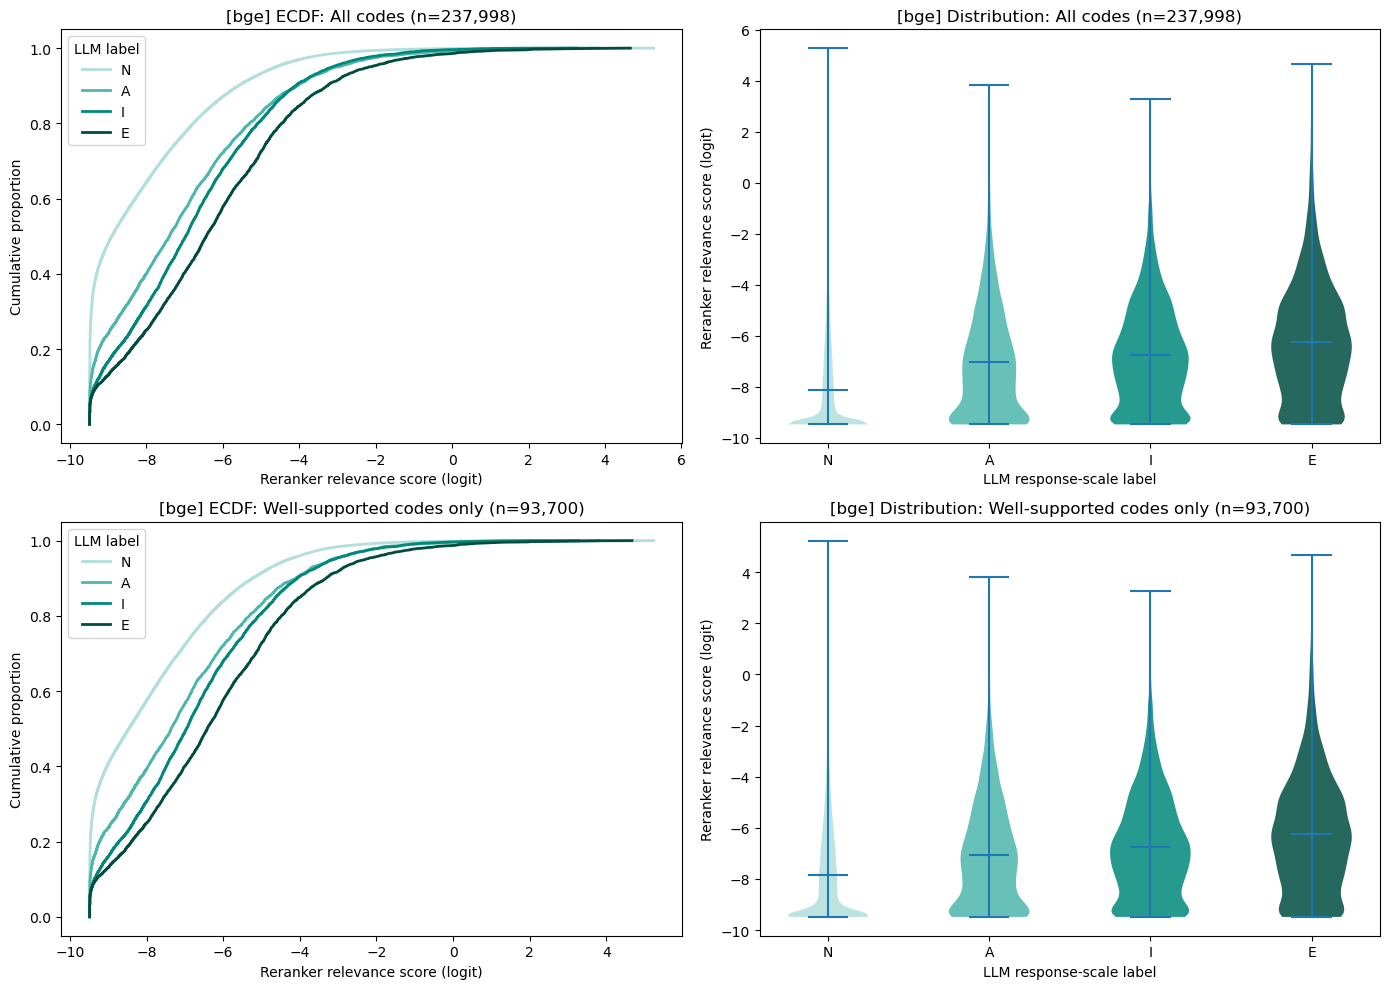

=========== [qwen] All codes (n=237,998) ===========
R-squared: 0.060
Spearman rho = 0.207, p = 0.0000e+00
High-relevance (logit > 0, i.e. sigmoid > 0.5) proportion by label:
  N: 0.8% high-relevance, n=224,070
  A: 2.8% high-relevance, n=3,726
  I: 6.6% high-relevance, n=6,291
  E: 9.9% high-relevance, n=3,911

=========== [qwen] Well-supported codes only (n=93,700) ===========
R-squared: 0.076
Spearman rho = 0.243, p = 0.0000e+00
High-relevance (logit > 0, i.e. sigmoid > 0.5) proportion by label:
  N: 1.0% high-relevance, n=82,240
  A: 2.5% high-relevance, n=2,997
  I: 5.3% high-relevance, n=4,907
  E: 8.5% high-relevance, n=3,556



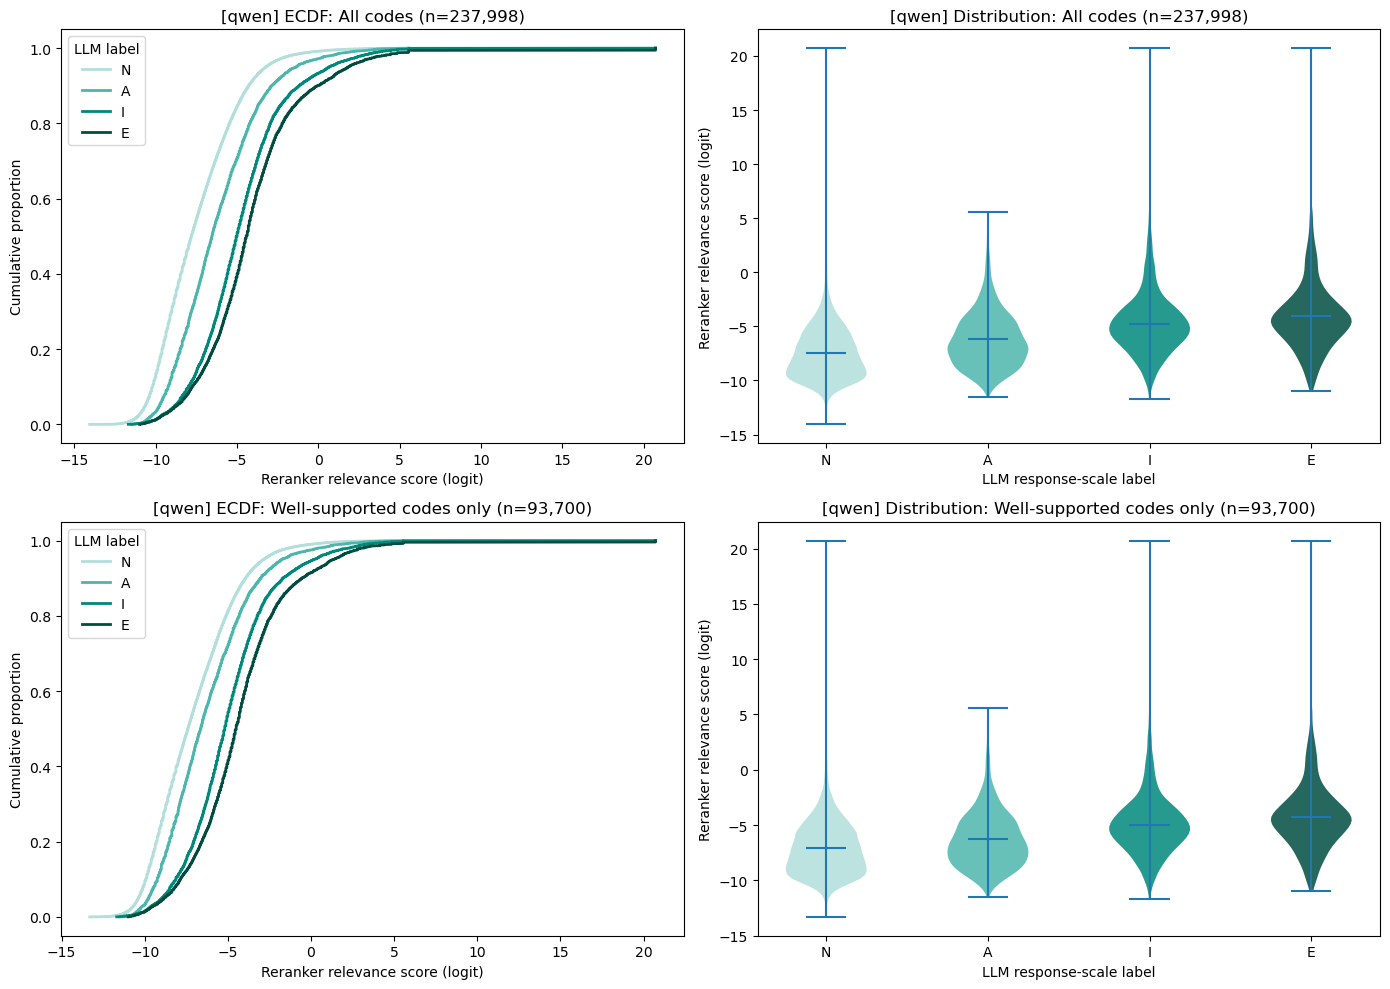

In [ ]:
# Relationship between LLM ordinal label (N<A<I<E) and reranker relevance score
# comparative: full codebook vs. MIN_SUPPORT-filtered codebook, for both bge and qwen

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import statsmodels.api as sm

LABEL_ORDER = {"N": 0, "A": 1, "I": 2, "E": 3}
labels_map = {0: "N", 1: "A", 2: "I", 3: "E"}
colors = {0: "#B2DFDB", 1: "#4DB6AC", 2: "#00897B", 3: "#004D40"}  # minty green, light to dark

def get_label_for_code(code_id, comment_ids, code_df):
    e_col, i_col, a_col = f"{code_id}_E", f"{code_id}_I", f"{code_id}_A"
    labels = pd.Series("N", index=comment_ids)
    labels[code_df.loc[comment_ids, a_col] == 1] = "A"
    labels[code_df.loc[comment_ids, i_col] == 1] = "I"
    labels[code_df.loc[comment_ids, e_col] == 1] = "E"
    return labels

def build_pooled(scores_df, code_df, score_col):
    pooled = scores_df.copy()
    pooled["ordinal_label_num"] = np.nan
    for code_id in pooled["code_id"].unique():
        e_col, i_col, a_col = f"{code_id}_E", f"{code_id}_I", f"{code_id}_A"
        if not all(c in code_df.columns for c in [e_col, i_col, a_col]):
            continue
        mask = pooled["code_id"] == code_id
        cids = pooled.loc[mask, "comment_id"]
        labels = get_label_for_code(code_id, cids.values, code_df)
        pooled.loc[mask, "ordinal_label_num"] = labels.map(LABEL_ORDER).values
    pooled = pooled.dropna(subset=["ordinal_label_num"])
    return pooled.rename(columns={score_col: "score"})

reranker_files = {"bge": "features/reranker_scores_bge.csv", "qwen": "features/reranker_scores_qwen.csv"}

for model_label, path in reranker_files.items():
    scores_df = pd.read_csv(path)

    pooled_all = build_pooled(scores_df, code_features, "logit")
    pooled_filtered = build_pooled(scores_df, code_features_filtered, "logit")

    datasets = {"All codes": pooled_all, "Well-supported codes only": pooled_filtered}

    for name, pooled in datasets.items():
        X = sm.add_constant(pooled["ordinal_label_num"])
        y = pooled["score"]
        model = sm.OLS(y, X).fit()
        rho, p = spearmanr(pooled["ordinal_label_num"], pooled["score"])

        print(f"=========== [{model_label}] {name} (n={len(pooled):,}) ===========")
        print(f"R-squared: {model.rsquared:.3f}")
        print(f"Spearman rho = {rho:.3f}, p = {p:.4e}")
        print("High-relevance (logit > 0, i.e. sigmoid > 0.5) proportion by label:")
        for label_num, label_name in labels_map.items():
            subset = pooled[pooled["ordinal_label_num"] == label_num]["score"]
            high_frac = (subset > 0).mean()
            print(f"  {label_name}: {high_frac*100:.1f}% high-relevance, n={len(subset):,}")
        print()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for row_idx, (name, pooled) in enumerate(datasets.items()):
        for label_num in [0, 1, 2, 3]:
            scores = np.sort(pooled.loc[pooled["ordinal_label_num"] == label_num, "score"].values)
            ecdf_y = np.arange(1, len(scores) + 1) / len(scores)
            axes[row_idx, 0].plot(scores, ecdf_y, label=labels_map[label_num], color=colors[label_num], linewidth=2)
        axes[row_idx, 0].set_xlabel("Reranker relevance score (logit)")
        axes[row_idx, 0].set_ylabel("Cumulative proportion")
        axes[row_idx, 0].set_title(f"[{model_label}] ECDF: {name} (n={len(pooled):,})")
        axes[row_idx, 0].legend(title="LLM label")

        violin_data = [pooled.loc[pooled["ordinal_label_num"] == ln, "score"].values for ln in [0, 1, 2, 3]]
        parts = axes[row_idx, 1].violinplot(violin_data, positions=[0, 1, 2, 3], showmeans=True, showextrema=True)
        for i, pc in enumerate(parts["bodies"]):
            pc.set_facecolor(colors[i])
            pc.set_alpha(0.85)
        axes[row_idx, 1].set_xticks([0, 1, 2, 3])
        axes[row_idx, 1].set_xticklabels(["N", "A", "I", "E"])
        axes[row_idx, 1].set_xlabel("LLM response-scale label")
        axes[row_idx, 1].set_ylabel("Reranker relevance score (logit)")
        axes[row_idx, 1].set_title(f"[{model_label}] Distribution: {name} (n={len(pooled):,})")

    plt.tight_layout()
    plt.savefig(f"viz/reranker_vs_label_comparative_{model_label}.png", dpi=150)
    plt.show()